In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns
from collections import Counter
import time

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# 注：本项目由于修改频繁，如需重新加载，请按如下顺序运行：1.预处理部分 → 3.1-3.4 NLP部分 → 2.数据可视化部分 → 4.建模部分

# 1 预处理部分
## 1.1 导入并查看数据

In [2]:
df=pd.read_csv("data_03.csv",encoding="gbk")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   data_index  3010 non-null   int64
 1   用户名         3010 non-null   str  
 2   评论日期        3010 non-null   str  
 3   电脑配置        3010 non-null   str  
 4   评论内容        3010 non-null   str  
 5   有用数         3010 non-null   int64
 6   重复购买情况      3010 non-null   str  
 7   评分          3010 non-null   int64
 8   内存          3010 non-null   str  
 9   硬盘          3010 non-null   str  
 10  屏幕大小        3010 non-null   str  
dtypes: int64(3), str(8)
memory usage: 258.8 KB


In [3]:
df.columns

Index(['data_index', '用户名', '评论日期', '电脑配置', '评论内容', '有用数', '重复购买情况', '评分',
       '内存', '硬盘', '屏幕大小'],
      dtype='str')

In [4]:
df.head()

,data_index,用户名,评论日期,电脑配置,评论内容,有用数,重复购买情况,评分,内存,硬盘,屏幕大小
0,1,j***x,2025-11-19,16英寸酷睿版 标压酷睿2代Ultra 5|32G 1T,京东下单，第二天就送到了，拆开包装完好无损，全新原封，非常好。速度很快！手感和做工非常好，全...,31,否,5,32G,1T,16
1,2,h***2,2026-01-21,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,?这款笔记本真的超乎预期！?? 屏幕显示细腻，色彩饱满，看视频特别舒服 ??。键盘手感舒适，...,2,该店铺购买≥2次,5,24G,1T,16
2,3,一***心,2026-01-24,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,运行速度：运行速度足够快，完全够用屏幕效果：清晰度非常好非常好散热性能：散热没问题，声音小外...,0,否,5,24G,1T,16
3,4,B***7,2026-01-24,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,这款笔记本电脑性能不错，运行流畅，日常办公和娱乐毫无压力。屏幕清晰，手感也很好，性价比超高，...,1,该店铺购买≥2次,5,24G,1T,16
4,5,jd_6ntty41ckt5vjf,2026-01-22,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,自己上学时候用的就是联想小新，现在弟弟上学也是直接选择联想小新，现在的笔记本，很轻薄，看着外...,0,否,5,24G,1T,16


## 1.2 检查重复值和缺失值

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

data_index    0
用户名           0
评论日期          0
电脑配置          0
评论内容          0
有用数           0
重复购买情况        0
评分            0
内存            0
硬盘            0
屏幕大小          0
dtype: int64

## 1.3 检查异常值

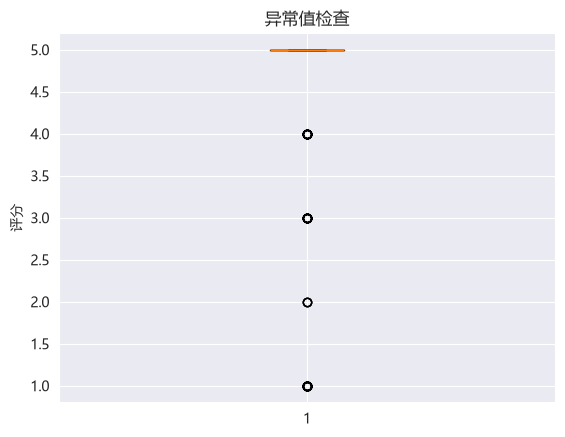

In [7]:
plt.boxplot(df["评分"])
plt.title("异常值检查")
plt.ylabel("评分")
plt.show()

In [8]:
df["date"]=pd.to_datetime(df["评论日期"],errors="coerce")
invalid_count=df["date"].isna().sum()
invalid_count

np.int64(0)

## 日期列无异常值

In [9]:
df.drop(columns=["评论日期"],inplace=True)

In [10]:
df.head()

,data_index,用户名,电脑配置,评论内容,有用数,重复购买情况,评分,内存,硬盘,屏幕大小,date
0,1,j***x,16英寸酷睿版 标压酷睿2代Ultra 5|32G 1T,京东下单，第二天就送到了，拆开包装完好无损，全新原封，非常好。速度很快！手感和做工非常好，全...,31,否,5,32G,1T,16,2025-11-19
1,2,h***2,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,?这款笔记本真的超乎预期！?? 屏幕显示细腻，色彩饱满，看视频特别舒服 ??。键盘手感舒适，...,2,该店铺购买≥2次,5,24G,1T,16,2026-01-21
2,3,一***心,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,运行速度：运行速度足够快，完全够用屏幕效果：清晰度非常好非常好散热性能：散热没问题，声音小外...,0,否,5,24G,1T,16,2026-01-24
3,4,B***7,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,这款笔记本电脑性能不错，运行流畅，日常办公和娱乐毫无压力。屏幕清晰，手感也很好，性价比超高，...,1,该店铺购买≥2次,5,24G,1T,16,2026-01-24
4,5,jd_6ntty41ckt5vjf,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,自己上学时候用的就是联想小新，现在弟弟上学也是直接选择联想小新，现在的笔记本，很轻薄，看着外...,0,否,5,24G,1T,16,2026-01-22


In [11]:
df["评分"].value_counts(ascending=False)

评分
5    2939
1      31
4      19
3      18
2       3
Name: count, dtype: int64

In [12]:
df["是否差评"]=df['评分'].apply(lambda x: '好评' if x >= 4 else '差评')
df["是否差评"].value_counts()

是否差评
好评    2958
差评      52
Name: count, dtype: int64

In [13]:
# df["电脑配置"].value_counts()
# 这里为了减少占用内存注释掉了

## 为方便画图和后续数据分析，对电脑配置大致进行分类

In [14]:
def extract_product_series(config):
    config = str(config)
    if 'Y7000' in config:
        return 'Y7000游戏本'
    elif 'R7000' in config:
        return 'R7000游戏本'
    elif '标压酷睿' in config or '酷睿版' in config:
        return '酷睿版'
    elif '标压锐龙' in config or '锐龙版' in config:
        return '锐龙版'
    else:
        return '其他'

In [15]:
df["产品系列"] = df["电脑配置"].apply(extract_product_series)
df["产品系列"]=df["产品系列"].astype("category")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data_index  3010 non-null   int64         
 1   用户名         3010 non-null   str           
 2   电脑配置        3010 non-null   str           
 3   评论内容        3010 non-null   str           
 4   有用数         3010 non-null   int64         
 5   重复购买情况      3010 non-null   str           
 6   评分          3010 non-null   int64         
 7   内存          3010 non-null   str           
 8   硬盘          3010 non-null   str           
 9   屏幕大小        3010 non-null   str           
 10  date        3010 non-null   datetime64[us]
 11  是否差评        3010 non-null   str           
 12  产品系列        3010 non-null   category      
dtypes: category(1), datetime64[us](1), int64(3), str(8)
memory usage: 285.3 KB


In [16]:
df["产品系列"].value_counts()

产品系列
Y7000游戏本    1462
酷睿版          913
R7000游戏本     528
锐龙版          107
Name: count, dtype: int64

In [17]:
df.groupby("产品系列",observed=False).agg({
    "评分": ["count", "mean", "median"],
    "有用数": ["mean", "sum"]
}).round(2)

评分                有用数     
         count  mean median  mean  sum
产品系列                                  
R7000游戏本   528  4.97    5.0  0.05   25
Y7000游戏本  1462  4.97    5.0  0.11  160
酷睿版        913  4.87    5.0  0.58  525
锐龙版        107  4.92    5.0  3.01  322

In [18]:
df["内存"].value_counts()

内存
16G    1926
32G     751
24G     230
UNK     103
Name: count, dtype: int64

In [19]:
df["硬盘"].value_counts()

硬盘
1T      2714
512G     193
UNK      103
Name: count, dtype: int64

In [20]:
df["屏幕大小"].value_counts()

屏幕大小
UNK     1990
16       544
14       469
15.1       7
Name: count, dtype: int64

## 屏幕大小缺失值过多，推断为数据爬取格式问题或产品未描述屏幕大小问题
## 内存和硬盘的情况需进一步查看

In [21]:
df_UNK=df[(df["硬盘"]=="UNK")|(df["内存"]=="UNK")]
# df_UNK
# 这里为了减少占用内存注释掉了

## 只提取出103列，说明内存和硬盘的缺失值同时出现

In [22]:
df_UNK["屏幕大小"].value_counts()

屏幕大小
UNK    103
Name: count, dtype: int64

In [23]:
df_UNK["电脑配置"].value_counts()

电脑配置
全能电竞Y7000 RTX5060/16核i7/2.5K屏       101
全能电竞Y7000 【新】RTX5060/16核i7/2.5K屏      2
Name: count, dtype: int64

## 发现内存、硬盘同时缺失均出现在“全能电竞Y7000 RTX5060/16核i7/2.5K屏”这款电脑上，同时屏幕大小也全部缺失

In [24]:
# df[(df["电脑配置"]=="全能电竞Y7000 RTX5060/16核i7/2.5K屏")|(df["电脑配置"]=="全能电竞Y7000 【新】RTX5060/16核i7/2.5K屏")]
# 这里为了减少占用内存注释掉了

## 同时这款电脑的所有内存、硬盘相关数据均缺失，推断为数据爬取格式问题或产品未描述内存、硬盘、屏幕大小问题
## 这里选择直接上网查一下这款电脑的各项数据，并手动补全相关数据

In [25]:
df["内存"]=df["内存"].replace("UNK","16G")
df["硬盘"]=df["硬盘"].replace("UNK","1T")
df["内存"].value_counts()

内存
16G    2029
32G     751
24G     230
Name: count, dtype: int64

In [26]:
df["硬盘"].value_counts()

硬盘
1T      2817
512G     193
Name: count, dtype: int64

## 经调查，发现屏幕大小列研究意义不大，用户关注度不高，且每个型号的电脑基本对应唯一大小，由于2/3均为缺失值，故直接删除该列

In [27]:
df.drop(columns=["屏幕大小"],inplace=True)

In [28]:
df.head()

,data_index,用户名,电脑配置,评论内容,有用数,重复购买情况,评分,内存,硬盘,date,是否差评,产品系列
0,1,j***x,16英寸酷睿版 标压酷睿2代Ultra 5|32G 1T,京东下单，第二天就送到了，拆开包装完好无损，全新原封，非常好。速度很快！手感和做工非常好，全...,31,否,5,32G,1T,2025-11-19,好评,酷睿版
1,2,h***2,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,?这款笔记本真的超乎预期！?? 屏幕显示细腻，色彩饱满，看视频特别舒服 ??。键盘手感舒适，...,2,该店铺购买≥2次,5,24G,1T,2026-01-21,好评,酷睿版
2,3,一***心,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,运行速度：运行速度足够快，完全够用屏幕效果：清晰度非常好非常好散热性能：散热没问题，声音小外...,0,否,5,24G,1T,2026-01-24,好评,酷睿版
3,4,B***7,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,这款笔记本电脑性能不错，运行流畅，日常办公和娱乐毫无压力。屏幕清晰，手感也很好，性价比超高，...,1,该店铺购买≥2次,5,24G,1T,2026-01-24,好评,酷睿版
4,5,jd_6ntty41ckt5vjf,16英寸酷睿版 标压酷睿Ultra 5 135H |24G 1T,自己上学时候用的就是联想小新，现在弟弟上学也是直接选择联想小新，现在的笔记本，很轻薄，看着外...,0,否,5,24G,1T,2026-01-22,好评,酷睿版


## 为方便可视化，把内存、硬盘、重复购买情况字段转化为分类变量

In [29]:
df["内存"]=df["内存"].astype("category")
df["硬盘"]=df["硬盘"].astype("category")
df["重复购买情况"]=df["重复购买情况"].astype("category")

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data_index  3010 non-null   int64         
 1   用户名         3010 non-null   str           
 2   电脑配置        3010 non-null   str           
 3   评论内容        3010 non-null   str           
 4   有用数         3010 non-null   int64         
 5   重复购买情况      3010 non-null   category      
 6   评分          3010 non-null   int64         
 7   内存          3010 non-null   category      
 8   硬盘          3010 non-null   category      
 9   date        3010 non-null   datetime64[us]
 10  是否差评        3010 non-null   str           
 11  产品系列        3010 non-null   category      
dtypes: category(4), datetime64[us](1), int64(3), str(4)
memory usage: 200.3 KB


## 1.4 清洗评论

In [31]:
def clean_text(text):
    text=str(text).strip()
    text=re.sub(r'\s+', ' ', text)
    return text
# 清洗评论中的空格，防止影响NLP分析结果

df["评论内容"]=df["评论内容"].apply(clean_text)

In [32]:
df["评论长度"]=df["评论内容"].str.len()
short_comments=df[df["评论长度"]<10]
len(short_comments)

37

In [33]:
# short_comments[["用户名","评论内容","评分","有用数"]]
# 这里为了减少占用内存注释掉了

In [34]:
short_comments["评分"].value_counts()

评分
5    34
2     1
1     1
4     1
Name: count, dtype: int64

## 经逐一排查，5分评论大多为“好”类型，参考价值一般，而低分评论反而具有一定的参考价值
## 注：由于不确定短小的、无意义的评论是否会对NLP模型产生不良影响，故暂时不做任何处理，只保存在short_comments里备用

# 3.NLP模型预处理（补充：数据清洗与可视化）
## 3.1 中文分词

In [35]:
import jieba

def chinese_cut(text):
    text = str(text)
    return " ".join(jieba.cut(text))

df["评论分词"]=df["评论内容"].apply(chinese_cut)
print(df[["评论内容", "评论分词"]].head())

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\36171\AppData\Local\Temp\jieba.cache
Loading model cost 0.371 seconds.
Prefix dict has been built successfully.


                                                评论内容  \
0  京东下单，第二天就送到了，拆开包装完好无损，全新原封，非常好。速度很快！手感和做工非常好，全...   
1  ?这款笔记本真的超乎预期！?? 屏幕显示细腻，色彩饱满，看视频特别舒服 ??。键盘手感舒适，...   
2  运行速度：运行速度足够快，完全够用屏幕效果：清晰度非常好非常好散热性能：散热没问题，声音小外...   
3  这款笔记本电脑性能不错，运行流畅，日常办公和娱乐毫无压力。屏幕清晰，手感也很好，性价比超高，...   
4  自己上学时候用的就是联想小新，现在弟弟上学也是直接选择联想小新，现在的笔记本，很轻薄，看着外...   

                                                评论分词  
0  京东 下单 ， 第二天 就 送到 了 ， 拆开 包装 完好无损 ， 全新 原封 ， 非常 好...  
1  ? 这 款 笔记本 真的 超乎 预期 ！ ? ?   屏幕显示 细腻 ， 色彩 饱满 ， 看...  
2  运行 速度 ： 运行 速度 足够 快 ， 完全 够用 屏幕 效果 ： 清晰度 非常 好 非常...  
3  这 款 笔记本电脑 性能 不错 ， 运行 流畅 ， 日常 办公 和 娱乐 毫无 压力 。 屏...  
4  自己 上学 时候 用 的 就是 联想 小新 ， 现在 弟弟 上学 也 是 直接 选择 联想 ...  


In [36]:
stop_words=set([
    '的', '了', '在', '是', '我', '有', '和', '就', '不', '人', '都', '一', '一个',
    '也', '很', '到', '说', '要', '去', '你', '会', '着', '没有', '看', '好', '和',
    '款','自己', '这', '那', '里', '后', '么', '之', '过', '与', '她', '他', '它',
    '京东', '购物', '下单', '收到货', '快递', '物流', '包装', '客服', '售后', '价格', '笔记本', '电脑', '笔记本电脑',
    '感觉', '觉得', '认为', '总体', '目前', '暂时', '东西', '宝贝', '商品', '物品', '这个', '那个', '联想', '不错',
    '，', '。', '！', '？', '、','；','：', '"', "'", '(', ')', '（', '）', '?','??','\n'
])
with open('stoplist.txt', 'r', encoding='utf-8') as f:
    external_stopwords=set([line.strip() for line in f.readlines()])
    
all_stopwords=stop_words.union(external_stopwords)

def remove_stopwords(text):
    words = text.split()
    filtered_words = [w for w in words if w not in all_stopwords]
    return " ".join(filtered_words)

df["评论分词_去停用词"] = df["评论分词"].apply(remove_stopwords)
print(df[["评论分词", "评论分词_去停用词"]].head())

                                                评论分词  \
0  京东 下单 ， 第二天 就 送到 了 ， 拆开 包装 完好无损 ， 全新 原封 ， 非常 好...   
1  ? 这 款 笔记本 真的 超乎 预期 ！ ? ?   屏幕显示 细腻 ， 色彩 饱满 ， 看...   
2  运行 速度 ： 运行 速度 足够 快 ， 完全 够用 屏幕 效果 ： 清晰度 非常 好 非常...   
3  这 款 笔记本电脑 性能 不错 ， 运行 流畅 ， 日常 办公 和 娱乐 毫无 压力 。 屏...   
4  自己 上学 时候 用 的 就是 联想 小新 ， 现在 弟弟 上学 也 是 直接 选择 联想 ...   

                                           评论分词_去停用词  
0  第二天 送到 拆开 完好无损 全新 原封 速度 很快 手感 做工 全金属 机身 质感 高级 ...  
1  真的 超乎 预期 屏幕显示 细腻 色彩 饱满 视频 特别 舒服 键盘 手感 舒适 打字 顺手...  
2  运行 速度 运行 速度 足够 够用 屏幕 效果 清晰度 散热 性能 散热 没 声音 外形 外...  
3  性能 运行 流畅 日常 办公 娱乐 压力 屏幕 清晰 手感 性价比 超高 享受 国补 外观 ...  
4              上学 小新 弟弟 上学 选择 小新 轻薄 看着 外观 高级 上档次 没话说  


## 3.2 SnowNLP打分

In [37]:
from snownlp import SnowNLP

def get_sentiment(text):
    try:
        return SnowNLP(text).sentiments
    except:
        return 0.5

# 新增一列：情感分数（0=负面，1=正面）
df["情感分数"] = df["评论内容"].apply(get_sentiment)
print(df[["评论内容", "情感分数", "评分"]].head())

                                                评论内容      情感分数  评分
0  京东下单，第二天就送到了，拆开包装完好无损，全新原封，非常好。速度很快！手感和做工非常好，全...  1.000000   5
1  ?这款笔记本真的超乎预期！?? 屏幕显示细腻，色彩饱满，看视频特别舒服 ??。键盘手感舒适，...  1.000000   5
2  运行速度：运行速度足够快，完全够用屏幕效果：清晰度非常好非常好散热性能：散热没问题，声音小外...  1.000000   5
3  这款笔记本电脑性能不错，运行流畅，日常办公和娱乐毫无压力。屏幕清晰，手感也很好，性价比超高，...  1.000000   5
4  自己上学时候用的就是联想小新，现在弟弟上学也是直接选择联想小新，现在的笔记本，很轻薄，看着外...  0.999996   5


## SnowNLP打分整体偏高，且识别反讽发言能力偏差，具有一定局限性，但在识别差评情绪上表现优秀，整体上也有一定的参考价值
## 从描述性统计结果来看，两极分化严重，故单独查看一下低分评论

In [38]:
df["情感分数"].describe()

count    3010.000000
mean        0.925043
std         0.225508
min         0.000000
25%         0.998061
50%         0.999990
75%         1.000000
max         1.000000
Name: 情感分数, dtype: float64

In [39]:
df_low=df[(df["情感分数"]<=0.5)&(df["评分"]<=3)]
# df_low[["评论内容", "情感分数", "评分"]]
# 这里为了防止占用内存省略掉了

In [40]:
# df[(df["评论内容"]=="此用户未及时填写评价内容")&(df["评分"]<=3)]
# 这里为了减少占用内存省略掉了

## 低分且未填写内容的判定为恶意刷单，故扔掉全部这类内容

In [41]:
df.drop(df[(df["评论内容"] == "此用户未及时填写评价内容") &(df["评分"] <= 3)].index,inplace=True)
df.reset_index(drop=True, inplace=True)
df["情感分数"].describe()

count    3000.000000
mean        0.927796
std         0.220776
min         0.000000
25%         0.998217
50%         0.999990
75%         1.000000
max         1.000000
Name: 情感分数, dtype: float64

## 3.3 关键词与标签提取

In [42]:
import jieba.analyse

def extract_keywords(text, topK=3):
    keywords = jieba.analyse.extract_tags(
        text,
        topK=topK,
        allowPOS=('n', 'a')
    )
    return " ".join(keywords)

df["评论关键词"] = df["评论内容"].apply(lambda x: extract_keywords(x, topK=5))
print(df[["评论内容", "评论关键词"]].head())

                                                评论内容               评论关键词
0  京东下单，第二天就送到了，拆开包装完好无损，全新原封，非常好。速度很快！手感和做工非常好，全...     手感 键程 原封 全金属 边角
1  ?这款笔记本真的超乎预期！?? 屏幕显示细腻，色彩饱满，看视频特别舒服 ??。键盘手感舒适，...   屏幕显示 键盘 手感 笔记本 流畅
2  运行速度：运行速度足够快，完全够用屏幕效果：清晰度非常好非常好散热性能：散热没问题，声音小外...     轻薄 速度 清晰度 屏幕 外观
3  这款笔记本电脑性能不错，运行流畅，日常办公和娱乐毫无压力。屏幕清晰，手感也很好，性价比超高，...  笔记本电脑 手感 性价比 屏幕 流畅
4  自己上学时候用的就是联想小新，现在弟弟上学也是直接选择联想小新，现在的笔记本，很轻薄，看着外...     上学 售后 轻薄 笔记本 外观


In [43]:
def sentiment_to_label(score):
    if score >= 0.8:
        return '正面'
    elif score >= 0.4:
        return '中性'
    else:
        return '负面'

df['情感标签'] = df['情感分数'].apply(sentiment_to_label)
df["情感标签"] = df["情感标签"].astype("category")
df['情感标签'].value_counts()

情感标签
正面    2713
负面     181
中性     106
Name: count, dtype: int64

## 3.4 TF-IDF文本向量化

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

def tokenizer_func(text):
    return text.split()

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=tokenizer_func,
    max_features=3000,
    min_df=3,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_tfidf = tfidf_vectorizer.fit_transform(df['评论分词_去停用词'])
print(f"TF-IDF矩阵形状: {X_tfidf.shape}")
print(f"样本数: {X_tfidf.shape[0]}")
print(f"特征维度: {X_tfidf.shape[1]}")

df['TFIDF向量'] = list(X_tfidf.toarray())
print(f"df形状: {df.shape}")

joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
np.save('X_tfidf.npy', X_tfidf.toarray())
print("已保存: tfidf_vectorizer.pkl, X_tfidf.npy")

TF-IDF矩阵形状: (3000, 3000)
样本数: 3000
特征维度: 3000
df形状: (3000, 19)
已保存: tfidf_vectorizer.pkl, X_tfidf.npy


C:\Users\36171\PycharmProjects\Capgemini_Lenovo\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


## 为方便差评分析，把所有差评数据统一导出

In [45]:
df_negative = df[df['评分']<=3].copy()
df_negative.info()

<class 'pandas.DataFrame'>
Index: 42 entries, 25 to 2839
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data_index  42 non-null     int64         
 1   用户名         42 non-null     str           
 2   电脑配置        42 non-null     str           
 3   评论内容        42 non-null     str           
 4   有用数         42 non-null     int64         
 5   重复购买情况      42 non-null     category      
 6   评分          42 non-null     int64         
 7   内存          42 non-null     category      
 8   硬盘          42 non-null     category      
 9   date        42 non-null     datetime64[us]
 10  是否差评        42 non-null     str           
 11  产品系列        42 non-null     category      
 12  评论长度        42 non-null     int64         
 13  评论分词        42 non-null     str           
 14  评论分词_去停用词   42 non-null     str           
 15  情感分数        42 non-null     float64       
 16  评论关键词       42 non-null     str          

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data_index  3000 non-null   int64         
 1   用户名         3000 non-null   str           
 2   电脑配置        3000 non-null   str           
 3   评论内容        3000 non-null   str           
 4   有用数         3000 non-null   int64         
 5   重复购买情况      3000 non-null   category      
 6   评分          3000 non-null   int64         
 7   内存          3000 non-null   category      
 8   硬盘          3000 non-null   category      
 9   date        3000 non-null   datetime64[us]
 10  是否差评        3000 non-null   str           
 11  产品系列        3000 non-null   category      
 12  评论长度        3000 non-null   int64         
 13  评论分词        3000 non-null   str           
 14  评论分词_去停用词   3000 non-null   str           
 15  情感分数        3000 non-null   float64       
 16  评论关键词       3000 non-null   str    

# 2 数据可视化部分
## 2.1 整体分布

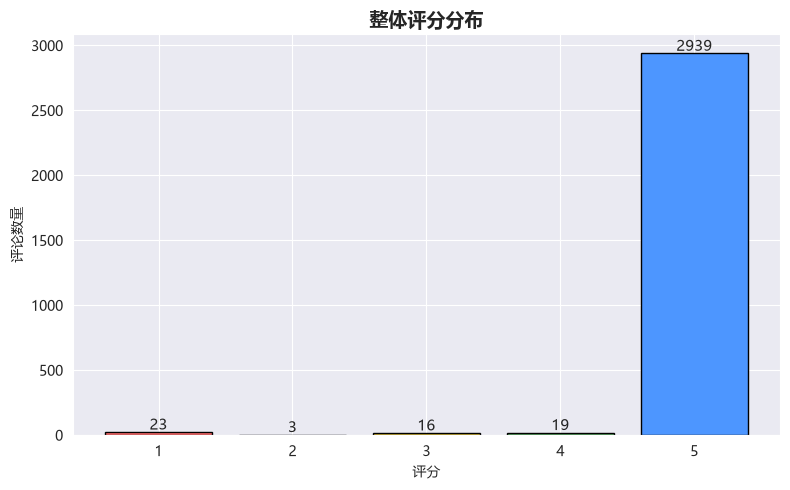

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))

# 评分分布
rating_counts = df["评分"].value_counts().sort_index()
colors = ['#ff6b6b', '#ffa502', '#ffd93d', '#6bcb77', '#4d96ff']
ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black')
ax.set_title("整体评分分布", fontsize=14, fontweight='bold')
ax.set_xlabel("评分")
ax.set_ylabel("评论数量")
ax.set_xticks([1, 2, 3, 4, 5])
for i, v in enumerate(rating_counts.values):
    ax.text(rating_counts.index[i], v + 20, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 可看出5分占绝大多数，可认为产品整体水平优秀

In [48]:
print(f"评分统计:")
print(f"平均分: {df['评分'].mean():.2f}")
print(f"中位数: {df['评分'].median()}")
print(f"5星占比: {(df['评分']==5).mean()*100:.1f}%")
print(f"好评率(4-5星): {((df['评分']>=4).mean()*100):.1f}%")
print(f"差评率(1-2星): {((df['评分']<=3).mean()*100):.1f}%")


评分统计:
平均分: 4.95
中位数: 5.0
5星占比: 98.0%
好评率(4-5星): 98.6%
差评率(1-2星): 1.4%


## 2.2 产品系列对比

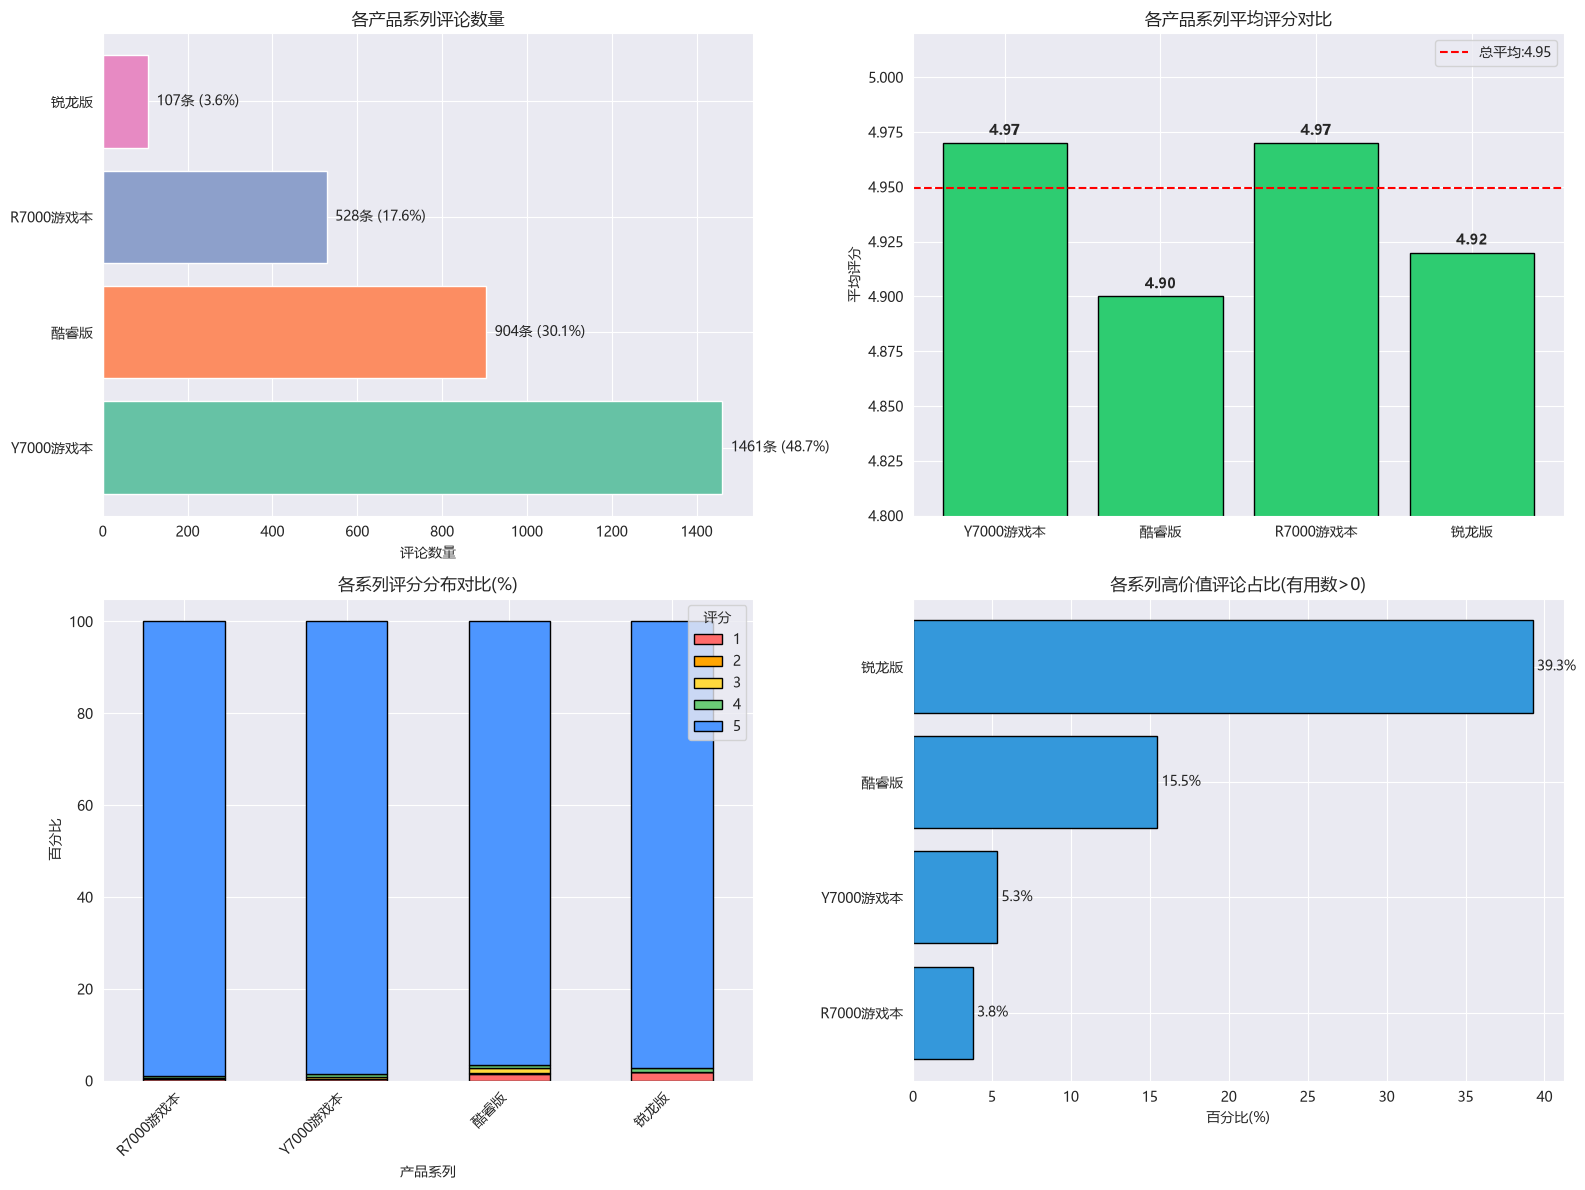

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
g = df.groupby("产品系列", observed=False)
stats = (g.agg(
        评论数量=("评分", "count"),
        平均评分=("评分", "mean"),
        总有用数=("有用数", "sum"),
        平均有用数=("有用数", "mean")
    ).round(2).sort_values("评论数量", ascending=False)
)

rating_dist = pd.crosstab(df["产品系列"], df["评分"], normalize="index") * 100
high_value_pct = (
    g.apply(lambda x: (x["有用数"] > 0).mean() * 100)
    .sort_values()
)
overall_mean_rating = df["评分"].mean()
total_n = len(df)

# 评论数量
ax = axes[0, 0]
colors = plt.cm.Set2(range(len(stats)))
bars = ax.barh(stats.index, stats["评论数量"], color=colors)
ax.set(title="各产品系列评论数量", xlabel="评论数量")
for i, v in enumerate(stats["评论数量"]):
    ax.text(v + 20, i, f"{v}条 ({v/total_n*100:.1f}%)", va="center", fontsize=10)

# 平均评分
ax = axes[0, 1]
colors_rating = ["#e74c3c" if x < 4.9 else "#2ecc71" for x in stats["平均评分"]]
bars = ax.bar(stats.index, stats["平均评分"], color=colors_rating, edgecolor="black")
ax.set(title="各产品系列平均评分对比", ylabel="平均评分", ylim=(4.8, 5.02))
ax.axhline(overall_mean_rating, color="red", linestyle="--",
           label=f"总平均:{overall_mean_rating:.2f}")
ax.legend()
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=11, fontweight="bold")

# 评分分布
ax = axes[1, 0]
rating_dist.plot(
    kind="bar", stacked=True, ax=ax,
    color=["#ff6b6b", "#ffa502", "#ffd93d", "#6bcb77", "#4d96ff"],
    edgecolor="black"
)
ax.set(title="各系列评分分布对比(%)", xlabel="产品系列", ylabel="百分比")
ax.legend(title="评分", loc="upper right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# 高价值评论占比
ax = axes[1, 1]
bars = ax.barh(high_value_pct.index, high_value_pct.values,
               color="#3498db", edgecolor="black")
ax.set(title="各系列高价值评论占比(有用数>0)", xlabel="百分比(%)")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)

plt.tight_layout()
plt.show()

In [50]:
df.groupby("产品系列",observed=False).agg({
    "评分": ["count", "mean", "median"],
    "有用数": ["mean", "sum"]
}).round(2)

评分                有用数     
         count  mean median  mean  sum
产品系列                                  
R7000游戏本   528  4.97    5.0  0.05   25
Y7000游戏本  1461  4.97    5.0  0.11  160
酷睿版        904  4.90    5.0  0.58  523
锐龙版        107  4.92    5.0  3.01  322

## 酷睿版在评论数量偏多、高价值评论占比不低的同时评分最低，可认为产品有待提升；Y7000和R7000评论数量多的同时评分高于平均线，认为大众比较满意
## 锐龙版由于样本较少，故高价值评论占比高，参考意义不大

## 2.4 评论质量分析

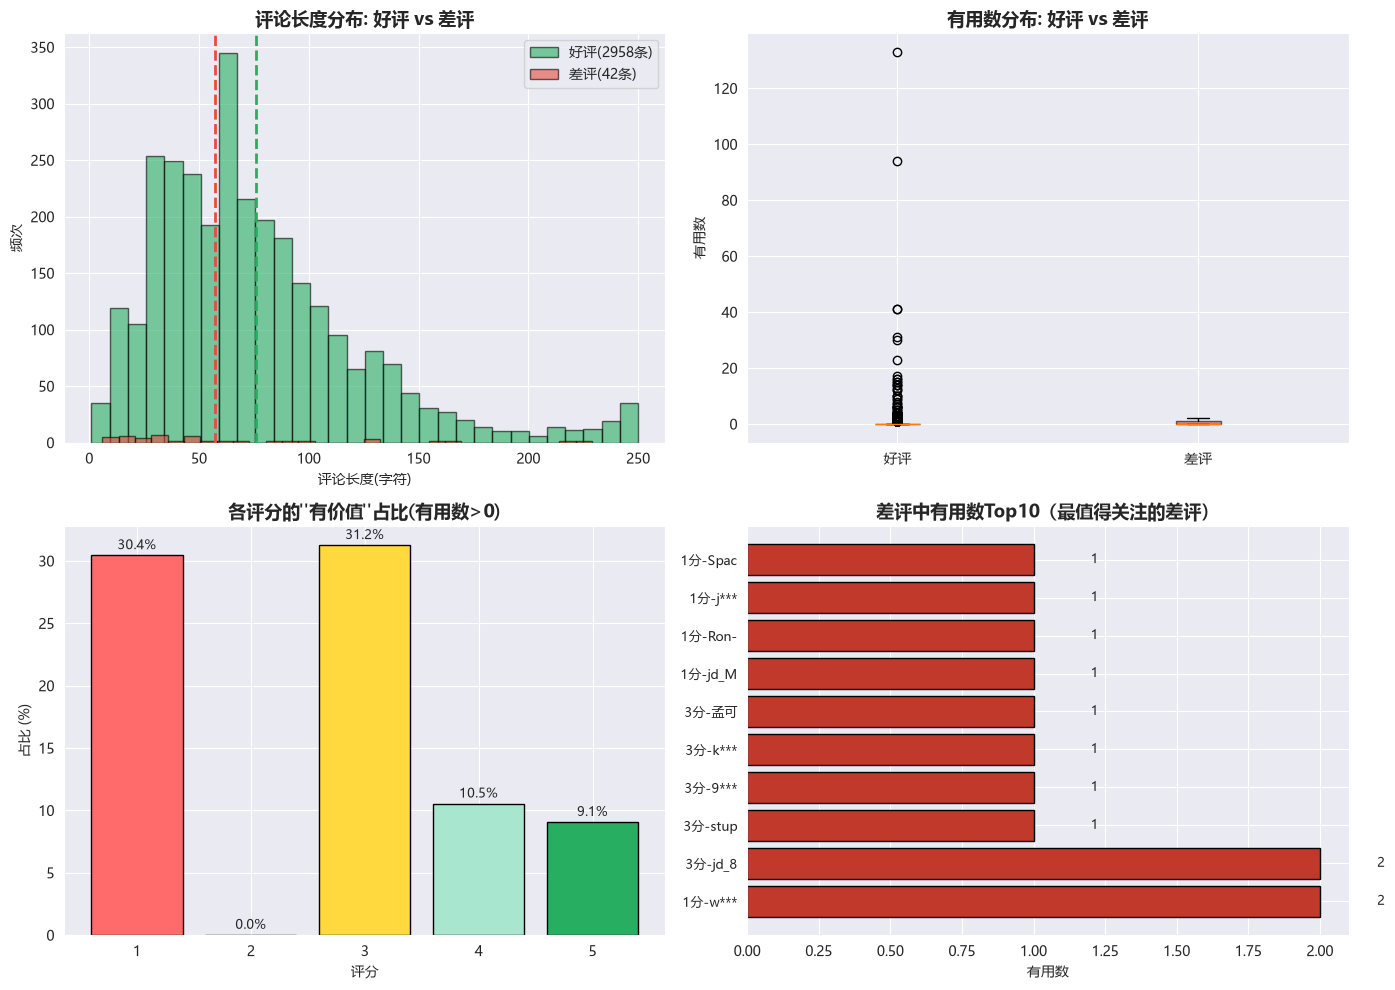

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df_neg = df[df["是否差评"] == '差评']
df_pos = df[df["是否差评"] == '好评']

# (1) 评论长度分布对比
ax1 = axes[0, 0]
ax1.hist(df_pos['评论长度'], bins=30, alpha=0.6, label=f'好评({len(df_pos)}条)', color='#27ae60', edgecolor='black')
ax1.hist(df_neg['评论长度'], bins=30, alpha=0.6, label=f'差评({len(df_neg)}条)', color='#e74c3c', edgecolor='black')
ax1.axvline(x=df_pos['评论长度'].mean(), color='#27ae60', linestyle='--', linewidth=2)
ax1.axvline(x=df_neg['评论长度'].mean(), color='#e74c3c', linestyle='--', linewidth=2)
ax1.set_title('评论长度分布: 好评 vs 差评', fontsize=13, fontweight='bold')
ax1.set_xlabel('评论长度(字符)')
ax1.set_ylabel('频次')
ax1.legend()

# (2) 有用数对比箱线图
ax2 = axes[0, 1]
data_box = [df_pos['有用数'].values, df_neg['有用数'].values]
bp = ax2.boxplot(data_box, tick_labels=['好评', '差评'], patch_artist=True)
bp['boxes'][0].set_facecolor('#27ae60'); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#e74c3c'); bp['boxes'][1].set_alpha(0.6)
ax2.set_title('有用数分布: 好评 vs 差评', fontsize=13, fontweight='bold')
ax2.set_ylabel('有用数')

# (3) 各评分的有用率（有用数>0的占比）
ax3 = axes[1, 0]
useful_rate_by_rating = df.groupby('评分').apply(lambda x: (x['有用数'] > 0).mean() * 100)
colors_rating = ['#ff6b6b', '#ffa502', '#ffd93d', '#a8e6cf', '#27ae60']
bars = ax3.bar(useful_rate_by_rating.index, useful_rate_by_rating.values, 
               color=colors_rating, edgecolor='black')
ax3.set_title('各评分的"有价值"占比(有用数>0)', fontsize=13, fontweight='bold')
ax3.set_xlabel('评分')
ax3.set_ylabel('占比 (%)')
ax3.set_xticks([1, 2, 3, 4, 5])
for bar, val in zip(bars, useful_rate_by_rating.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

# (4) 差评中有用数Top10（最有价值的差评）
ax4 = axes[1, 1]
top_neg_useful = df_neg.nlargest(10, '有用数')[['用户名', '评论内容', '有用数', '评分', '产品系列']]
y_pos = range(len(top_neg_useful))
ax4.barh(y_pos, top_neg_useful['有用数'].values, color='#c0392b', edgecolor='black')
ax4.set_yticks(y_pos)
ax4.set_yticklabels([f"{row['评分']}分-{row['用户名'][:4]}" for _, row in top_neg_useful.iterrows()], fontsize=9)
ax4.set_title('差评中有用数Top10（最值得关注的差评）', fontsize=13, fontweight='bold')
ax4.set_xlabel('有用数')
for i, v in enumerate(top_neg_useful['有用数']):
    ax4.text(v + 0.2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [52]:
print(f"样本量: 好评{len(df_pos)}条 | 差评{len(df_neg)}条\n")

print(f"评论长度:")
print(f"好评-均值:{df_pos['评论长度'].mean():.1f} | 中位数:{df_pos['评论长度'].median():.0f}")
print(f"差评-均值:{df_neg['评论长度'].mean():.1f} | 中位数:{df_neg['评论长度'].median():.0f}")
print(f"差评平均比好评{'长' if df_neg['评论长度'].mean()>df_pos['评论长度'].mean() else'短'}{abs(df_neg['评论长度'].mean()-df_pos['评论长度'].mean()):.1f}字\n")

print(f"有用数:")
print(f"好评-均值:{df_pos['有用数'].mean():.2f} | 有用率:{(df_pos['有用数']>0).mean()*100:.1f}%")
print(f"差评-均值:{df_neg['有用数'].mean():.2f} | 有用率:{(df_neg['有用数']>0).mean()*100:.1f}%")

样本量: 好评2958条 | 差评42条

评论长度:
好评-均值:75.9 | 中位数:66
差评-均值:57.3 | 中位数:32
差评平均比好评短18.6字

有用数:
好评-均值:0.34 | 有用率:9.1%
差评-均值:0.33 | 有用率:28.6%


## 好评的认可度和数量都普遍高于差评，但高价值评论占比差评要高于好评

# 下面的分析均聚焦在差评用户上

## 2.5 差评分析
## 宏观分析

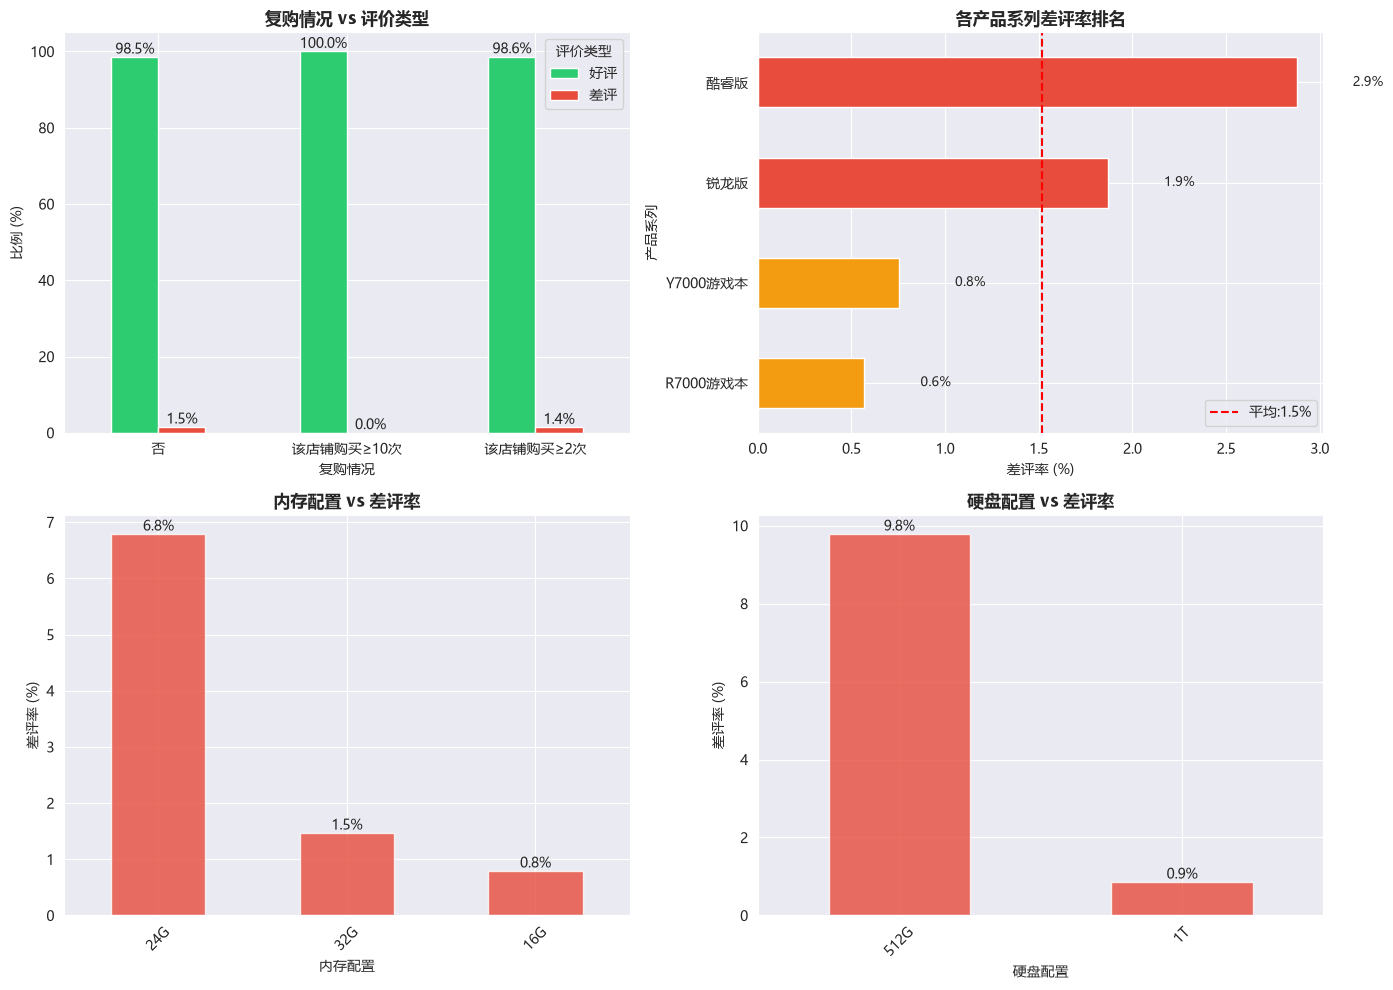

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) 复购情况 vs 评价类型
ax1 = axes[0, 0]
repurchase_sentiment = pd.crosstab(df['重复购买情况'], df['是否差评'], normalize='index') * 100
repurchase_sentiment.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('复购情况 vs 评价类型', fontsize=12, fontweight='bold')
ax1.set_xlabel('复购情况')
ax1.set_ylabel('比例 (%)')
ax1.legend(title='评价类型')
ax1.tick_params(axis='x', rotation=0)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%')

# (2) 产品系列 vs 差评率
ax2 = axes[0, 1]
product_neg_rate = df.groupby('产品系列').apply(
    lambda x: (x['评分'] <= 3).sum() / len(x) * 100
).sort_values(ascending=True)
colors = ['#e74c3c' if v > product_neg_rate.median() else '#f39c12' for v in product_neg_rate.values]
product_neg_rate.plot(kind='barh', ax=ax2, color=colors)
ax2.set_title('各产品系列差评率排名', fontsize=12, fontweight='bold')
ax2.set_xlabel('差评率 (%)')
ax2.axvline(x=product_neg_rate.mean(), color='red', linestyle='--', label=f'平均:{product_neg_rate.mean():.1f}%')
ax2.legend()
for i, v in enumerate(product_neg_rate.values):
    ax2.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# (3) 内存配置 vs 差评率
ax3 = axes[1, 0]
memory_neg_rate = df.groupby('内存').apply(
    lambda x: (x['评分'] <= 3).sum() / len(x) * 100
).sort_values(ascending=False)
memory_neg_rate.plot(kind='bar', ax=ax3, color='#e74c3c', alpha=0.8)
ax3.set_title('内存配置 vs 差评率', fontsize=12, fontweight='bold')
ax3.set_xlabel('内存配置')
ax3.set_ylabel('差评率 (%)')
ax3.tick_params(axis='x', rotation=45)
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1f%%')

# (4) 硬盘配置 vs 差评率
ax4 = axes[1, 1]
disk_neg_rate = df.groupby('硬盘').apply(
    lambda x: (x['评分'] <= 3).sum() / len(x) * 100
).sort_values(ascending=False)
disk_neg_rate.plot(kind='bar', ax=ax4, color='#e74c3c', alpha=0.8)
ax4.set_title('硬盘配置 vs 差评率', fontsize=12, fontweight='bold')
ax4.set_xlabel('硬盘配置')
ax4.set_ylabel('差评率 (%)')
ax4.tick_params(axis='x', rotation=45)
for container in ax4.containers:
    ax4.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

In [54]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # 饼图
# colors = ['#e74c3c', '#f39c12', '#27ae60']
# axes[0].pie(repurchase_dist.values, labels=repurchase_dist.index, 
#             autopct='%1.1f%%', colors=colors[:len(repurchase_dist)],
#             explode=[0.05]*len(repurchase_dist), startangle=90)
# axes[0].set_title(f'差评中复购情况分布 (n={len(df_negative)})', fontweight='bold')

# # 柱状图（二分类）
# ax1 = axes[1]
# bars = ax1.bar(['首次购买', '>=2次购买'], [first_buy, repeat_buy], 
#                color=['#3498db', '#9b59b6'], edgecolor='white')
# ax1.set_title('差评中首次购买 vs 复购', fontweight='bold')
# ax1.set_ylabel('评论数')
# for bar, val in zip(bars, [first_buy, repeat_buy]):
#     ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
#              f'{val}\n({val/len(df_negative)*100:.1f}%)', 
#              ha='center', va='bottom', fontsize=11)

# plt.tight_layout()
# plt.show()

## 得出的结论与2.2一致，此外，24G+512G的配置普遍评价偏低，后文会着重分析

In [55]:
# 定义问题关键词词典
issue_keywords = {
    '性能/卡顿': ['卡', '慢', '卡顿', '死机', '卡死', '延迟', '不流畅', '反应慢', ' lag ', '掉帧'],
    '屏幕问题': ['屏幕', '显示', '模糊', '亮点', '坏点', '漏光', '闪屏', '花屏', '分辨率', '清晰'],
    '散热/噪音': ['热', '烫', '风扇', '噪音', '响', '散热', '温度高', '发烫', '嗡嗡'],
    '电池/续航': ['电池', '续航', '充电', '耗电', '掉电', '电源', '充电器', '漏电'],
    '键盘/触控板': ['键盘', '键程', '按键', '触摸板', '触控', '打字', '手感'],
    '外观/做工': ['外壳', '做工', '质感', '缝隙', '磨损', '划痕', '旧机', '瑕疵', '后盖'],
    '网络/连接': ['wifi', '无线', '蓝牙', '网络', '连不上', '断网', '网卡', '信号'],
    '系统/软件': ['系统', 'windows', '驱动', '预装', '广告', '弹窗', '激活', '蓝屏', '黑屏'],
    '价格/售后': ['降价', '贵', '退款', '售后', '客服', '换货', '维修', '保修', '国补', '价格'],
    '物流/包装': ['物流', '快递', '包装', '破损', '运输', '配送']
}

## 差评宏观关键词分布

In [56]:
def classify_issue(text):
    # 对单条评论进行问题分类
    if pd.isna(text) or text == '此用户未及时填写评价内容':
        return ['无实质内容']
    text_lower = str(text).lower()
    found_issues = []
    for issue, keywords in issue_keywords.items():
        for kw in keywords:
            if kw.lower() in text_lower:
                found_issues.append(issue)
                break
    return found_issues if found_issues else ['其他']

df_negative['问题分类'] = df_negative['评论内容'].apply(classify_issue)

all_issues = []
for issues_list in df_negative['问题分类']:
    all_issues.extend(issues_list)

issue_counts = Counter(all_issues)
issue_df = pd.DataFrame(issue_counts.most_common(), columns=['问题类别', '出现次数'])
issue_df['占比(%)'] = (issue_df['出现次数'] / len(df_negative) * 100).round(1)

print("差评问题分类统计（一条评论可能涉及多个问题）:")
print(issue_df.to_string(index=False))

差评问题分类统计（一条评论可能涉及多个问题）:
  问题类别  出现次数  占比(%)
 价格/售后    12   28.6
 性能/卡顿    12   28.6
    其他     9   21.4
 电池/续航     7   16.7
 系统/软件     7   16.7
  屏幕问题     6   14.3
 物流/包装     4    9.5
键盘/触控板     3    7.1
 外观/做工     3    7.1
 散热/噪音     2    4.8
 网络/连接     1    2.4


## 差评用户主要对价格、性能、续航能力不满

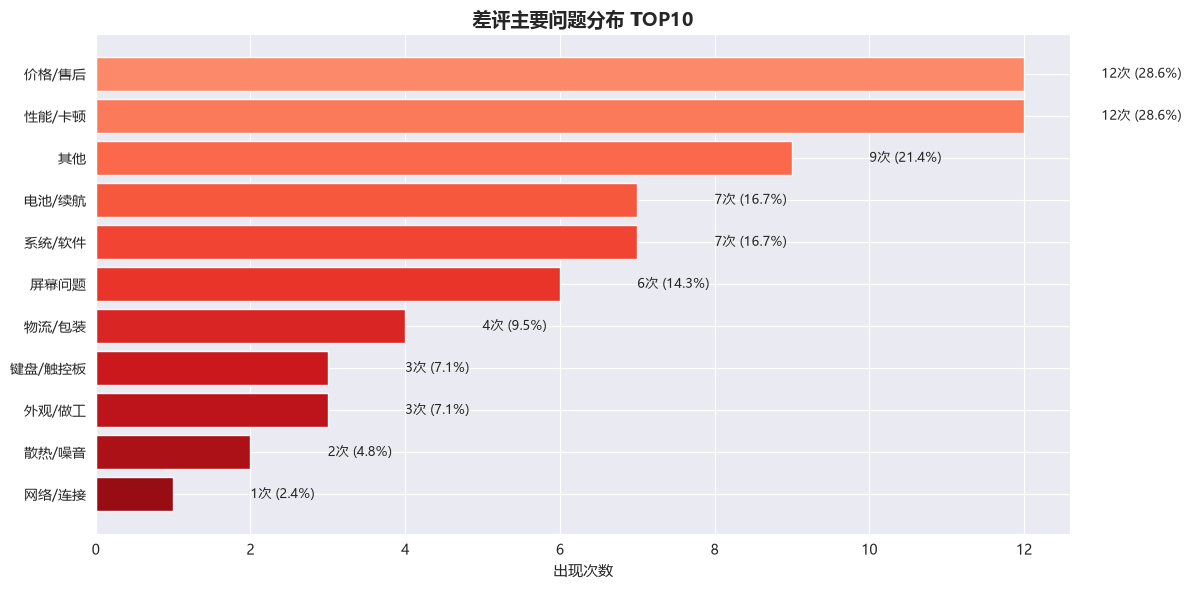

In [57]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(issue_df)))
bars = ax.barh(issue_df['问题类别'], issue_df['出现次数'], color=colors)
ax.set_xlabel('出现次数', fontsize=11)
ax.set_title('差评主要问题分布 TOP10', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for bar, count, pct in zip(bars, issue_df['出现次数'], issue_df['占比(%)']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{count}次 ({pct}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 高频差评配置

In [58]:
# 差评率最高的配置组合
print("差评率TOP5配置组合:")
config_neg_rate = df.groupby(['产品系列', '内存', '硬盘']).agg(
    总评论数=('评分', 'count'),
    差评数=('评分', lambda x: (x <= 3).sum()),
    差评率=('评分', lambda x: (x <= 3).sum() / len(x) * 100),
    平均评分=('评分', 'mean'),
    平均情感=('情感分数', 'mean')
).round(2)
config_neg_rate = config_neg_rate.sort_values('差评率', ascending=False)
print(config_neg_rate.head(5))

# 差评关键词与产品配置关联
def get_main_issue(text):
    if pd.isna(text):
        return '未知'
    text_lower = str(text).lower()
    max_overlap = 0
    main_issue = '其他'
    for issue, keywords in issue_keywords.items():
        overlap = sum(1 for kw in keywords if kw.lower() in text_lower)
        if overlap > max_overlap:
            max_overlap = overlap
            main_issue = issue
    return main_issue
df_negative['主要问题'] = df_negative['评论内容'].apply(get_main_issue)

# 问题 × 产品系列 交叉分析
issue_product = pd.crosstab(df_negative['主要问题'], df_negative['产品系列'], normalize='columns') * 100
print("\n各产品系列的主要差诉问题占比(%):")
print(issue_product.round(1))

差评率TOP5配置组合:
                   总评论数  差评数    差评率  平均评分  平均情感
产品系列     内存  硬盘                                
酷睿版      24G 512G   132   15  11.36  4.52  0.73
R7000游戏本 16G 512G    13    1   7.69  4.69  0.90
锐龙版      16G 512G    38    2   5.26  4.76  0.76
酷睿版      32G 1T     742   11   1.48  4.97  0.97
Y7000游戏本 16G 1T    1461   11   0.75  4.97  0.94

各产品系列的主要差诉问题占比(%):
产品系列    R7000游戏本  Y7000游戏本   酷睿版   锐龙版
主要问题                                  
价格/售后       33.3       0.0   7.7   0.0
其他          33.3      18.2  19.2  50.0
外观/做工        0.0       0.0   7.7   0.0
屏幕问题         0.0       9.1   3.8  50.0
性能/卡顿        0.0      27.3  26.9   0.0
物流/包装       33.3       9.1   3.8   0.0
电池/续航        0.0       9.1  15.4   0.0
系统/软件        0.0      18.2   7.7   0.0
网络/连接        0.0       9.1   0.0   0.0
键盘/触控板       0.0       0.0   7.7   0.0


## 结论和之前的分析一致，酷睿版+24G+512G差评数最多

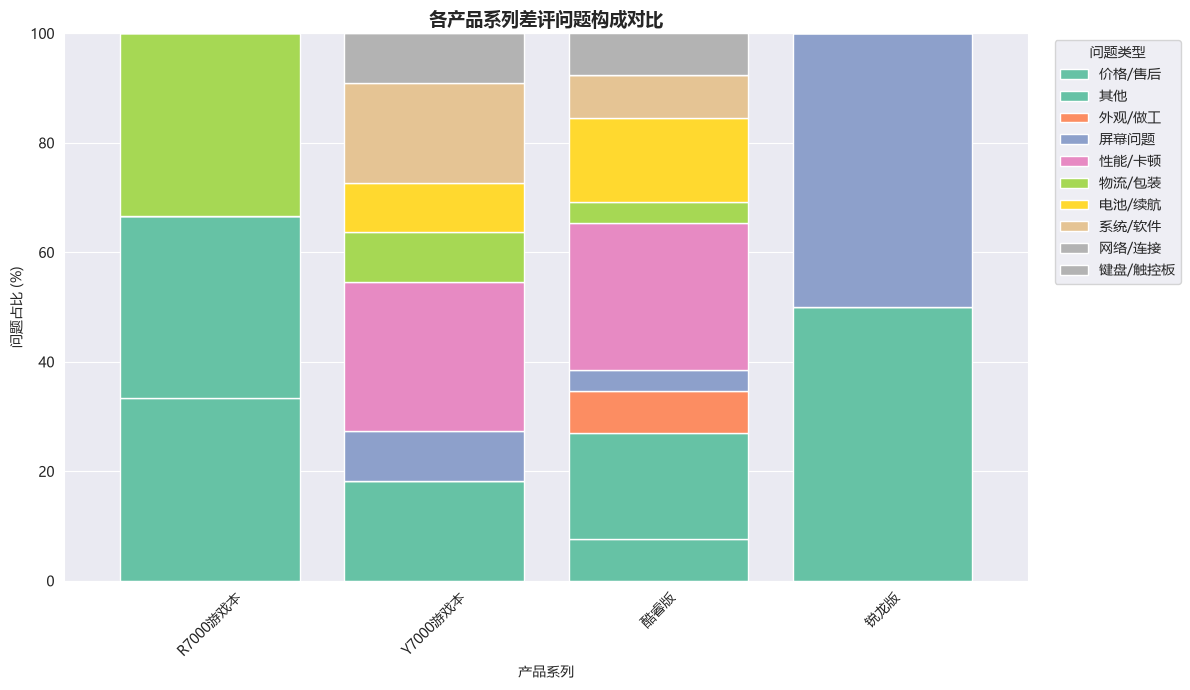

In [59]:
fig, ax = plt.subplots(figsize=(12, 7))
issue_product.T.plot(kind='bar', stacked=True, ax=ax, 
                     colormap='Set2', width=0.8)
ax.set_title('各产品系列差评问题构成对比', fontsize=13, fontweight='bold')
ax.set_xlabel('产品系列')
ax.set_ylabel('问题占比 (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='问题类型', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 客户对酷睿版应的性能和续航问题，Y7000的性能和系统问题主要不满

## 精准分析

In [60]:
# 提取要研究的数据
target_products = df[df['产品系列'].str.contains('酷睿', na=False)] if df['产品系列'].dtype == object else df[df['产品系列'].astype(str).str.contains('酷睿', na=False)]
target_memory_24 = df[df['内存'].astype(str).str.contains('24', na=False)]
target_disk_512 = df[df['硬盘'].astype(str).str.contains('512', na=False)]
combo_high_risk = df[
    (df['产品系列'].astype(str).str.contains('酷睿', na=False)) &
    (df['内存'].astype(str).str.contains('24', na=False)) &
    (df['硬盘'].astype(str).str.contains('512', na=False))
]

print(f"酷睿版:")
print(f"评论数: {len(target_products)}")
print(f"差评数(≤3分): {(target_products['评分'] <= 3).sum()} ({(target_products['评分'] <= 3).sum()/len(target_products)*100:.1f}%)")
print(f"平均评分: {target_products['评分'].mean():.2f}")
print(f"平均情感分: {target_products['情感分数'].mean():.3f}\n")

print(f"24G内存配置:")
print(f"评论数: {len(target_memory_24)}")
print(f"差评数(≤3分): {(target_memory_24['评分'] <= 3).sum()} ({(target_memory_24['评分'] <= 3).sum()/len(target_memory_24)*100:.1f}%)")
print(f"平均评分: {target_memory_24['评分'].mean():.2f}")
print(f"平均情感分: {target_memory_24['情感分数'].mean():.3f}\n")

print(f"512G硬盘配置:")
print(f"评论数: {len(target_disk_512)}")
print(f"差评数(≤3分): {(target_disk_512['评分'] <= 3).sum()} ({(target_disk_512['评分'] <= 3).sum()/len(target_disk_512)*100:.1f}%)")
print(f"平均评分: {target_disk_512['评分'].mean():.2f}")
print(f"平均情感分: {target_disk_512['情感分数'].mean():.3f}\n")

if len(combo_high_risk) > 0:
    print(f"高风险组合(酷睿+24G+512G):")
    print(f"评论数: {len(combo_high_risk)}")
    print(f"差评数(≤3分): {(combo_high_risk['评分'] <= 3).sum()} ({(combo_high_risk['评分'] <= 3).sum()/len(combo_high_risk)*100:.1f}%)")
    print(f"平均评分: {combo_high_risk['评分'].mean():.2f}")
    print(f"平均情感分: {combo_high_risk['情感分数'].mean():.3f}\n")

酷睿版:
评论数: 904
差评数(≤3分): 26 (2.9%)
平均评分: 4.90
平均情感分: 0.934

24G内存配置:
评论数: 221
差评数(≤3分): 15 (6.8%)
平均评分: 4.71
平均情感分: 0.824

512G硬盘配置:
评论数: 184
差评数(≤3分): 18 (9.8%)
平均评分: 4.58
平均情感分: 0.752

高风险组合(酷睿+24G+512G):
评论数: 132
差评数(≤3分): 15 (11.4%)
平均评分: 4.52
平均情感分: 0.733



## 酷睿版差评分析

In [61]:
# if len(target_products) > 0:
#     # 提取酷睿版差评
#     kuoru_negative = target_products[target_products['评分'] <= 3].copy()
#     kuoru_negative['主要问题'] = kuoru_negative['评论内容'].apply(get_main_issue)
#     print(f"酷睿版差评概况: {len(kuoru_negative)}条")
    
#     # 问题分布
#     issue_dist_kuoru = kuoru_negative['主要问题'].value_counts()
#     issue_dist_kuoru_pct = (issue_dist_kuoru / len(kuoru_negative) * 100).round(1)
    
#     print("酷睿版差评 TOP 问题:")
#     for issue, count in issue_dist_kuoru.head(8).items():
#         pct = issue_dist_kuoru_pct[issue]
#         # 与全量差评对比
#         all_neg = df[df['评分'] <= 3].copy()
#         all_neg['主要问题_tmp'] = all_neg['评论内容'].apply(get_main_issue)
#         all_issue_pct = (all_neg['主要问题_tmp'] == issue).sum() / len(all_neg) * 100
#         diff = pct - all_issue_pct
#         marker = "显著偏高" if diff > 5 else ("持平" if abs(diff) <= 2 else "偏低")
#         print(f"{issue}: {count}条({pct}%) [全量:{all_issue_pct:.1f}%] {marker}")
    
#     # 可视化：酷睿版 vs 全量 差评问题对比
#     fig, ax = plt.subplots(figsize=(12, 6))
    
#     all_neg['主要问题_tmp'] = all_neg['评论内容'].apply(get_main_issue)
#     top_issues = list(issue_dist_kuoru.head(7).index)
    
#     x = np.arange(len(top_issues))
#     width = 0.35
    
#     kuoru_pct = [(kuoru_negative['主要问题'] == i).sum() / len(kuoru_negative) * 100 for i in top_issues]
#     all_pct = [(all_neg['主要问题_tmp'] == i).sum() / len(all_neg) * 100 for i in top_issues]
    
#     bars1 = ax.bar(x - width/2, kuoru_pct, width, label='酷睿版差评', color='#e74c3c', alpha=0.8)
#     bars2 = ax.bar(x + width/2, all_pct, width, label='全量差评', color='#3498db', alpha=0.8)
    
#     ax.set_ylabel('问题占比 (%)')
#     ax.set_title('酷睿版 vs 全量差评问题构成对比', fontsize=13, fontweight='bold')
#     ax.set_xticks(x)
#     ax.set_xticklabels(top_issues, rotation=45, ha='right')
#     ax.legend()
    
#     for bars in [bars1, bars2]:
#         for bar in bars:
#             height = bar.get_height()
#             ax.annotate(f'{height:.1f}%',
#                        xy=(bar.get_x() + bar.get_width() / 2, height),
#                        xytext=(0, 3), textcoords="offset points",
#                        ha='center', va='bottom', fontsize=8)
    
#     plt.tight_layout()
#     plt.show()

## 24g运行内存差评分析

In [62]:
# if len(target_memory_24) > 0:
#     mem24_negative = target_memory_24[target_memory_24['评分'] <= 3].copy()
#     mem24_negative['主要问题'] = mem24_negative['评论内容'].apply(get_main_issue)
    
#     print(f"24G内存配置差评概况: {len(mem24_negative)}条")
#     print(f"该配置总评论: {len(target_memory_24)}, 差评率: {len(mem24_negative)/len(target_memory_24)*100:.1f}%")
    
#     # 问题分布
#     issue_dist_mem24 = mem24_negative['主要问题'].value_counts()
    
#     print("24G内存配置差评 TOP 问题:")
#     for issue, count in issue_dist_mem24.head(6).items():
#         pct = count / len(mem24_negative) * 100
#         print(f"{issue}: {count}条({pct:.1f}%)")

In [63]:
# data = mem24_negative['主要问题'].value_counts()
# plt.figure(figsize=(9,7))
# data.plot(
#     kind='pie', autopct='%1.1f%%', colors=plt.cm.Reds(np.linspace(0.3,0.9,len(data))),
#     explode=[0.08]+[0.02]*(len(data)-1), startangle=90
# )
# plt.title(f'24G内存差评问题分布 ({len(mem24_negative)}条 | 差评率{len(mem24_negative)/len(target_memory_24)*100:.1f}%)')
# plt.ylabel('')
# plt.tight_layout()
# plt.show()

## 512G硬盘配置差评分析

In [64]:
# if len(target_disk_512) > 0:
#     disk512_negative = target_disk_512[target_disk_512['评分'] <= 3].copy()
#     disk512_negative['主要问题'] = disk512_negative['评论内容'].apply(get_main_issue)
    
#     print(f"512G硬盘配置差评概况: {len(disk512_negative)}条")
#     print(f"该配置总评论: {len(target_disk_512)}, 差评率: {len(disk512_negative)/len(target_disk_512)*100:.1f}%\n")
    
#     # 问题分布
#     issue_dist_disk512 = disk512_negative['主要问题'].value_counts()
    
#     print("512G硬盘配置差评 TOP 问题:")
#     for issue, count in issue_dist_disk512.head(6).items():
#         pct = count / len(disk512_negative) * 100
#         print(f"{issue}: {count}条({pct:.1f}%)")

In [65]:
# data2 = disk512_negative['主要问题'].value_counts()
# plt.figure(figsize=(9,7))
# data2.plot(
#     kind='pie', autopct='%1.1f%%', colors=plt.cm.Oranges(np.linspace(0.3,0.9,len(data2))),
#     explode=[0.08]+[0.02]*(len(data2)-1), startangle=90
# )
# plt.title(f'512G硬盘差评问题分布 ({len(disk512_negative)}条 | 差评率{len(disk512_negative)/len(target_disk_512)*100:.1f}%)')
# plt.ylabel('')
# plt.tight_layout()
# plt.show()

## 发现这三类电脑的核心问题均是性能/卡顿+电池/续航，故这三类和其中任意组合的电脑应在相关方面进行改善

## 2.6 差评用户画像分析

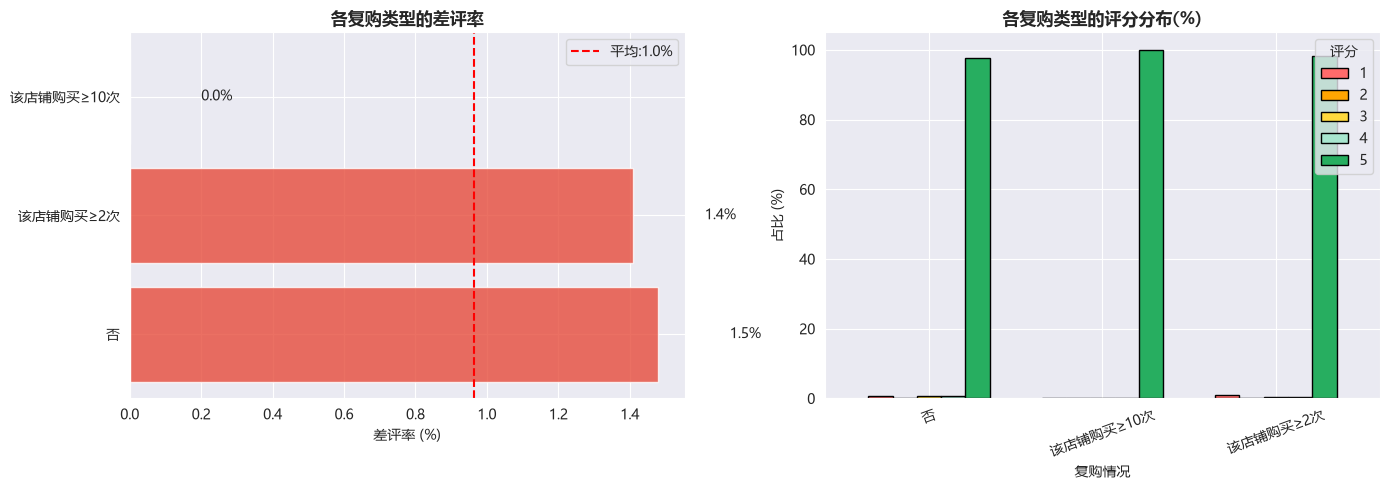

复购情况 × 差评详情:
           总评论数  差评数   好评数   差评率  平均评分
重复购买情况                                
否          1685   25  1660  1.48  4.95
该店铺购买≥2次   1205   17  1188  1.41  4.95
该店铺购买≥10次   110    0   110  0.00  5.00


In [66]:
df_negative = df[df['评分'] <= 3].copy()
df_positive = df[df['评分'] >= 4].copy()

# (1) 复购情况 × 差评深度交叉分析
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
repurchase_detail = df.groupby('重复购买情况').agg(
    总评论数=('评分', 'count'),
    差评数=('评分', lambda x: (x <= 3).sum()),
    好评数=('评分', lambda x: (x >= 4).sum()),
    差评率=('评分', lambda x: (x <= 3).sum() / len(x) * 100),
    平均评分=('评分', 'mean')
).round(2)
repurchase_detail = repurchase_detail.sort_values('差评率', ascending=False)

colors_rep = ['#e74c3c' if v > repurchase_detail['差评率'].mean() else '#f39c12' 
              for v in repurchase_detail['差评率']]
bars = ax1.barh(repurchase_detail.index, repurchase_detail['差评率'], color=colors_rep, alpha=0.8)
ax1.set_title('各复购类型的差评率', fontsize=12, fontweight='bold')
ax1.set_xlabel('差评率 (%)')
ax1.axvline(x=repurchase_detail['差评率'].mean(), color='red', linestyle='--', 
            label=f'平均:{repurchase_detail["差评率"].mean():.1f}%')
ax1.legend()
for bar, val in zip(bars, repurchase_detail['差评率']):
    ax1.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)

# 复购 × 评分分布堆叠柱状图
ax2 = axes[1]
repurchase_rating = pd.crosstab(df['重复购买情况'], df['评分'], normalize='index') * 100
repurchase_rating.plot(kind='bar', ax=ax2, 
                       color=['#ff6b6b','#ffa502','#ffd93d','#a8e6cf','#27ae60'],
                       edgecolor='black', width=0.7)
ax2.set_title('各复购类型的评分分布(%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('复购情况')
ax2.set_ylabel('占比 (%)')
ax2.legend(title='评分', loc='upper right')
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print("复购情况 × 差评详情:")
print(repurchase_detail.to_string())

## 高粘性用户群体不会打差评，往往是新客在打差评

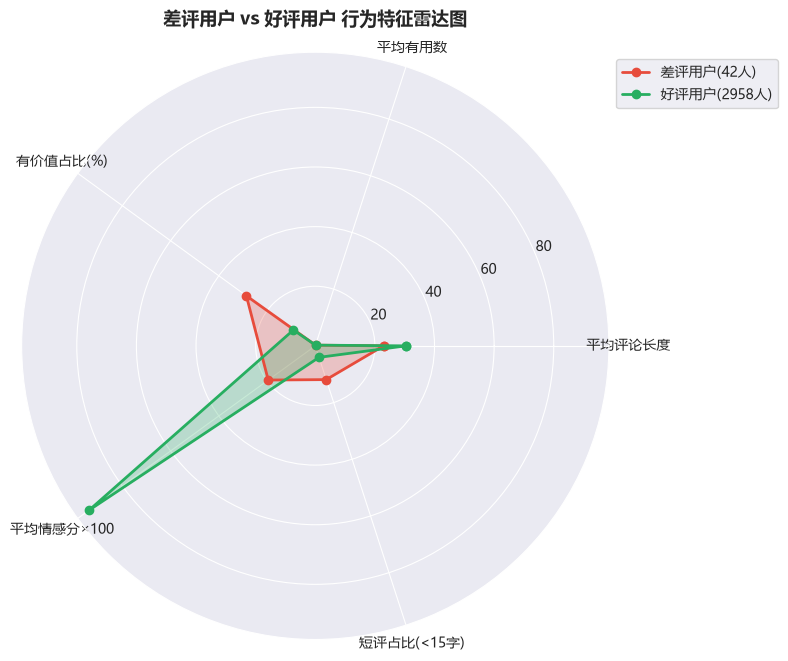

用户行为特征对比:
指标                         差评用户         好评用户         差异
平均评论长度                   22.9         30.4      -7.4 偏低
平均有用数                     0.3          0.3      -0.0 持平
有价值占比(%)                 28.6          9.1     +19.5 偏高
平均情感分×100                19.5         93.8     -74.3 偏低
短评占比(<15字)               11.9          4.1      +7.8 偏高


In [67]:
# (2) 差评用户行为特征雷达图（vs 好评用户基准线）
from math import pi

# 计算各维度指标（归一化到0-100）
metrics = {
    '平均评论长度': (df_negative['评论长度'].mean() / df['评论长度'].max()) * 100,
    '平均有用数': (df_negative['有用数'].mean() / df['有用数'].max()) * 100,
    '有价值占比(%)': (df_negative['有用数'] > 0).mean() * 100,
    '平均情感分×100': df_negative['情感分数'].mean() * 100,
    '短评占比(<15字)': (df_negative['评论长度'] < 15).mean() * 100,
}
metrics_pos = {
    '平均评论长度': (df_positive['评论长度'].mean() / df['评论长度'].max()) * 100,
    '平均有用数': (df_positive['有用数'].mean() / df['有用数'].max()) * 100,
    '有价值占比(%)': (df_positive['有用数'] > 0).mean() * 100,
    '平均情感分×100': df_positive['情感分数'].mean() * 100,
    '短评占比(<15字)': (df_positive['评论长度'] < 15).mean() * 100,
}

categories = list(metrics.keys())
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

values_neg = list(metrics.values()) + [list(metrics.values())[0]]
values_pos = list(metrics_pos.values()) + [list(metrics_pos.values())[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, values_neg, 'o-', linewidth=2, label=f'差评用户({len(df_negative)}人)', color='#e74c3c')
ax.fill(angles, values_neg, alpha=0.25, color='#e74c3c')
ax.plot(angles, values_pos, 'o-', linewidth=2, label=f'好评用户({len(df_positive)}人)', color='#27ae60')
ax.fill(angles, values_pos, alpha=0.25, color='#27ae60')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_title('差评用户 vs 好评用户 行为特征雷达图', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

print("用户行为特征对比:")
print(f"{'指标':<18} {'差评用户':>12} {'好评用户':>12} {'差异':>10}")
for cat in categories:
    v_neg = metrics[cat]
    v_pos = metrics_pos[cat]
    diff = v_neg - v_pos
    marker = "偏高" if diff > 5 else ("偏低" if diff < -5 else "持平")
    print(f"{cat:<18} {v_neg:>10.1f}   {v_pos:>10.1f}   {diff:>+7.1f} {marker}")

## 差评往往更容易引起共鸣，而且评论长度偏短

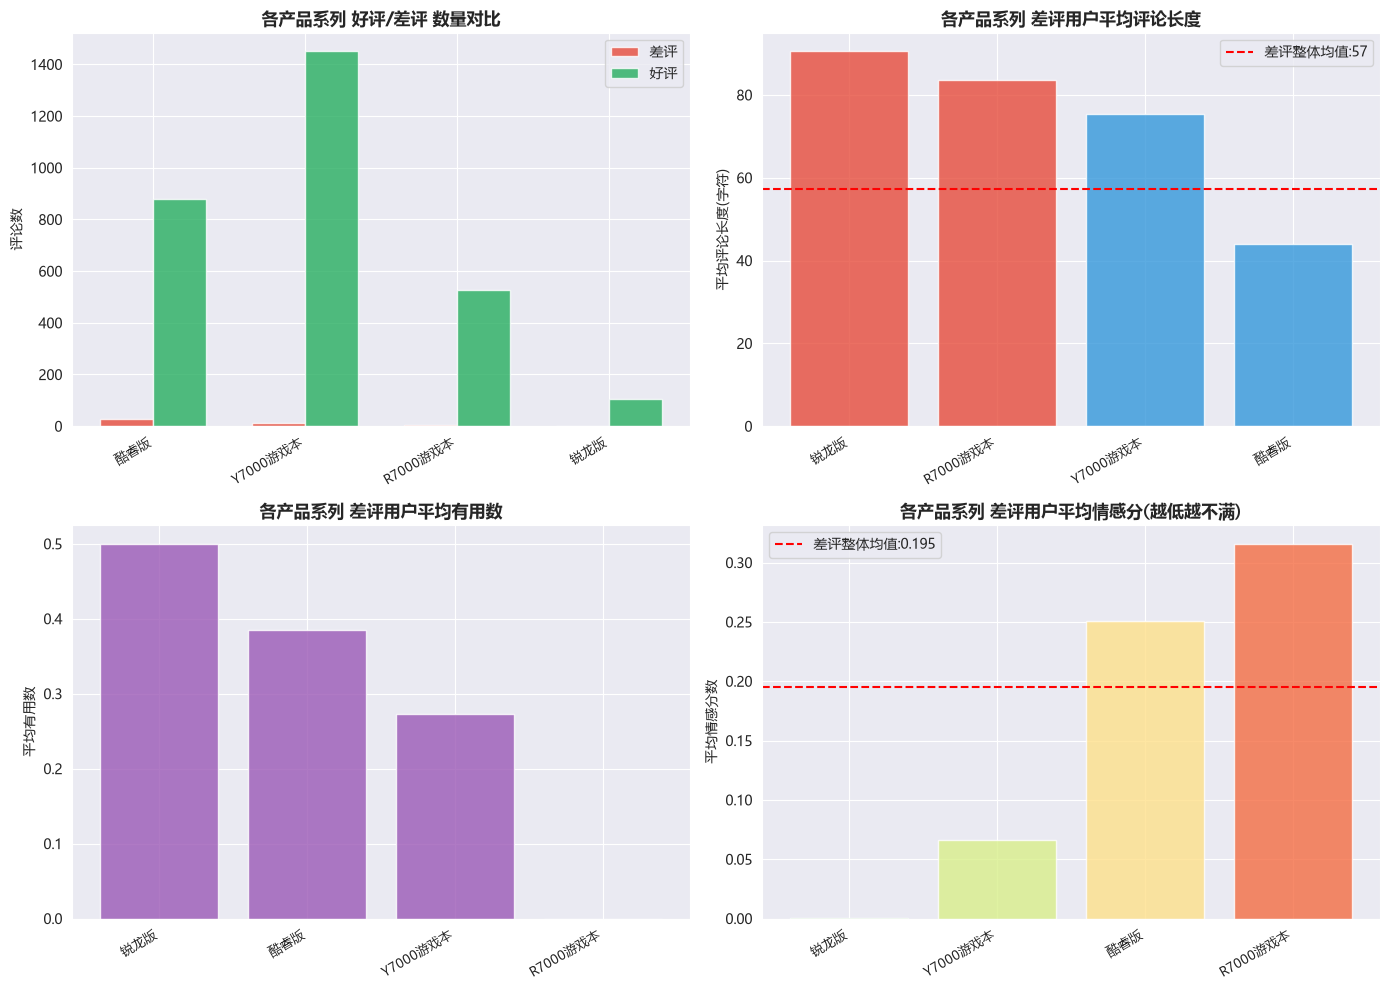

In [68]:
# (3) 各产品系列差评用户画像对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 各系列差评用户数量
ax1 = axes[0, 0]
neg_by_product = df_negative['产品系列'].value_counts()
pos_by_product = df_positive['产品系列'].value_counts()
x = np.arange(len(neg_by_product))
width = 0.35
ax1.bar(x - width/2, neg_by_product.values, width, label='差评', color='#e74c3c', alpha=0.8)
ax1.bar(x + width/2, [pos_by_product.get(p, 0) for p in neg_by_product.index], width, label='好评', color='#27ae60', alpha=0.8)
ax1.set_title('各产品系列 好评/差评 数量对比', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(neg_by_product.index, rotation=30, ha='right', fontsize=9)
ax1.legend()
ax1.set_ylabel('评论数')

# 各系列差评用户平均评论长度
ax2 = axes[0, 1]
avg_len_neg = df_negative.groupby('产品系列')['评论长度'].mean().sort_values(ascending=False)
avg_len_all = df.groupby('产品系列')['评论长度'].mean()
colors_len = ['#e74c3c' if avg_len_neg[p] > avg_len_all.get(p, 0) else '#3498db' for p in avg_len_neg.index]
bars = ax2.bar(range(len(avg_len_neg)), avg_len_neg.values, color=colors_len, alpha=0.8)
ax2.set_title('各产品系列 差评用户平均评论长度', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(avg_len_neg)))
ax2.set_xticklabels(avg_len_neg.index, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('平均评论长度(字符)')
ax2.axhline(y=df_negative['评论长度'].mean(), color='red', linestyle='--', 
            label=f'差评整体均值:{df_negative["评论长度"].mean():.0f}')
ax2.legend()

# 各系列差评用户平均有用数
ax3 = axes[1, 0]
avg_useful_neg = df_negative.groupby('产品系列')['有用数'].mean().sort_values(ascending=False)
bars3 = ax3.bar(range(len(avg_useful_neg)), avg_useful_neg.values, color='#9b59b6', alpha=0.8)
ax3.set_title('各产品系列 差评用户平均有用数', fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(avg_useful_neg)))
ax3.set_xticklabels(avg_useful_neg.index, rotation=30, ha='right', fontsize=9)
ax3.set_ylabel('平均有用数')

# 各系列差评用户平均情感分
ax4 = axes[1, 1]
avg_sent_neg = df_negative.groupby('产品系列')['情感分数'].mean().sort_values()
colors_sent = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(avg_sent_neg)))
bars4 = ax4.bar(range(len(avg_sent_neg)), avg_sent_neg.values, color=colors_sent, alpha=0.8)
ax4.set_title('各产品系列 差评用户平均情感分(越低越不满)', fontsize=12, fontweight='bold')
ax4.set_xticks(range(len(avg_sent_neg)))
ax4.set_xticklabels(avg_sent_neg.index, rotation=30, ha='right', fontsize=9)
ax4.set_ylabel('平均情感分数')
ax4.axhline(y=df_negative['情感分数'].mean(), color='red', linestyle='--',
            label=f'差评整体均值:{df_negative["情感分数"].mean():.3f}')
ax4.legend()

plt.tight_layout()
plt.show()

## 从评论长度、有用数和情感分来看，酷睿版差评偏短，平均感情分偏高，故认为是理性的指出问题居多，锐龙版由于差评样本量太小导致参考性不强

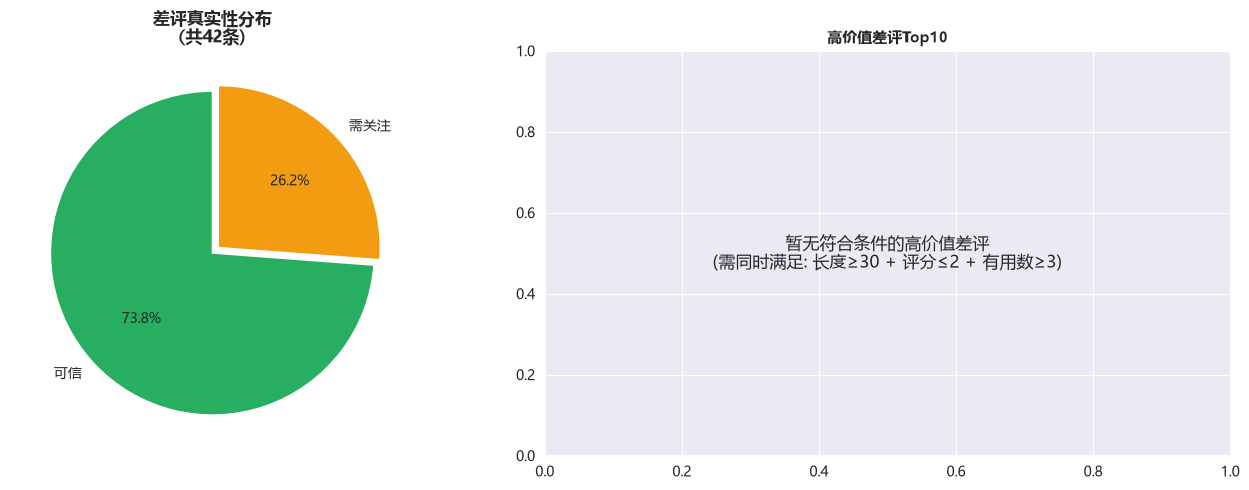

差评真实性检测结果:
可信: 31条 (73.8%)

需关注: 11条 (26.2%)

高价值差评(长文+低分+有用≥3): 0条


In [69]:
# (4) 高价值差评用户识别 & 可疑差评初筛
# 高价值差评（长文+低分+高有用数 → 最值得关注的真实反馈）
df_negative['是否高价值'] = (df_negative['评论长度'] >= 30) & (df_negative['评分'] <= 2) & (df_negative['有用数'] >= 3)
high_value_neg = df_negative[df_negative['是否高价值']].sort_values('有用数', ascending=False)

# 可疑差评初筛规则
def detect_suspicious(row):
    """检测可疑差评"""
    score = 0
    reasons = []
    
    # 规则1: 评论过短且无实质内容
    if row['评论长度'] <= 10:
        score += 1
        reasons.append('超短评')
    # 规则2: 默认填充文本
    if str(row['评论内容']).strip() in ['此用户未及时填写评价内容', '', '无']:
        score += 3
        reasons.append('默认填充')
    # 规则3: 低分但情感分数异常高（疑似刷单）
    if row['评分'] <= 2 and row['情感分数'] > 0.7:
        score += 2
        reasons.append('情感异常')
    # 规则4: 纯情绪发泄无具体问题描述
    if row['评论长度'] > 5 and row['评论长度'] < 20:
        has_specific = any(kw in str(row['评论内容']) for kw in ['卡', '慢', '热', '屏幕', '键盘', '系统', '售后'])
        if not has_specific:
            score += 1
            reasons.append('无具体问题')
    
    if score == 0:
        return '可信'
    elif score <= 2:
        return f'需关注({"+".join(reasons)})'
    else:
        return f'高风险({"+".join(reasons)})'

df_negative['可疑程度'] = df_negative.apply(detect_suspicious, axis=1)

# 统计
suspicious_stats = df_negative['可疑程度'].str.extract(r'(可信|需关注|高风险)')[0].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 可信度分布饼图
ax1 = axes[0]
sus_colors = {'可信': '#27ae60', '需关注': '#f39c12', '高风险': '#e74c3c'}
sus_labels = suspicious_stats.index.tolist()
sus_values = suspicious_stats.values
wedges, texts, autotexts = ax1.pie(sus_values, labels=sus_labels, autopct='%1.1f%%',
                                    colors=[sus_colors.get(l, '#95a5a6') for l in sus_labels],
                                    explode=[0, 0.05, 0.1][:len(sus_values)], startangle=90)
ax1.set_title(f'差评真实性分布\n(共{len(df_negative)}条)', fontsize=12, fontweight='bold')

# 高价值差评Top10
ax2 = axes[1]
if len(high_value_neg) > 0:
    top_hv = high_value_neg.head(10)
    y_pos = range(len(top_hv))
    bars = ax2.barh(y_pos, top_hv['有用数'].values, color='#2980b9', edgecolor='black')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([f"{row['评分']}分|{row['产品系列']}|{row['评论长度']}字" 
                          for _, row in top_hv.iterrows()], fontsize=8)
    ax2.set_title(f'高价值差评Top10\n(长文+低分+有用≥3, 共{len(high_value_neg)}条)', fontsize=11, fontweight='bold')
    ax2.set_xlabel('有用数')
    for i, v in enumerate(top_hv['有用数']):
        ax2.text(v + 0.2, i, str(v), va='center', fontsize=9)
else:
    ax2.text(0.5, 0.5, '暂无符合条件的高价值差评\n(需同时满足: 长度≥30 + 评分≤2 + 有用数≥3)',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('高价值差评Top10', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"差评真实性检测结果:")
for status, count in suspicious_stats.items():
    print(f"{status}: {count}条 ({count/len(df_negative)*100:.1f}%)\n")

print(f"高价值差评(长文+低分+有用≥3): {len(high_value_neg)}条")
if len(high_value_neg) > 0:
    print("代表案例:")
    for idx, row in high_value_neg.head(5).iterrows():
        print(f"[{row['评分']}分|有用{row['有用数']}|{row['产品系列']}] {str(row['评论内容'])[:70]}...")

## 2.7 关键词提取（报告第三章，可被XGBoost代替，看模型结果决定）

Top 10 负面词汇：
词汇  差评次数  好评次数       差异
 买    14   464 0.016328
 没    11   235 0.014851
垃圾     8     3 0.013421
死机     6     1 0.010085
 退     6     3 0.010054
 找     6     7 0.009992
开机     9   331 0.009986
小时     6    39 0.009492
激活     6    60 0.009165
不能     5     9 0.008277
Top 10 正面词汇：
 词汇  差评次数  好评次数        差异
 拯救     0   464 -0.007241
性价比     0   503 -0.007850
 性能     3   909 -0.009136
 流畅     2   863 -0.010101
  高     0   688 -0.010737
 散热     0   772 -0.012048
 游戏     0   793 -0.012376
 外观     0   849 -0.013250
 运行     1  1094 -0.015390
 速度     0  1114 -0.017385


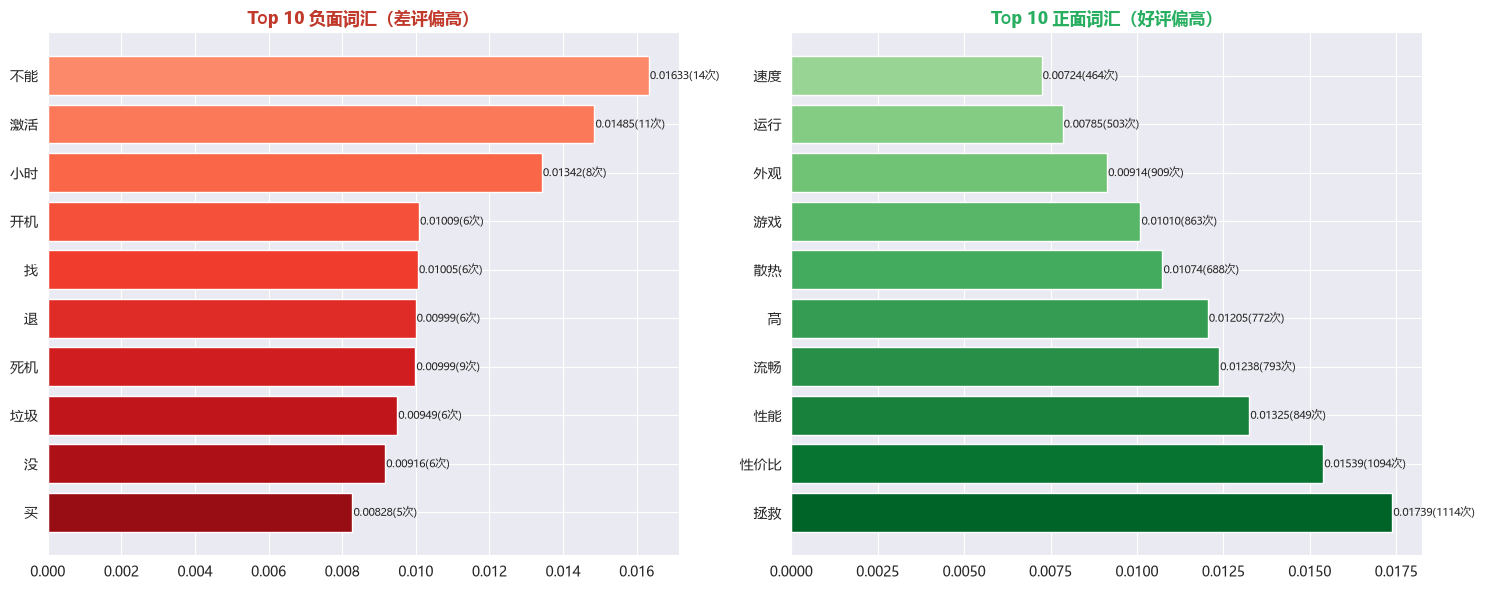

In [70]:
# 正面/负面 Top10 词汇（词频差异法）
# 1. 统计差评/好评词频
def get_word_freq(series):
    all_words = []
    for text in series.dropna():
        all_words.extend(text.split())
    return Counter(all_words)

neg_freq = get_word_freq(df[df['评分'] <= 3]['评论分词_去停用词'])
pos_freq = get_word_freq(df[df['评分'] >= 4]['评论分词_去停用词'])

neg_total = sum(neg_freq.values())
pos_total = sum(pos_freq.values())

# 2. 计算词频差异
records = []
for word in set(neg_freq.keys()) | set(pos_freq.keys()):
    nc, pc = neg_freq.get(word, 0), pos_freq.get(word, 0)
    if nc + pc < 5:
        continue
    records.append([word, nc, pc, nc/neg_total - pc/pos_total])

diff_df = pd.DataFrame(records, columns=['词汇','差评次数','好评次数','差异']).sort_values('差异', ascending=False)

# 3. 输出结果
top_neg = diff_df.head(10).reset_index(drop=True)
top_pos = diff_df.tail(10).reset_index(drop=True)

print("Top 10 负面词汇：")
print(top_neg.to_string(index=False))
print("Top 10 正面词汇：")
print(top_pos.to_string(index=False))

# 4. 可视化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(range(9, -1, -1), top_neg['差异'], color=plt.cm.Reds(np.linspace(0.4,0.9,10)))
axes[0].set_yticks(range(10)); axes[0].set_yticklabels(top_neg['词汇'])
axes[0].set_title('Top 10 负面词汇（差评偏高）', fontweight='bold', color='#c0392b')
for i, v in enumerate(top_neg['差异']):
    axes[0].text(v+0.00003, 9-i, f'{v:.5f}({int(top_neg.iloc[i]["差评次数"])}次)', va='center', fontsize=8)

axes[1].barh(range(9, -1, -1), top_pos['差异'].abs(), color=plt.cm.Greens(np.linspace(0.4,0.9,10)))
axes[1].set_yticks(range(10)); axes[1].set_yticklabels(top_pos['词汇'])
axes[1].set_title('Top 10 正面词汇（好评偏高）', fontweight='bold', color='#27ae60')
for i, v in enumerate(top_pos['差异'].abs()):
    axes[1].text(v+0.00003, 9-i, f'{v:.5f}({int(top_pos.iloc[i]["好评次数"])}次)', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 剔除所有恶意刷评行为后，没有高风险恶评，仅有一些可能为过度情绪化的评论，具有参考价值

# 4 模型构建、训练与验证
## 4.1 数据预处理

In [71]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score)

In [72]:
df['标签'] = df['评分'].apply(lambda x: 1 if x >= 4 else 0)
df['标签'].value_counts()

标签
1    2958
0      42
Name: count, dtype: int64

In [73]:
ohe = OneHotEncoder(sparse_output=False, drop='first')
product_ohe = ohe.fit_transform(df[['产品系列']])
product_ohe_df = pd.DataFrame(product_ohe, columns=ohe.get_feature_names_out(['产品系列']))
print(f"产品系列独热编码: {product_ohe_df.shape[1]}列")

le_memory = LabelEncoder()
df['内存_enc'] = le_memory.fit_transform(df['内存'])
print(f"内存编码: {dict(zip(le_memory.classes_, range(len(le_memory.classes_))))}")

disk_order = sorted(df['硬盘'].unique().tolist(), key=lambda x: {'512G':0, '1T':1}.get(x, 99))
disk_mapping = {disk: idx for idx, disk in enumerate(disk_order)}
df['硬盘_enc'] = df['硬盘'].map(disk_mapping)
print(f"硬盘编码: {disk_mapping}")

le_repurchase = LabelEncoder()
df['复购_enc'] = le_repurchase.fit_transform(df['重复购买情况'])

X_structured = pd.concat([
    product_ohe_df,
    df[['内存_enc', '硬盘_enc', '复购_enc', '评论长度', '情感分数']]
], axis=1)

print(f"结构化特征矩阵: {X_structured.shape}")

产品系列独热编码: 3列
内存编码: {'16G': 0, '24G': 1, '32G': 2}
硬盘编码: {'512G': 0, '1T': 1}
结构化特征矩阵: (3000, 8)


In [74]:
X_structured.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   产品系列_Y7000游戏本  3000 non-null   float64 
 1   产品系列_酷睿版       3000 non-null   float64 
 2   产品系列_锐龙版       3000 non-null   float64 
 3   内存_enc         3000 non-null   int64   
 4   硬盘_enc         3000 non-null   category
 5   复购_enc         3000 non-null   int64   
 6   评论长度           3000 non-null   int64   
 7   情感分数           3000 non-null   float64 
dtypes: category(1), float64(4), int64(3)
memory usage: 167.1 KB


In [75]:
df.to_csv('data_final.csv', index=False, encoding='utf-8-sig')
df.to_excel('data_final.xlsx', index=False)
df_negative.to_csv('data_negative.csv', index=False, encoding='utf-8-sig')
df_negative.to_excel('data_negative.xlsx', index=False)
print("已完成导出")

已完成导出


In [76]:
tfidf_columns = [f'TFIDF_{i}' for i in range(3000)]
X_tfidf = pd.DataFrame(np.array(df['TFIDF向量'].tolist()), columns=tfidf_columns)
X_combined = pd.concat([X_tfidf, X_structured.reset_index(drop=True)], axis=1)
y = df['标签'].values
X_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Columns: 3008 entries, TFIDF_0 to 情感分数
dtypes: category(1), float64(3004), int64(3)
memory usage: 68.8 MB


In [77]:
X_combined.iloc[:5, -10:]

,TFIDF_2998,TFIDF_2999,产品系列_Y7000游戏本,产品系列_酷睿版,产品系列_锐龙版,内存_enc,硬盘_enc,复购_enc,评论长度,情感分数
0,0.0,0.0,0.0,1.0,0.0,2,1,0,128,1.000000
1,0.0,0.0,0.0,1.0,0.0,1,1,2,94,1.000000
2,0.0,0.0,0.0,1.0,0.0,1,1,0,70,1.000000
3,0.0,0.0,0.0,1.0,0.0,1,1,2,64,1.000000
4,0.0,0.0,0.0,1.0,0.0,1,1,0,71,0.999996


In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"训练集: {X_train.shape[0]}条 ({sum(y_train)}好评/{len(y_train)-sum(y_train)}差评)")
print(f"测试集: {X_test.shape[0]}条 ({sum(y_test)}好评/{len(y_test)-sum(y_test)}差评)\n")

训练集: 2400条 (2366好评/34差评)
测试集: 600条 (592好评/8差评)



## 好评与差评数量差距过大，模型可能直接认为所有的均为好评，因此训练模型时要增加差评的权重

## 4.2 模型拟合（分类模型）

## 支持向量机

In [79]:
from sklearn.svm import SVC
svm_model = SVC(
    kernel='linear',           # 线性核，适合高维稀疏数据(TF-IDF)
    class_weight='balanced',   # 自动处理70:1不平衡
    random_state=42,
    probability=True,          # 需要概率输出用于后续阈值调整
    C=10
)
# 注：这里分别尝试了c=1、5、10；probability=0.5，0.4，0.3，上述参数组合为最优解，即c=10，p=0.5

# 训练并计时
start_time = time.time()
svm_model.fit(X_train, y_train)
svm_train_time = time.time() - start_time

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]  # 预测为好评的概率

# 核心指标
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1_macro = f1_score(y_test, y_pred_svm, average='macro')
svm_recall_neg = recall_score(y_test, y_pred_svm, pos_label=0)  # 差评召回率(关键!)
svm_precision_neg = precision_score(y_test, y_pred_svm, pos_label=0)

print(f"SVM核心指标:")
print(f"准确率(Accuracy):{svm_accuracy:.4f}")
print(f"宏平均F1(Macro-F1):{svm_f1_macro:.4f}")
print(f"差评类别召回率(Recall):{svm_recall_neg:.4f}")
print(f"差评类别精确率(Precision):{svm_precision_neg:.4f}")
print(f"训练耗时:{svm_train_time:.2f}秒")

C:\Users\36171\PycharmProjects\Capgemini_Lenovo\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM核心指标:
准确率(Accuracy):0.9883
宏平均F1(Macro-F1):0.7637
差评类别召回率(Recall):0.5000
差评类别精确率(Precision):0.5714
训练耗时:4.50秒


分类报告:
              precision    recall  f1-score   support

       差评(0)     0.5714    0.5000    0.5333         8
       好评(1)     0.9933    0.9949    0.9941       592

    accuracy                         0.9883       600
   macro avg     0.7823    0.7475    0.7637       600
weighted avg     0.9876    0.9883    0.9879       600

混淆矩阵:
              预测差评    预测好评
实际差评           4        4
实际好评           3      589


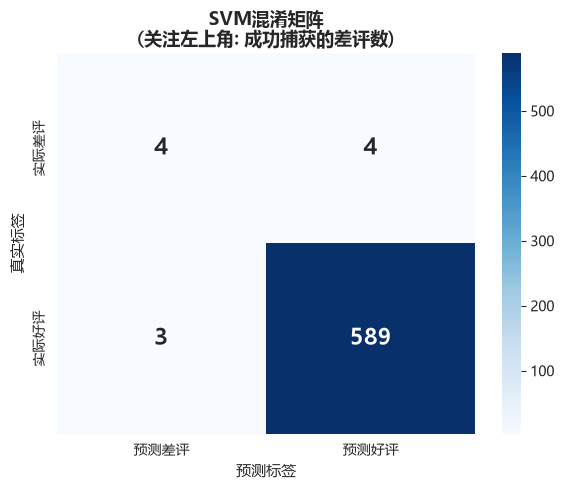

In [80]:
# 详细分类报告
print(f"分类报告:")
print(classification_report(y_test, y_pred_svm, target_names=['差评(0)', '好评(1)'], digits=4))

# 混淆矩阵
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(f"混淆矩阵:")
print(f"              预测差评    预测好评")
print(f"实际差评        {cm_svm[0,0]:4d}     {cm_svm[0,1]:4d}")
print(f"实际好评        {cm_svm[1,0]:4d}     {cm_svm[1,1]:4d}")

# 混淆矩阵可视化
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['预测差评', '预测好评'],
            yticklabels=['实际差评', '实际好评'],
            annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title('SVM混淆矩阵\n(关注左上角: 成功捕获的差评数)', fontsize=13, fontweight='bold')
ax.set_xlabel('预测标签', fontsize=11)
ax.set_ylabel('真实标签', fontsize=11)
plt.tight_layout()
plt.show()

# 保存结果供后续对比用
svm_results = {
    'model': 'SVM',
    'accuracy': svm_accuracy,
    'f1_macro': svm_f1_macro,
    'recall_negative': svm_recall_neg,
    'precision_negative': svm_precision_neg,
    'train_time': svm_train_time,
    'confusion_matrix': cm_svm,
    'y_pred': y_pred_svm,
    'y_prob': y_prob_svm
}

## 支持向量机表现有些偏科，准确率相对比较高，但召回率相对比较低，而舆情分析网站更应该强调召回率，准确率偏低可以通过人工复查的方式来解决

## 正面/负面 Top10 词汇提取（第三章）

Top 10 正面词汇（推高评分）
       词汇        系数
1      质量  2.434192
2      好用  1.556284
3      评价  1.284007
4      内容  1.247162
5       算  1.245192
6    服务态度  1.209079
7   评价 内容  1.149057
8       卡  1.114438
9      两个  1.103206
10     友好  1.098088
Top 10 负面词汇（拉低评分）
       词汇        系数
1    物超所值 -2.476934
2    挺 好看 -2.227386
3      评论 -2.015351
4      价位 -1.917640
5      清晰 -1.899553
6       找 -1.789169
7      键盘 -1.600193
8      不能 -1.586040
9   品牌 值得 -1.341812
10     刚刚 -1.329095


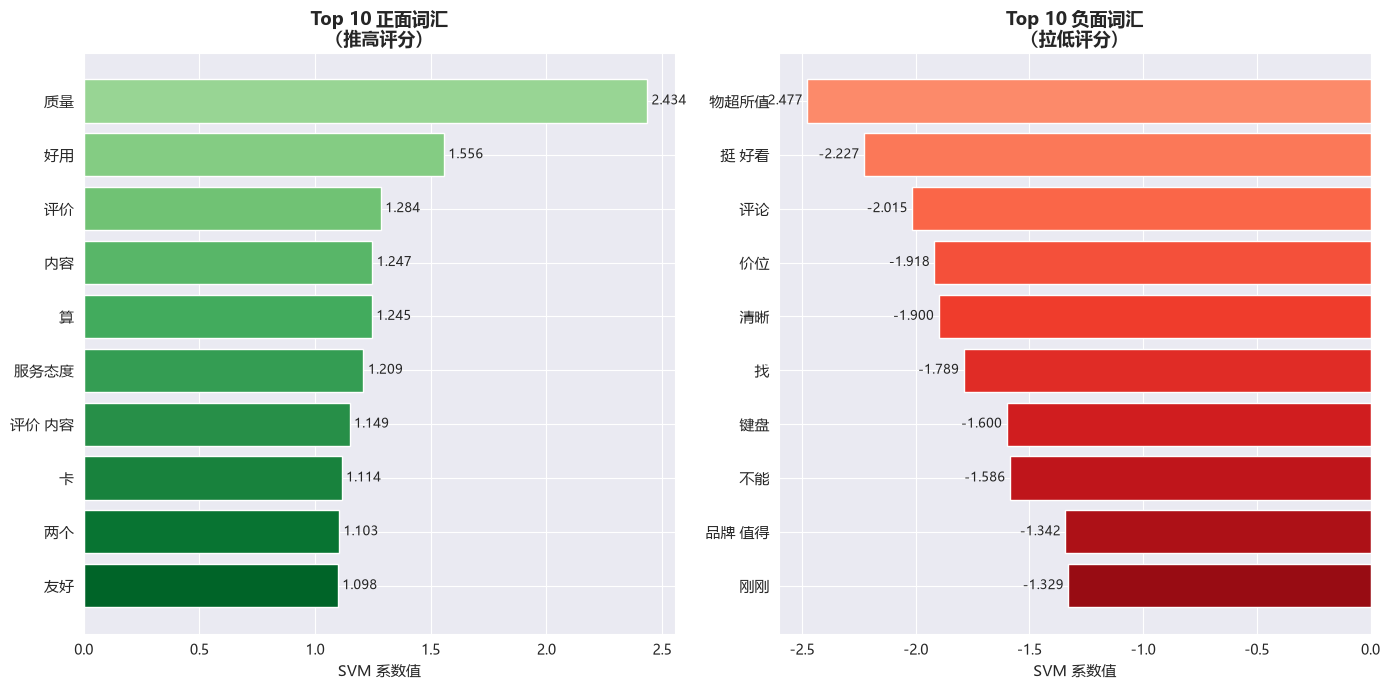

In [81]:
# 1. 获取SVM系数（线性核的coef_直接反映方向）
svm_coef = svm_model.coef_[0]  # 形状 (3008,)

# 2. 分离TF-IDF部分（前3000维是词汇）
tfidf_coef = svm_coef[:3000]
feature_names = tfidf_vectorizer.get_feature_names_out()

# 3. 构建词汇-系数DataFrame
word_coef_df = pd.DataFrame({
    '词汇': feature_names,
    '系数': tfidf_coef
})

# 4. 提取Top10正面词汇（系数最大 → 推高评分 → 好评词）
top10_positive = word_coef_df.nlargest(10, '系数').reset_index(drop=True)
top10_positive.index = top10_positive.index + 1  # 从1开始编号

# 5. 提取Top10负面词汇（系数最小 → 拉低评分 → 差评词）
top10_negative = word_coef_df.nsmallest(10, '系数').reset_index(drop=True)
top10_negative.index = top10_negative.index + 1

print("Top 10 正面词汇（推高评分）")
print(top10_positive[['词汇', '系数']].to_string())
print("Top 10 负面词汇（拉低评分）")
print(top10_negative[['词汇', '系数']].to_string())

# 6. 可视化（左右并列）
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# 左图：正面词汇（绿色渐变）
colors_pos = plt.cm.Greens(np.linspace(0.4, 0.9, 10))[::-1]
axes[0].barh(range(10), top10_positive['系数'].values[::-1], color=colors_pos)
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(top10_positive['词汇'].values[::-1], fontsize=11)
axes[0].set_title('Top 10 正面词汇\n（推高评分）', fontsize=13, fontweight='bold')
axes[0].set_xlabel('SVM 系数值', fontsize=11)

for i, v in enumerate(top10_positive['系数'].values[::-1]):
    axes[0].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

# 右图：负面词汇（红色渐变）
colors_neg = plt.cm.Reds(np.linspace(0.4, 0.9, 10))[::-1]
axes[1].barh(range(10), top10_negative['系数'].values[::-1], color=colors_neg)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top10_negative['词汇'].values[::-1], fontsize=11)
axes[1].set_title('Top 10 负面词汇\n（拉低评分）', fontsize=13, fontweight='bold')
axes[1].set_xlabel('SVM 系数值', fontsize=11)

for i, v in enumerate(top10_negative['系数'].values[::-1]):
    axes[1].text(v - 0.02, i, f'{v:.3f}', va='center', ha='right', fontsize=9)

plt.tight_layout()
plt.show()

## 数据严重失真，支持向量机处理这种数据能力一般

## 随机森林

In [82]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=300,          # 300-500最佳
    class_weight='balanced',   # 处理不平衡
    max_depth=20,              # 20最佳
    min_samples_split=5,       # 内部节点再划分所需最小样本数，5最佳
    min_samples_leaf=5,        # 叶节点最小样本数，5最佳
    random_state=42,
    n_jobs=-1                 # 用所有CPU核心加速
)

# 训练并计时
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time

# 预测
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 核心指标
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1_macro = f1_score(y_test, y_pred_rf, average='macro')
rf_recall_neg = recall_score(y_test, y_pred_rf, pos_label=0)
rf_precision_neg = precision_score(y_test, y_pred_rf, pos_label=0)

print(f"随机森林核心指标:")
print(f"准确率(Accuracy):{rf_accuracy:.4f}")
print(f"宏平均F1(Macro-F1):{rf_f1_macro:.4f}")
print(f"差评类别召回率(Recall):{rf_recall_neg:.4f}")
print(f"差评类别精确率(Precision):{rf_precision_neg:.4f}")
print(f"训练耗时:{rf_train_time:.2f}秒")

随机森林核心指标:
准确率(Accuracy):0.9517
宏平均F1(Macro-F1):0.6503
差评类别召回率(Recall):0.8750
差评类别精确率(Precision):0.2000
训练耗时:0.34秒


分类报告:
              precision    recall  f1-score   support

       差评(0)     0.2000    0.8750    0.3256         8
       好评(1)     0.9982    0.9527    0.9749       592

    accuracy                         0.9517       600
   macro avg     0.5991    0.9139    0.6503       600
weighted avg     0.9876    0.9517    0.9663       600

混淆矩阵:
              预测差评   预测好评
实际差评           7        1
实际好评          28      564


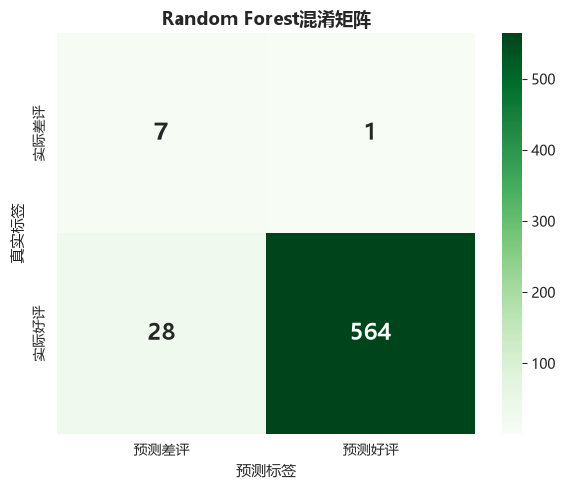

In [83]:
# 详细分类报告
print(f"分类报告:")
print(classification_report(y_test, y_pred_rf, target_names=['差评(0)', '好评(1)'], digits=4))

# 混淆矩阵
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"混淆矩阵:")
print(f"              预测差评   预测好评")
print(f"实际差评        {cm_rf[0,0]:4d}     {cm_rf[0,1]:4d}")
print(f"实际好评        {cm_rf[1,0]:4d}     {cm_rf[1,1]:4d}")

# 混淆矩阵可视化
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['预测差评', '预测好评'],
            yticklabels=['实际差评', '实际好评'],
            annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title('Random Forest混淆矩阵', fontsize=13, fontweight='bold')
ax.set_xlabel('预测标签', fontsize=11)
ax.set_ylabel('真实标签', fontsize=11)
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 保存结果
rf_results = {
    'model': 'RandomForest',
    'accuracy': rf_accuracy,
    'f1_macro': rf_f1_macro,
    'recall_negative': rf_recall_neg,
    'precision_negative': rf_precision_neg,
    'train_time': rf_train_time,
    'confusion_matrix': cm_rf,
    'y_pred': y_pred_rf,
    'y_prob': y_prob_rf,
    'model_object': rf_model  # 保存模型对象，后面提取特征重要性用
}

## 随机森林表现优于支持向量机，召回率很高的同时误伤的好评数远小于支持向量机（几乎全部误伤），但准确率依旧不高，这是树模型面对稀疏数据的通病

## 随机森林特征重要性：Top10 词汇（报告第三章，可用xgboost部分代替）

 1. 速度        →  重要性: 0.0400
 2. 外观        →  重要性: 0.0310
 3. 运行        →  重要性: 0.0279
 4. 流畅        →  重要性: 0.0275
 5. 散热        →  重要性: 0.0255
 6. 高         →  重要性: 0.0226
 7. 游戏        →  重要性: 0.0219
 8. 性价比       →  重要性: 0.0167
 9. 没         →  重要性: 0.0164
10. 性能        →  重要性: 0.0142


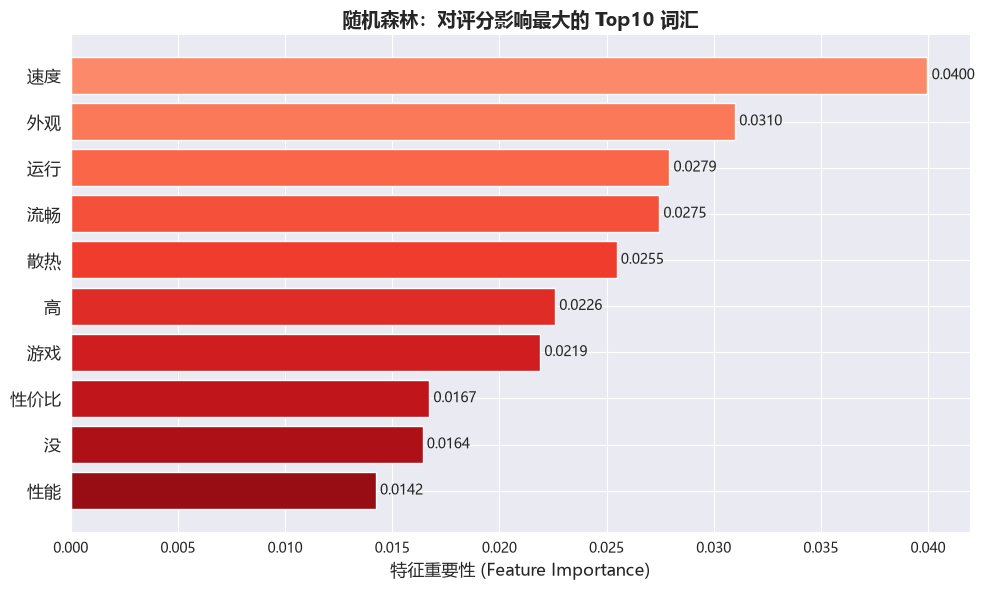

In [84]:
# 1. 获取特征重要性
feature_importance = rf_model.feature_importances_

# 2. 分离TF-IDF词汇特征（前3000维）和结构化特征（后8维）
tfidf_importance = feature_importance[:3000]  # TF-IDF部分

# 3. 获取词汇表
feature_names = tfidf_vectorizer.get_feature_names_out()

# 4. 取Top10词汇的索引
top10_indices = np.argsort(tfidf_importance)[::-1][:10]
top10_words = feature_names[top10_indices]
top10_scores = tfidf_importance[top10_indices]

# 5. 打印结果
for i, (word, score) in enumerate(zip(top10_words, top10_scores), 1):
    print(f"{i:2d}. {word:8s}  →  重要性: {score:.4f}")

# 6. 可视化（水平条形图，从高到低排列）
plt.figure(figsize=(10, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, 10))[::-1]  # 红色渐变

bars = plt.barh(range(10), top10_scores[::-1], color=colors)
plt.yticks(range(10), top10_words[::-1], fontsize=12)
plt.xlabel('特征重要性 (Feature Importance)', fontsize=12)
plt.title('随机森林：对评分影响最大的 Top10 词汇', fontsize=14, fontweight='bold')

# 在条形末端标注数值
for bar, score in zip(bars, top10_scores[::-1]):
    plt.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## XGBoost（代替GBDT）

C:\Users\36171\PycharmProjects\Capgemini_Lenovo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



XGBoost 结果（threshold=0.5）
准确率:     0.9367
宏F1:       0.6035
差评召回率: 0.7500
差评精确率: 0.1429
耗时:       1.76秒

阈值扫描:
  0.5 → 召回=0.750, 精确=0.143
  0.4 → 召回=0.750, 精确=0.143
  0.3 → 召回=0.750, 精确=0.146
  0.2 → 召回=0.500, 精确=0.167


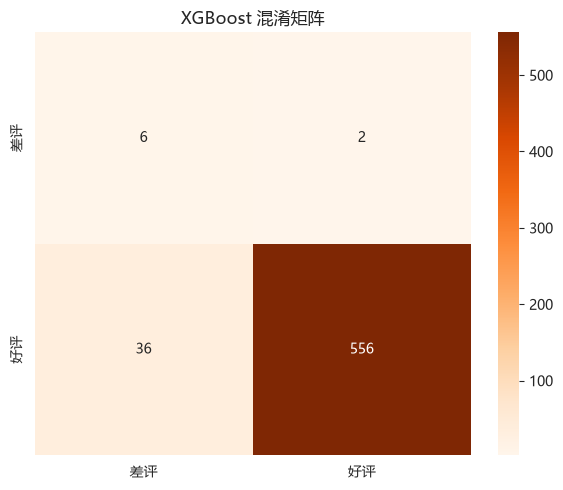

In [85]:
import xgboost as xgb
import shap
pos_count = (y_train == 1).sum()
neg_count = (y_train == 0).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200, 
    max_depth=5, 
    learning_rate=0.1,
    scale_pos_weight=(neg_count+10)/pos_count,        # 由于差评样本权重太高，导致模型对正则参数过度敏感，故为方便调参，稍微上调权重
    subsample=0.8, 
    colsample_bytree=0.8,
    min_child_weight=5, 
    gamma=0.15,
    reg_alpha=0.3, 
    reg_lambda=1.2,
    random_state=42, 
    eval_metric='logloss', 
    n_jobs=-1
)

start = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f"\n{'='*55}")
print("XGBoost 结果（threshold=0.5）")
print(f"{'='*55}")
print(f"准确率:     {accuracy_score(y_test,y_pred):.4f}")
print(f"宏F1:       {f1_score(y_test,y_pred,average='macro'):.4f}")
print(f"差评召回率: {recall_score(y_test,y_pred,pos_label=0):.4f}")
print(f"差评精确率: {precision_score(y_test,y_pred,pos_label=0):.4f}")
print(f"耗时:       {xgb_time:.2f}秒")

# 阈值扫描
print(f"\n阈值扫描:")
for t in [0.5, 0.4, 0.3, 0.2]:
    yt = (y_prob >= t).astype(int)
    print(f"  {t:.1f} → 召回={recall_score(y_test,yt,pos_label=0):.3f}, "
          f"精确={precision_score(y_test,yt,pos_label=0):.3f}")

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['差评','好评'], yticklabels=['差评','好评'])
plt.title('XGBoost 混淆矩阵')
plt.tight_layout()
plt.show()

# 保存结果供后续对比表使用
xgb_results = {
    'model': 'XGBoost',
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_macro': f1_score(y_test, y_pred, average='macro'),
    'recall_negative': recall_score(y_test, y_pred, pos_label=0),
    'precision_negative': precision_score(y_test, y_pred, pos_label=0),
    'train_time': xgb_time
}

## XGBoost表现也一般，考虑是否是高分差评样本被成功识别到了，故提取RF和XGBoost的"误伤"样本

In [86]:
# 1. RF 假阳性
rf_fp_mask = (y_pred_rf == 0) & (y_test == 1)
rf_fp_indices = np.where(rf_fp_mask)[0]
test_indices = X_test.index

rf_fp_samples = pd.DataFrame({
    '原索引': test_indices[rf_fp_indices],
    '评分': df.loc[test_indices[rf_fp_indices], '评分'].values,
    '情感分数': df.loc[test_indices[rf_fp_indices], '情感分数'].values,
    'RF概率(差评)': y_prob_rf[rf_fp_indices],
    '评论内容': df.loc[test_indices[rf_fp_indices], '评论内容'].values,
    '产品系列': df.loc[test_indices[rf_fp_indices], '产品系列'].values,
})

print(f"RF 误伤样本：{len(rf_fp_samples)} 条")
for i, row in rf_fp_samples.iterrows():
    print(f"\n--- #{i+1} | {row['评分']}分 | 情感:{row['情感分数']:.2f} | RF概率:{row['RF概率(差评)']:.3f}")
    print(f"[{row['产品系列']}] {str(row['评论内容'])[:120]}\n")

RF 误伤样本：28 条

--- #1 | 5分 | 情感:0.25 | RF概率:0.397
[Y7000游戏本] 是正品，系统没激活过，电池只使用过一次 ，应该是出厂检测时的。电脑运行很快。


--- #2 | 5分 | 情感:0.95 | RF概率:0.455
[锐龙版] 很好看起来也很好看


--- #3 | 5分 | 情感:1.00 | RF概率:0.382
[酷睿版] 激活完毕，很好用，人脸识别，人走熄屏还挺人性化，音质也可以，很有质感。联想一直值得信赖。


--- #4 | 5分 | 情感:1.00 | RF概率:0.473
[酷睿版] 工作需要临时要买手提电脑，首选京东，物流快品质有保证，美中不足的地方就是自己另外买鼠标和电脑包，但总体来说本次购物还是挺满意的。


--- #5 | 5分 | 情感:0.12 | RF概率:0.188
[酷睿版] 快递员非常好，到货准时，服务热情


--- #6 | 5分 | 情感:0.06 | RF概率:0.468
[Y7000游戏本] 收到后新手验机了一下，是运输模式，首次开机一本正经的看了一下，也不懂啥，但是看的懂的信息都对的上，蛮好，就看后续用起来怎么样了。


--- #7 | 5分 | 情感:0.48 | RF概率:0.355
[Y7000游戏本] 我没有用不知道怎么样，给孩子买的说可以


--- #8 | 5分 | 情感:0.20 | RF概率:0.406
[Y7000游戏本] 已经看了好久了，昨天才拿下的，5060非常牛逼啊2k随便玩


--- #9 | 5分 | 情感:0.03 | RF概率:0.140
[酷睿版] 降价太快了才买几天呀


--- #10 | 5分 | 情感:0.14 | RF概率:0.484
[Y7000游戏本] 货已收到速度2天就到家了


--- #11 | 5分 | 情感:0.89 | RF概率:0.435
[R7000游戏本] 非常不错，自营正版，无使用前开封和激活，支持


--- #12 | 5分 | 情感:0.42 | RF概率:0.476
[Y7000游戏本] 收到电脑的第一天就全面验机完了，没有问题，就是没有抽到“一等奖”。另外，买联想的一个很重要的原因就是售后很不错，大家买了电脑后可以根据需要考虑要不要买延保，如果确定要用两年以上，购买延保会更合

## 2、4、6、7、8、9、11、12确实有点问题，随机森林的判断是正确的，存在高分低评现象

In [87]:
# 2. XGBoost 假阳性
xgb_fp_mask = (y_pred == 0) & (y_test == 1)
xgb_fp_indices = np.where(xgb_fp_mask)[0]

xgb_fp_samples = pd.DataFrame({
    '原索引': test_indices[xgb_fp_indices],
    '评分': df.loc[test_indices[xgb_fp_indices], '评分'].values,
    '情感分数': df.loc[test_indices[xgb_fp_indices], '情感分数'].values,
    'XGB概率(差评)': y_prob[xgb_fp_indices], 
    '评论内容': df.loc[test_indices[xgb_fp_indices], '评论内容'].values,
    '产品系列': df.loc[test_indices[xgb_fp_indices], '产品系列'].values,
})

print(f"XGBoost 误伤样本：{len(xgb_fp_samples)} 条")
for i, row in xgb_fp_samples.iterrows():
    print(f"\n--- #{i+1} | {row['评分']}分 | 情感:{row['情感分数']:.2f} | XGB概率:{row['XGB概率(差评)']:.3f}")
    print(f"[{row['产品系列']}] {str(row['评论内容'])}\n")

XGBoost 误伤样本：36 条

--- #1 | 5分 | 情感:0.25 | XGB概率:0.204
[Y7000游戏本] 是正品，系统没激活过，电池只使用过一次 ，应该是出厂检测时的。电脑运行很快。


--- #2 | 5分 | 情感:0.12 | XGB概率:0.136
[酷睿版] 快递员非常好，到货准时，服务热情


--- #3 | 5分 | 情感:0.10 | XGB概率:0.193
[R7000游戏本] 此用户未及时填写评价内容


--- #4 | 5分 | 情感:0.10 | XGB概率:0.193
[R7000游戏本] 此用户未及时填写评价内容


--- #5 | 5分 | 情感:0.06 | XGB概率:0.283
[Y7000游戏本] 收到后新手验机了一下，是运输模式，首次开机一本正经的看了一下，也不懂啥，但是看的懂的信息都对的上，蛮好，就看后续用起来怎么样了。


--- #6 | 5分 | 情感:0.48 | XGB概率:0.271
[Y7000游戏本] 我没有用不知道怎么样，给孩子买的说可以


--- #7 | 5分 | 情感:0.10 | XGB概率:0.193
[Y7000游戏本] 此用户未及时填写评价内容


--- #8 | 5分 | 情感:0.10 | XGB概率:0.193
[R7000游戏本] 此用户未填写评价内容


--- #9 | 5分 | 情感:0.20 | XGB概率:0.193
[Y7000游戏本] 已经看了好久了，昨天才拿下的，5060非常牛逼啊2k随便玩


--- #10 | 5分 | 情感:0.10 | XGB概率:0.193
[R7000游戏本] 此用户未及时填写评价内容


--- #11 | 5分 | 情感:0.03 | XGB概率:0.136
[酷睿版] 降价太快了才买几天呀


--- #12 | 5分 | 情感:0.21 | XGB概率:0.207
[酷睿版] 一打开盖子，自动开机，我以为是漏关电脑了，结果它掀盖即开机，开机很快。运行速度：超级快，连开机键都不用按，一掀盖就开机


--- #13 | 5分 | 情感:0.14 | XGB概率:0.193
[Y7000游戏本] 货已收到速度2天就到家了


--- #14 | 5分 | 情感:0.42 | XGB概率:0.381


In [88]:
# 3. 两个模型交集
common_fp = set(rf_fp_indices) & set(xgb_fp_indices)
if common_fp:
    print(f"两个模型同时误判：{len(common_fp)} 条")
    for idx in sorted(common_fp)[:10]:
        oi = test_indices[idx]
        print(f"行{oi} | {df.loc[oi,'评分']}分 | 情感:{df.loc[oi,'情感分数']:.2f} | "
              f"RF:{y_prob_rf[idx]:.3f} XGB:{y_prob[idx]:.3f}")
        print(f"{str(df.loc[oi,'评论内容'])[:150]}")

两个模型同时误判：17 条
行1174 | 5分 | 情感:0.25 | RF:0.397 XGB:0.204
是正品，系统没激活过，电池只使用过一次 ，应该是出厂检测时的。电脑运行很快。
行1906 | 5分 | 情感:0.12 | RF:0.188 XGB:0.136
快递员非常好，到货准时，服务热情
行1540 | 5分 | 情感:0.06 | RF:0.468 XGB:0.283
收到后新手验机了一下，是运输模式，首次开机一本正经的看了一下，也不懂啥，但是看的懂的信息都对的上，蛮好，就看后续用起来怎么样了。
行2180 | 5分 | 情感:0.48 | RF:0.355 XGB:0.271
我没有用不知道怎么样，给孩子买的说可以
行892 | 5分 | 情感:0.20 | RF:0.406 XGB:0.193
已经看了好久了，昨天才拿下的，5060非常牛逼啊2k随便玩
行1962 | 5分 | 情感:0.03 | RF:0.140 XGB:0.136
降价太快了才买几天呀
行1055 | 5分 | 情感:0.14 | RF:0.484 XGB:0.193
货已收到速度2天就到家了
行2975 | 5分 | 情感:0.42 | RF:0.476 XGB:0.381
收到电脑的第一天就全面验机完了，没有问题，就是没有抽到“一等奖”。另外，买联想的一个很重要的原因就是售后很不错，大家买了电脑后可以根据需要考虑要不要买延保，如果确定要用两年以上，购买延保会更合适。
行1697 | 5分 | 情感:0.28 | RF:0.439 XGB:0.193
下午下单第二天早上就到了。噪音很小，屏幕素质不错，是京东方。
行1083 | 5分 | 情感:0.28 | RF:0.401 XGB:0.193
很好用 没有领到国补，但这个价也还能接受 昨晚验机都没有问题 可以冲


In [89]:
# 识别假阴性：预测=1(好评) 且 实际=0(差评)
fn_mask = (y_pred == 1) & (y_test == 0)

# 获取原始df中对应的测试集索引
test_indices = X_test.index if hasattr(X_test, 'index') else range(len(y_test))

# 构建结果DataFrame
fn_results = pd.DataFrame({
    '原始评论': df.loc[test_indices[fn_mask], '评论内容'].values if hasattr(df, 'loc') else '需确认列名',
    '实际标签': y_test[fn_mask],
    '预测标签': y_pred[fn_mask],
    '预测好评概率': y_prob[fn_mask],
    '评分': df.loc[test_indices[fn_mask], '评分'].values if '评分' in df.columns else None,
})

print(f"假阴性数量: {fn_mask.sum()} 条")
print(f"占测试集差评比例: {fn_mask.sum() / (y_test == 0).sum() * 100:.1f}%\n")

pd.set_option('display.max_colwidth', 100)
display(fn_results)

假阴性数量: 2 条
占测试集差评比例: 25.0%



,原始评论,实际标签,预测标签,预测好评概率,评分
0,目前总体不错，适合选择,0,1,0.701990,3
1,性能没的说，玩游戏很流畅，物流也很快，但我拿到货不到10天，声音就要问题了，偶尔有电音,0,1,0.793208,2


## 相比随机森林，XGBoost找出了更全的疑似负面评价，包括所有未填写评价的，有褒有贬的，高分低评的，大部分都可以一定程度上反映问题，只有小部分是误伤，故综合考量选择XGBoost作为最终模型

## 尝试把训练集去除标签再用xgboost拟合一次，看看能不能识别出新的负面评论

In [90]:
y_pred_all = xgb_model.predict(X_combined)
y_prob_all = xgb_model.predict_proba(X_combined)[:, 1]

df['XGB预测'] = y_pred_all          # 1=预测好评, 0=预测差评
df['XGB概率_差评'] = 1 - y_prob_all # 模型认为"是差评"的概率

print(f"全量预测结果:")
print(f"总样本数: {len(df)}")
print(f"原始差评数(评分≤3): {(df['标签']==0).sum()}")
print(f"模型预测差评数: {(df['XGB预测']==0).sum()}\n")

mask_original_neg = (df['标签'] == 0)
mask_xgb_neg = (df['XGB预测'] == 0)
mask_problem = mask_original_neg | mask_xgb_neg  # 取原始数据和XGB的并集

df_problem = df[mask_problem].copy()

print(f"问题数据集统计:")
print(f"原始差评: {mask_original_neg.sum()} 条")
print(f"模型新增识别: {mask_xgb_neg.sum() - (mask_original_neg & mask_xgb_neg).sum()} 条")
print(f"问题数据集总计: {len(df_problem)} 条\n")

# 分类标记
def classify_problem(row):
    if row['标签'] == 0 and row['XGB预测'] == 0:
        return '真·差评'
    elif row['标签'] == 1 and row['XGB预测'] == 0:
        return '高分低评'
    else:
        return '其他'

df_problem['问题类型'] = df_problem.apply(classify_problem, axis=1)

print(f"真实差评(模型也认): {(df_problem['问题类型']=='真·差评').sum()}条")
print(f"高分低评(高分但内容负面): {(df_problem['问题类型']=='高分低评').sum()}条")
print(f"其他: {(df_problem['问题类型']=='其他').sum()}条\n")

df_problem.to_excel('问题数据集_XGBoost全量预测.xlsx', index=False)
print(f"已导出: 问题数据集_XGBoost全量预测.xlsx")

全量预测结果:
总样本数: 3000
原始差评数(评分≤3): 42
模型预测差评数: 210

问题数据集统计:
原始差评: 42 条
模型新增识别: 174 条
问题数据集总计: 216 条

真实差评(模型也认): 36条
高分低评(高分但内容负面): 174条
其他: 6条

已导出: 问题数据集_XGBoost全量预测.xlsx


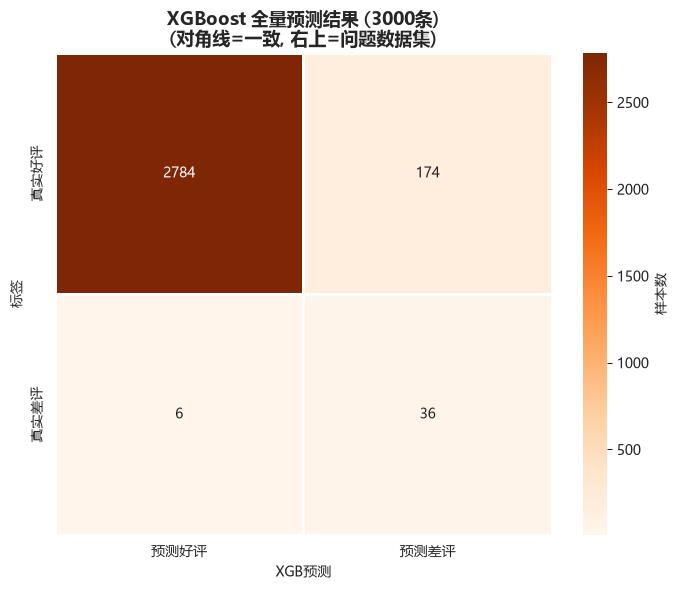

In [91]:
# 全量数据混淆矩阵
cm_full = pd.crosstab(
    df['标签'].map({1: '真实好评', 0: '真实差评'}),
    df['XGB预测'].map({1: '预测好评', 0: '预测差评'}),
    margins=True, margins_name='合计'
)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_full.iloc[:-1, :-1], annot=True, fmt='d', cmap='Oranges',
            linewidths=1, linecolor='white',
            cbar_kws={'label': '样本数'})
plt.title('XGBoost 全量预测结果 (3000条)\n(对角线=一致, 右上=问题数据集)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# # 问题数据集构成热力图
# cross_type = pd.crosstab(
#     df_problem['标签'].map({1: '原始好评', 0: '原始差评'}),
#     df_problem['问题类型'],
#     margins=True, margins_name='合计'
# )

# plt.figure(figsize=(8, 5))
# sns.heatmap(cross_type.iloc[:-1, :-1], annot=True, fmt='d', cmap='Reds',
#             linewidths=1, linecolor='white',
#             cbar_kws={'label': '样本数'})
# plt.title('问题数据集构成分析\n(原始评分 × 问题类型)', 
#           fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.show()

# # 按评分分布的预测结果 
# score_pred = pd.crosstab(
#     df['评分'],
#     df['XGB预测'].map({1: '预测好评', 0: '预测差评'}),
#     margins=True, margins_name='合计'
# )

# plt.figure(figsize=(9, 6))
# sns.heatmap(score_pred.iloc[:-1, :-1], annot=True, fmt='d', cmap='YlOrRd',
#             linewidths=1, linecolor='white',
#             cbar_kws={'label': '样本数'})
# plt.title('各评分等级 × XGBoost预测结果\n(关注4/5星中"预测差评"的列 → 反话候选)', 
#           fontsize=13, fontweight='bold')
# plt.xlabel('XGBoost 预测结果', fontsize=11)
# plt.ylabel('实际评分', fontsize=11)
# plt.tight_layout()
# plt.show()

In [92]:
# 高频词统计
all_words = []
for text in df_problem['评论分词_去停用词'].dropna():
    all_words.extend(text.split())

word_freq = Counter(all_words)
top20_words = word_freq.most_common(20)

print(f"问题数据集 Top20 高频词:")
print(f"{'排名':>4} {'词汇':<8} {'出现次数':>8} {'占比':>8}")
print("-" * 36)
total_words = len(all_words)
for i, (word, count) in enumerate(top20_words, 1):
    pct = count / total_words * 100
    print(f"{i:>4} {word:<8} {count:>8} {pct:>7.2f}%")

# 按问题类型分别分析
for ptype in ['真·差评', '高分低评']:
    subset = df_problem[df_problem['问题类型'] == ptype]
    type_words = []
    for text in subset['评论分词_去停用词'].dropna():
        type_words.extend(text.split())
    
    if type_words:
        type_freq = Counter(type_words)
        top10 = type_freq.most_common(10)
        
        print(f"\n【{ptype}】共{len(subset)}条, 词数{len(type_words)}:")
        for j, (w, c) in enumerate(top10, 1):
            print(f"  {j:2d}. {w:<6} ({c}次)")

# "高分低评"样本展示
sarcasm_samples = df_problem[df_problem['问题类型'] == '高分低评'].sort_values(
    'XGB概率_差评', ascending=False)

for i, (idx, row) in enumerate(sarcasm_samples.head(15).iterrows(), 1):
    print(f"\n--- #{i} | {row['评分']}星 | 情感:{row['情感分数']:.2f} | "
          f"差评概率:{row['XGB概率_差评']:.3f}")
    print(f"[{row['产品系列']}] {str(row['评论内容'])[:150]}")

问题数据集 Top20 高频词:
  排名 词汇           出现次数       占比
------------------------------------
   1 评价             47    1.46%
   2 用户             44    1.37%
   3 内容             42    1.31%
   4 买              42    1.31%
   5 没              38    1.18%
   6 收到             37    1.15%
   7 屏幕             26    0.81%
   8 未              24    0.75%
   9 国补             23    0.72%
  10 填写             22    0.68%
  11 开机             21    0.65%
  12 未填写            19    0.59%
  13 运行             18    0.56%
  14 货              18    0.56%
  15 体验             18    0.56%
  16 激活             16    0.50%
  17 接口             16    0.50%
  18 太              14    0.44%
  19 小时             14    0.44%
  20 验机             14    0.44%

【真·差评】共36条, 词数558:
   1. 买      (14次)
   2. 没      (10次)
   3. 开机     (9次)
   4. 垃圾     (8次)
   5. 激活     (6次)
   6. 死机     (6次)
   7. 找      (6次)
   8. 退      (6次)
   9. 小时     (6次)
  10. 国补     (5次)

【高分低评】共174条, 词数2620:
   1. 评价     (47次)
   2. 用户     (43次)
   3. 内容    

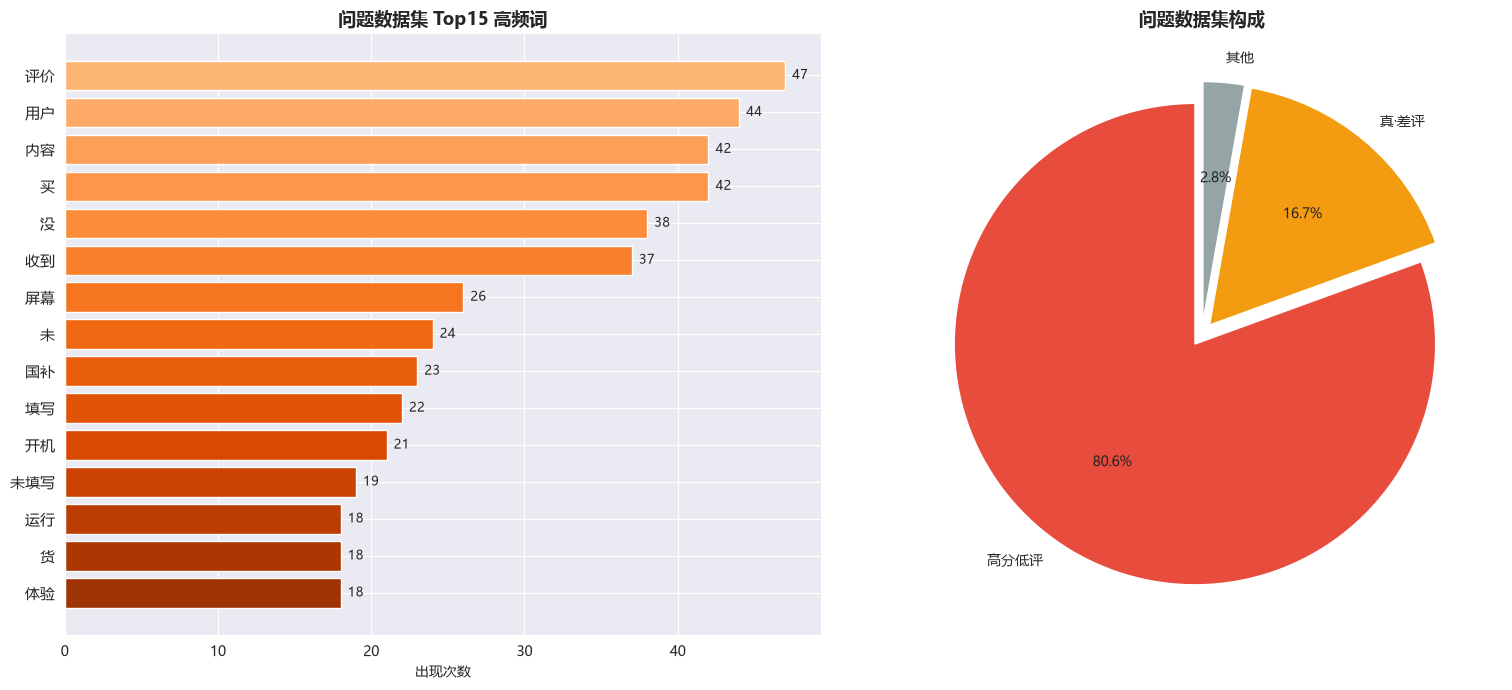

In [93]:
# 问题数据集高频词Top15
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左图：整体高频词
words_top15 = [w for w, _ in top20_words[:15]]
counts_top15 = [c for _, c in top20_words[:15]]
colors_left = plt.cm.Oranges(np.linspace(0.35, 0.9, 15))[::-1]

axes[0].barh(range(15), counts_top15[::-1], color=colors_left)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(words_top15[::-1], fontsize=11)
axes[0].set_title('问题数据集 Top15 高频词', fontweight='bold', fontsize=13)
axes[0].set_xlabel('出现次数')
for i, v in enumerate(counts_top15[::-1]):
    axes[0].text(v + max(counts_top15)*0.01, i, str(v), va='center', fontsize=9)

# 右图：两类样本数量对比
type_counts = df_problem['问题类型'].value_counts()
colors_right = ['#e74c3c', '#f39c12', '#95a5a6']
wedges, texts, autotexts = axes[1].pie(
    type_counts.values, labels=type_counts.index,
    autopct='%1.1f%%', colors=colors_right[:len(type_counts)],
    explode=[0.05]*len(type_counts), startangle=90
)
axes[1].set_title('问题数据集构成', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

## 综合来看，模型对欲扬先抑型评论和转折对比型评论的识别能力一般，一旦有抑的成分出现，便会识别为差评，这种宁错杀不放过的逻辑可以完整的识别出所有的问题，且不会产生纰漏，即使是欲扬先抑，抑的部分也是可能存在的问题，具有一定的参考价值

## 三种模型综合对比

In [94]:
comparison = pd.DataFrame({
    '模型': ['SVM', 'Random Forest', 'XGBoost'],
    '准确率': [svm_accuracy, rf_accuracy, xgb_results['accuracy']],
    '宏F1': [svm_f1_macro, rf_f1_macro, xgb_results['f1_macro']],
    '差评召回率': [svm_recall_neg, rf_recall_neg, xgb_results['recall_negative']],
    '差评精确率': [svm_precision_neg, rf_precision_neg, xgb_results['precision_negative']],
    '训练耗时(秒)': [svm_train_time, rf_train_time, xgb_results['train_time']]
}).round(4)
comparison

,模型,准确率,宏F1,差评召回率,差评精确率,训练耗时(秒)
0,SVM,0.9883,0.7637,0.500,0.5714,4.4954
1,Random Forest,0.9517,0.6503,0.875,0.2000,0.3411
2,XGBoost,0.9367,0.6035,0.750,0.1429,1.7601


## 虽然随机森林在数据上的表现优于XGBoost，但由于数据本身存在的一些隐形问题上，XGBoost的识别能力要强于随机森林，故选择XGBoost作为最终模型

SHAP 分析：XGBoost 模型关键驱动因素

[1/5] 准备数据...
   测试集原始形状: (600, 3008)
   采样后形状: (200, 3008)

[2/5] 计算 SHAP 值...
   SHAP矩阵形状: (200, 3008)

[3/5] 提取特征名称...
   TF-IDF特征: 3000, 结构化特征: 8

[4/5] 绘制 Summary Plot...


findfont: Failed to find font weight bold, now using 400.


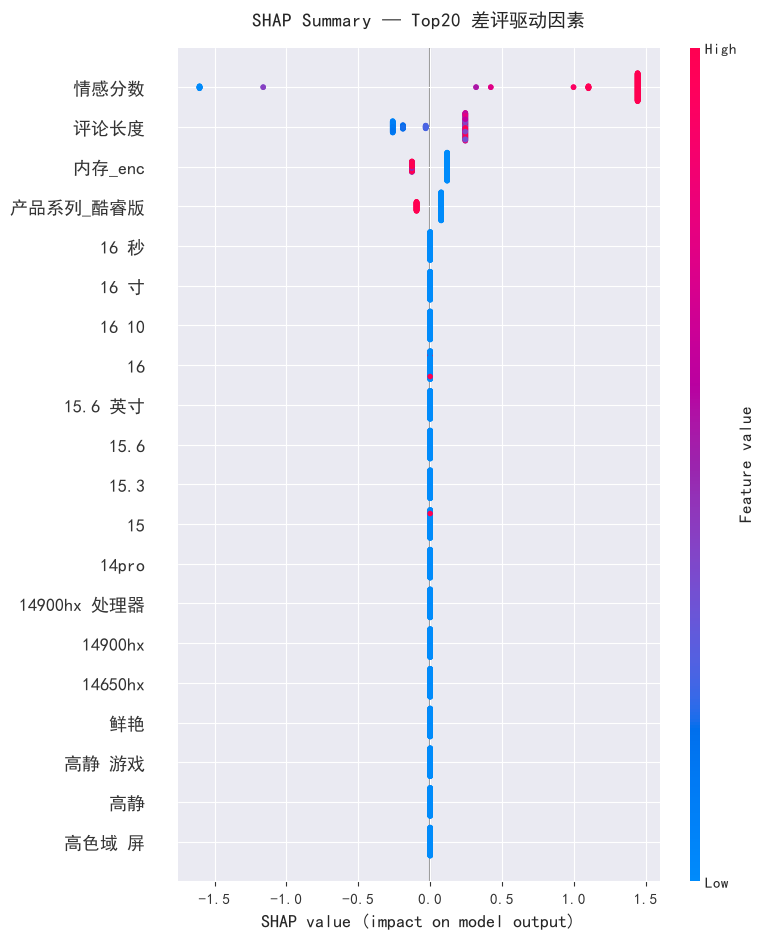

In [95]:
# ========== SHAP 可解释性分析（修复版）==========

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 中文字体设置 ──
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("SHAP 分析：XGBoost 模型关键驱动因素")
print("=" * 60)

# ── 1. 统一转为 dense 数组，再采样 ──
print("\n[1/5] 准备数据...")

# 统一转成 dense numpy array
if hasattr(X_test, 'toarray'):
    X_test_dense = X_test.toarray()
else:
    X_test_dense = np.array(X_test)

print(f"   测试集原始形状: {X_test_dense.shape}")

# 采样（避免内存溢出）
sample_size = min(200, X_test_dense.shape[0])
X_sample = X_test_dense[:sample_size].copy()  # 显式 copy，确保独立
y_sample = y_test.values[:sample_size] if hasattr(y_test, 'values') else y_test[:sample_size]

print(f"   采样后形状: {X_sample.shape}")

# ── 2. 构建 SHAP Explainer ──
print("\n[2/5] 计算 SHAP 值...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

# 处理二分类输出格式
if isinstance(shap_values, list):
    shap_vals = shap_values[0]  # 取 class=0 (差评) 的SHAP值
else:
    shap_vals = shap_values

print(f"   SHAP矩阵形状: {shap_vals.shape}")
assert shap_vals.shape == X_sample.shape, f"形状不匹配! SHAP:{shap_vals.shape} vs Data:{X_sample.shape}"

# ── 3. 获取特征名称 ──
print("\n[3/5] 提取特征名称...")
tfidf_names = tfidf_vectorizer.get_feature_names_out()
struct_names = list(X_structured.columns)
all_names = np.concatenate([tfidf_names, struct_names])
print(f"   TF-IDF特征: {len(tfidf_names)}, 结构化特征: {len(struct_names)}")

# ── 4. Summary Plot ──
print("\n[4/5] 绘制 Summary Plot...")
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_vals,
    X_sample,
    feature_names=all_names,
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Top20 差评驱动因素', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.



Top15 差评驱动关键词
 排名   关键词 |SHAP|均值   影响方向
  1 齐全 不用   0.0000 降低差评 ↓
  2    齐全   0.0000 降低差评 ↓
  3    鼠标   0.0000 降低差评 ↓
  4 黑色 机身   0.0000 降低差评 ↓
  5    黑色   0.0000 降低差评 ↓
  6    黑屏   0.0000 降低差评 ↓
  7  黑 神话   0.0000 降低差评 ↓
  8     黑   0.0000 降低差评 ↓
  9    鲜艳   0.0000 降低差评 ↓
 10 高静 游戏   0.0000 降低差评 ↓
 11    高静   0.0000 降低差评 ↓
 12 高色域 屏   0.0000 降低差评 ↓
 13   高色域   0.0000 降低差评 ↓
 14    高级   0.0000 降低差评 ↓
 15 高端 大气   0.0000 降低差评 ↓

绘制 Dependence Plot...


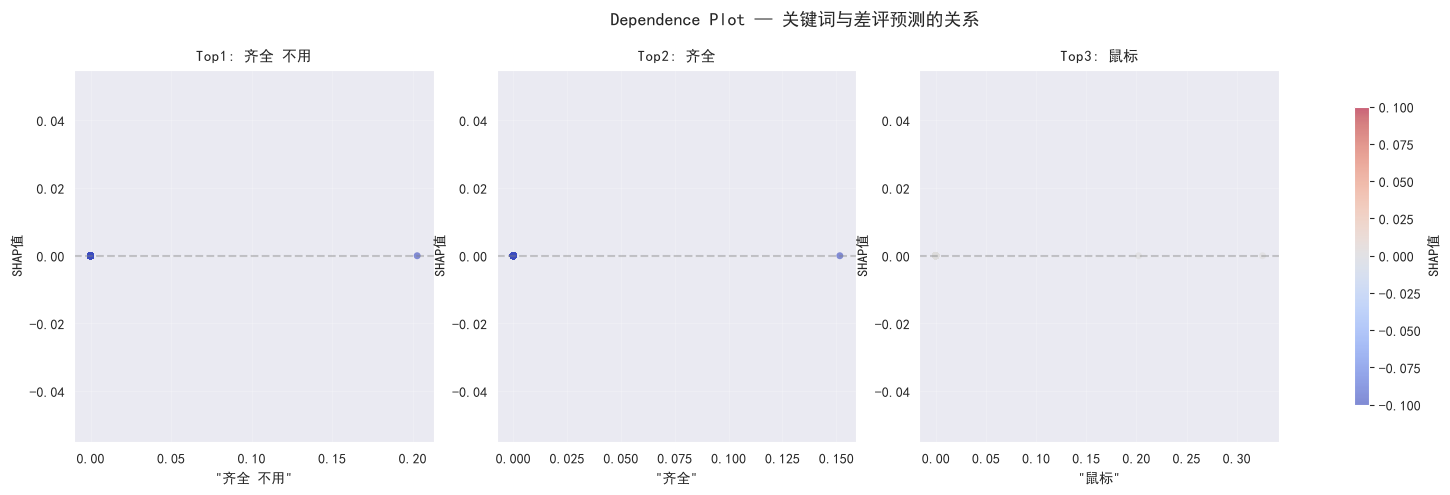


结构化特征重要性
-------------------------------------------------------
   1. 情感分数                1.4029
   2. 评论长度                0.2301
   3. 内存_enc              0.1205
   4. 产品系列_酷睿版            0.0811
   5. 产品系列_Y7000游戏本       0.0000
   6. 产品系列_锐龙版            0.0000
   7. 硬盘_enc              0.0000
   8. 复购_enc              0.0000

✅ 全部完成！


In [96]:
# ── 5. Top 负面关键词提取 ──

# 只看 TF-IDF 部分（前 N 列）
n_tfidf = len(tfidf_names)
tfidf_shap_mean = np.abs(shap_vals[:, :n_tfidf]).mean(axis=0)

top_n = 15
top_idx = np.argsort(tfidf_shap_mean)[::-1][:top_n]

top_df = pd.DataFrame({
    '排名': range(1, top_n + 1),
    '关键词': tfidf_names[top_idx],
    '|SHAP|均值': [f'{v:.4f}' for v in tfidf_shap_mean[top_idx]],
    '影响方向': ['推高差评 ↑' if np.mean(shap_vals[:, :n_tfidf], axis=0)[i] > 0 
                 else '降低差评 ↓' for i in top_idx]
})

print(f"\n{'='*55}")
print(f"Top{top_n} 差评驱动关键词")
print(f"{'='*55}")
print(top_df.to_string(index=False))

# ── 6. Dependence Plot（Top3）──
print("\n绘制 Dependence Plot...")
top3_feats = tfidf_names[top_idx[:3]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, fname in enumerate(top3_feats):
    fid = list(tfidf_names).index(fname)  # 在 TF-IDF 范围内的列索引
    
    ax = axes[i]
    sc = ax.scatter(
        X_sample[:, fid],           # 特征值（行范围 0~sample_size-1 ✓）
        shap_vals[:, fid],          # SHAP值（同上 ✓）
        c=shap_vals[:, fid],
        cmap='coolwarm', alpha=0.6, s=25, edgecolors='none'
    )
    ax.set_xlabel(f'"{fname}"', fontsize=10)
    ax.set_ylabel('SHAP值', fontsize=10)
    ax.set_title(f'Top{i+1}: {fname}', fontsize=11, fontweight='bold')
    ax.axhline(0, color='gray', ls='--', alpha=0.4)
    ax.grid(alpha=0.2)

plt.suptitle('Dependence Plot — 关键词与差评预测的关系', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.colorbar(sc, ax=axes, shrink=0.8, label='SHAP值')
plt.show()

# ── 7. 结构化特征重要性 ──
print("\n" + "=" * 55)
print("结构化特征重要性")
print("-" * 55)
struct_shap = np.abs(shap_vals[:, n_tfidf:]).mean(axis=0)
for r, (name, val) in enumerate(sorted(zip(struct_names, struct_shap), key=lambda x:-x[1]), 1):
    print(f"  {r:2d}. {name:18s}  {val:.4f}")

print("\n✅ 全部完成！")


# 五、看板补充图

C:\Users\36171\AppData\Local\Temp\ipykernel_39976\3114470018.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(monthly_stats['月份'], rotation=45)


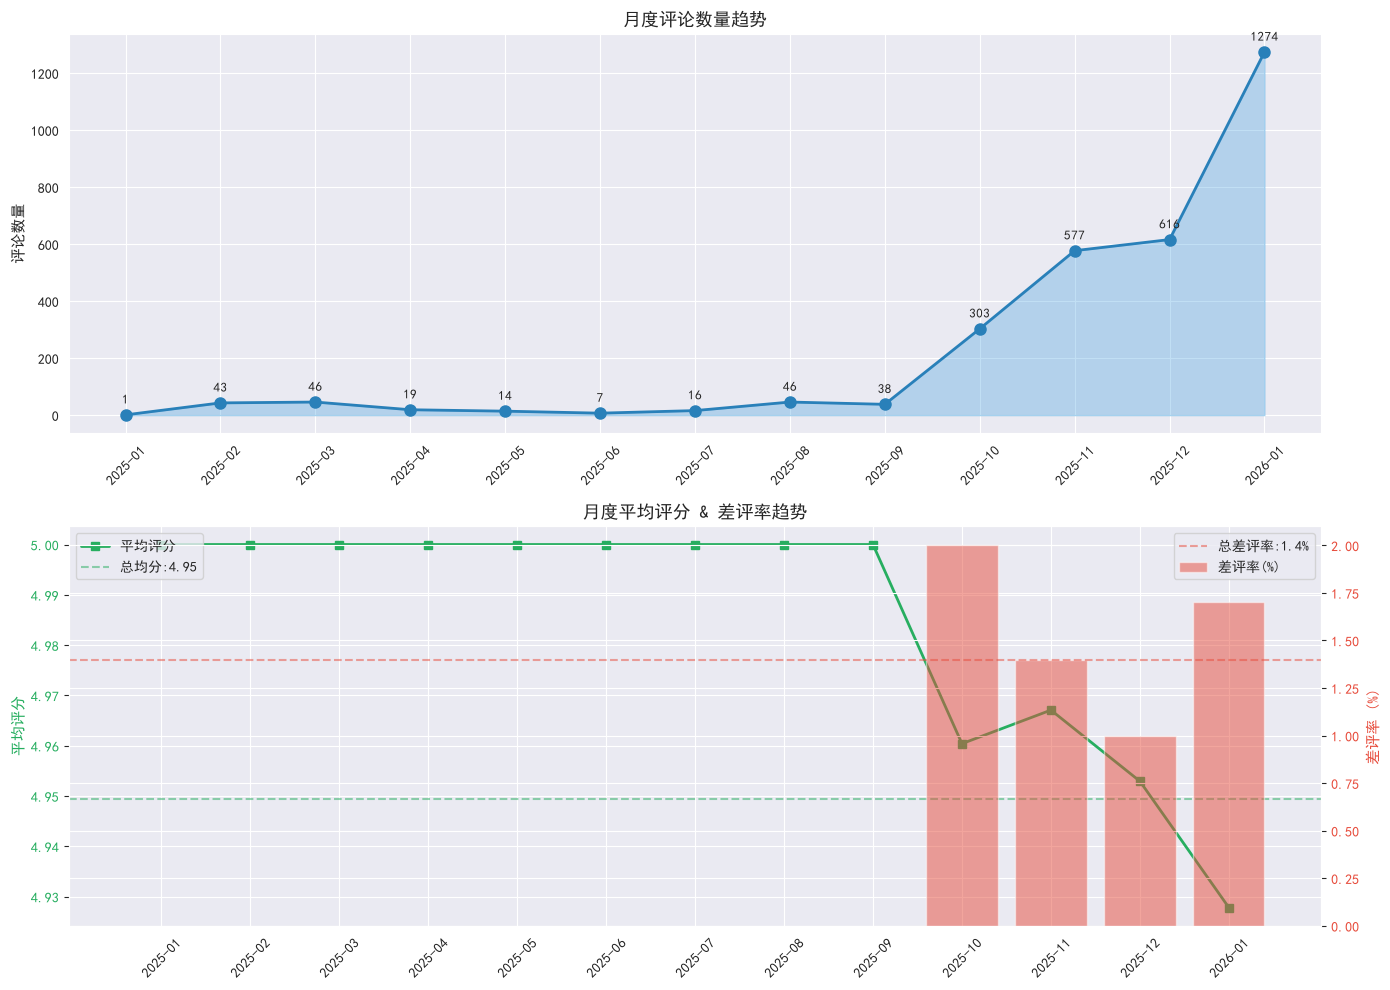

月度统计摘要:
     月份  评论数     平均评分  差评数  差评率
2025-01    1 5.000000    0  0.0
2025-02   43 5.000000    0  0.0
2025-03   46 5.000000    0  0.0
2025-04   19 5.000000    0  0.0
2025-05   14 5.000000    0  0.0
2025-06    7 5.000000    0  0.0
2025-07   16 5.000000    0  0.0
2025-08   46 5.000000    0  0.0
2025-09   38 5.000000    0  0.0
2025-10  303 4.960396    6  2.0
2025-11  577 4.967071    8  1.4
2025-12  616 4.952922    6  1.0
2026-01 1274 4.927786   22  1.7


In [97]:
# ========== 图表1：月度舆情趋势折线图 ==========
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 确保date列存在
if 'date' in df.columns:
    df_plot = df.copy()
    df_plot['月份'] = df_plot['date'].dt.to_period('M').astype(str)
    
    monthly_stats = df_plot.groupby('月份').agg(
        评论数=('评分', 'count'),
        平均评分=('评分', 'mean'),
        差评数=('评分', lambda x: (x <= 3).sum()),
    ).reset_index()
    monthly_stats['差评率'] = (monthly_stats['差评数'] / monthly_stats['评论数'] * 100).round(1)
    
    # (1) 评论数量趋势
    ax1 = axes[0]
    ax1.fill_between(monthly_stats['月份'], monthly_stats['评论数'], 
                     alpha=0.3, color='#3498db')
    ax1.plot(monthly_stats['月份'], monthly_stats['评论数'], 
             marker='o', linewidth=2, markersize=8, color='#2980b9')
    ax1.set_title('月度评论数量趋势', fontsize=13, fontweight='bold')
    ax1.set_ylabel('评论数量', fontsize=11)
    ax1.tick_params(axis='x', rotation=45)
    for i, row in monthly_stats.iterrows():
        ax1.annotate(f'{int(row["评论数"])}', 
                    xy=(i, row['评论数']), 
                    textcoords="offset points", xytext=(0,8), 
                    ha='center', fontsize=9)
    
    # (2) 平均评分 & 差评率 双轴图
    ax2 = axes[1]
    ax2_twin = ax2.twinx()
    
    line1 = ax2.plot(monthly_stats['月份'], monthly_stats['平均评分'], 
                     marker='s', linewidth=2, color='#27ae60', label='平均评分')
    ax2.set_ylabel('平均评分', fontsize=11, color='#27ae60')
    ax2.tick_params(axis='y', labelcolor='#27ae60')
    ax2.axhline(y=df['评分'].mean(), color='#27ae60', linestyle='--', 
                alpha=0.5, label=f'总均分:{df["评分"].mean():.2f}')
    
    line2 = ax2_twin.bar(monthly_stats['月份'], monthly_stats['差评率'], 
                         alpha=0.5, color='#e74c3c', label='差评率(%)')
    ax2_twin.set_ylabel('差评率 (%)', fontsize=11, color='#e74c3c')
    ax2_twin.tick_params(axis='y', labelcolor='#e74c3c')
    ax2_twin.axhline(y=(df['评分']<=3).mean()*100, color='#e74c3c', linestyle='--', 
                     alpha=0.5, label=f'总差评率:{(df["评分"]<=3).mean()*100:.1f}%')
    
    ax2.set_title('月度平均评分 & 差评率趋势', fontsize=13, fontweight='bold')
    ax2.set_xticklabels(monthly_stats['月份'], rotation=45)
    ax2.legend(loc='upper left')
    ax2_twin.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    print("月度统计摘要:")
    print(monthly_stats.to_string(index=False))
else:
    print("⚠️ 未找到'date'列，无法生成时间趋势图")


差评Top20高频词:
   1. 买          :  14次
   2. 没          :  11次
   3. 开机         :   9次
   4. 垃圾         :   8次
   5. 激活         :   6次
   6. 死机         :   6次
   7. 找          :   6次
   8. 退          :   6次
   9. 小时         :   6次
  10. 电池         :   5次
  11. 国补         :   5次
  12. 收到         :   5次
  13. 不能         :   5次
  14. 不到         :   5次
  15. 货          :   5次
  16. 挺          :   4次
  17. 想          :   4次
  18. 开          :   4次
  19. 屏幕         :   4次
  20. 崩溃         :   4次


findfont: Failed to find font weight bold, now using 400.


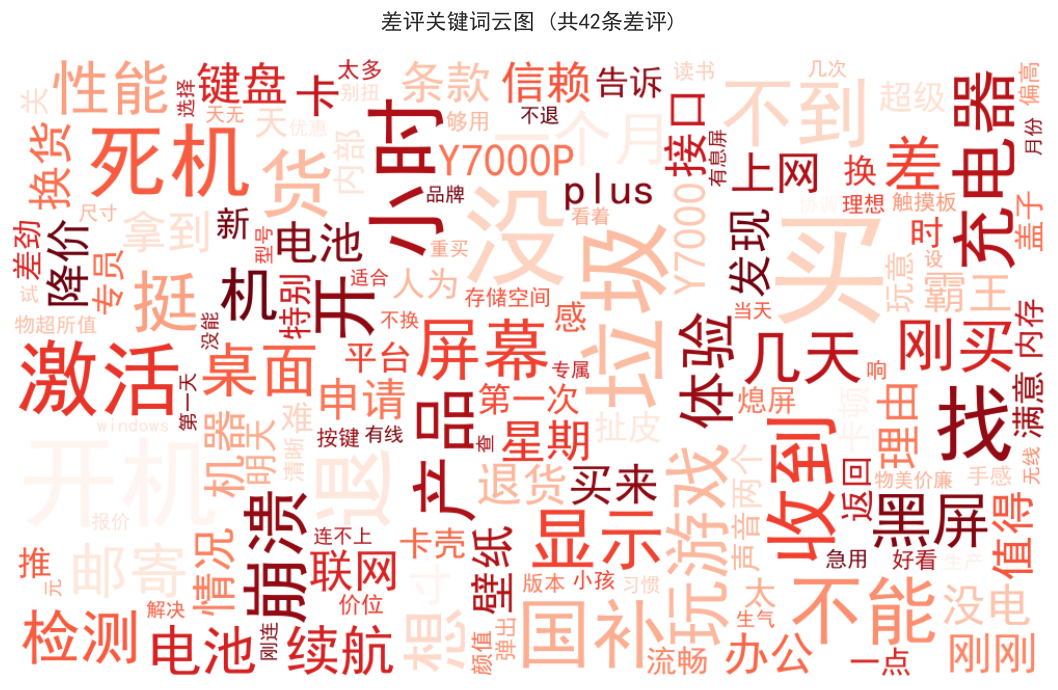

In [98]:
# ========== 图表2：差评关键词云图 ==========
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import collections

# 检查是否安装了wordcloud，没有则提示安装
try:
    from wordcloud import WordCloud
except ImportError:
    print("请先安装wordcloud: pip install wordcloud")

# 准备差评文本
df_neg_temp = df[df['评分'] <= 3].copy()
neg_text = ' '.join(df_neg_temp['评论分词_去停用词'].dropna().tolist())

# 统计词频（用于辅助展示）
word_freq = collections.Counter(neg_text.split())
top20_words = dict(word_freq.most_common(20))

print("差评Top20高频词:")
for i, (word, count) in enumerate(top20_words.items(), 1):
    print(f"  {i:2d}. {word:10s} : {count:3d}次")

# 生成词云
try:
    # 尝试使用系统中文字体（Windows）
    font_path_win = 'C:/Windows/Fonts/simhei.ttf'
    font_path_mac = '/System/Library/Fonts/PingFang.ttc'
    
    import os
    if os.path.exists(font_path_win):
        font_path = font_path_win
    elif os.path.exists(font_path_mac):
        font_path = font_path_mac
    else:
        font_path = None  # 使用默认字体
    
    wc = WordCloud(
        font_path=font_path,
        width=1000,
        height=600,
        background_color='white',
        max_words=150,
        max_font_size=120,
        min_font_size=14,
        colormap='Reds',
        prefer_horizontal=0.7,
        margin=5
    ).generate(neg_text)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'差评关键词云图 (共{len(df_neg_temp)}条差评)', 
                fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"词云生成失败: {e}")
    print("备选方案：使用柱状图展示Top20词汇")
    
    # 备选：柱状图
    fig, ax = plt.subplots(figsize=(12, 6))
    words = list(top20_words.keys())[::-1]
    counts = list(top20_words.values())[::-1]
    colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(words)))[::-1]
    
    ax.barh(words, counts, color=colors, edgecolor='white')
    ax.set_xlabel('出现次数', fontsize=11)
    ax.set_title('差评Top20高频词汇（词云替代方案）', fontsize=14, fontweight='bold')
    for i, v in enumerate(counts):
        ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
    plt.tight_layout()
    plt.show()


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
C:\Users\36171\AppData\Local\Temp\ipykernel_39976\476727397.py:111: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\36171\AppData\Local\Temp\ipykernel_39976\476727397.py:111: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
findfont: Failed to find font weight bold, now using 400.
C:\Users\36171\AppData\Local\Temp\ipykernel_39976\476727397.py:111: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\36171\PycharmProjects\Capgemini_Lenovo\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\36171\PycharmProjects\Capgemini_Lenovo\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9888 

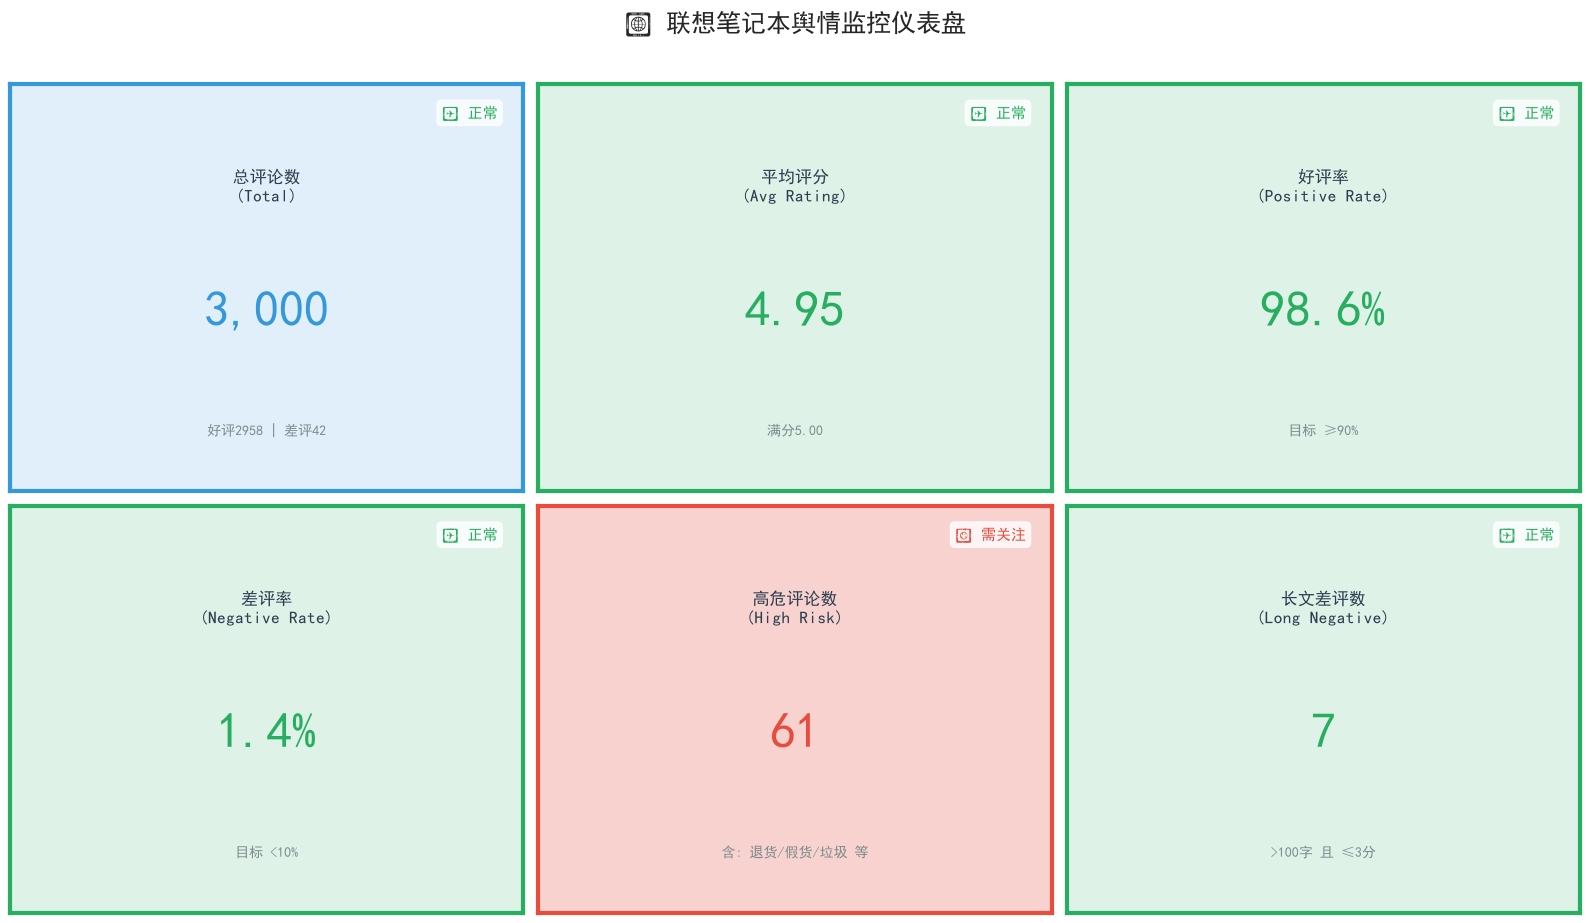

舆情监控预警报告

【整体概况】
  总评论数:     3,000 条
  平均评分:     4.95 / 5.00
  好评率:       98.6% (目标≥90% ✓)
  差评率:       1.4% (目标<10%  ✓)

【风险预警】
  高危评论数:   61 条 (阈值≤20 ⚠️ 需关注)
  长文差评数:   7 条 (阈值≤10 ✓)

【建议行动】
  发现异常指标，建议立即排查原因并制定应对措施。



In [99]:
# ========== 图表3：预警指标卡面板 ==========
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# 计算各项指标
total_comments = len(df)
avg_rating = df['评分'].mean()
positive_rate = (df['评分'] >= 4).mean() * 100
negative_rate = (df['评分'] <= 3).mean() * 100
neg_count = (df['评分'] <= 3).sum()

# 定义高危关键词
high_risk_keywords = ['退货', '垃圾', '假货', '骗', '烂', '后悔', '失望']
def count_high_risk(text):
    text_str = str(text).lower()
    return sum(1 for kw in high_risk_keywords if kw in text_str)

df['高危词命中数'] = df['评论内容'].apply(count_high_risk)
high_risk_comments = (df['高危词命中数'] >= 1).sum()

# 长评论预警（>100字且差评）
long_negative = ((df['评论长度'] > 100) & (df['评分'] <= 3)).sum()

# 各指标卡片
metrics = [
    {
        'title': f'总评论数\n(Total)',
        'value': f'{total_comments:,}',
        'subtitle': f'好评{total_comments-neg_count} | 差评{neg_count}',
        'color': '#3498db',
        'threshold_ok': True
    },
    {
        'title': f'平均评分\n(Avg Rating)',
        'value': f'{avg_rating:.2f}',
        'subtitle': '满分5.00',
        'color': '#27ae60' if avg_rating >= 4.5 else '#f39c12' if avg_rating >= 4.0 else '#e74c3c',
        'threshold_ok': avg_rating >= 4.5
    },
    {
        'title': f'好评率\n(Positive Rate)',
        'value': f'{positive_rate:.1f}%',
        'subtitle': f'目标 ≥90%',
        'color': '#27ae60' if positive_rate >= 90 else '#f39c12' if positive_rate >= 80 else '#e74c3c',
        'threshold_ok': positive_rate >= 90
    },
    {
        'title': f'差评率\n(Negative Rate)',
        'value': f'{negative_rate:.1f}%',
        'subtitle': f'目标 <10%',
        'color': '#27ae60' if negative_rate < 10 else '#f39c12' if negative_rate < 15 else '#e74c3c',
        'threshold_ok': negative_rate < 10
    },
    {
        'title': f'高危评论数\n(High Risk)',
        'value': f'{high_risk_comments}',
        'subtitle': f'含: 退货/假货/垃圾 等',
        'color': '#e74c3c' if high_risk_comments > 50 else '#f39c12' if high_risk_comments > 20 else '#27ae60',
        'threshold_ok': high_risk_comments <= 20
    },
    {
        'title': f'长文差评数\n(Long Negative)',
        'value': f'{long_negative}',
        'subtitle': '>100字 且 ≤3分',
        'color': '#e74c3c' if long_negative > 30 else '#f39c12' if long_negative > 10 else '#27ae60',
        'threshold_ok': long_negative <= 10
    }
]

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # 背景色
    bg_alpha = 0.15 if metric['threshold_ok'] else 0.25
    ax.set_facecolor((*plt.cm.colors.to_rgb(metric['color']), bg_alpha))
    
    # 边框
    for spine in ax.spines.values():
        spine.set_color(metric['color'])
        spine.set_linewidth(3)
    
    # 标题
    ax.text(0.5, 0.75, metric['title'], transform=ax.transAxes,
            ha='center', va='center', fontsize=12, fontweight='bold',
            color='#2c3e50')
    
    # 数值
    ax.text(0.5, 0.45, metric['value'], transform=ax.transAxes,
            ha='center', va='center', fontsize=36, fontweight='bold',
            color=metric['color'])
    
    # 副标题
    ax.text(0.5, 0.15, metric['subtitle'], transform=ax.transAxes,
            ha='center', va='center', fontsize=10, color='#7f8c8d')
    
    # 状态指示器
    status = '✓ 正常' if metric['threshold_ok'] else '⚠ 需关注'
    status_color = '#27ae60' if metric['threshold_ok'] else '#e74c3c'
    ax.text(0.95, 0.95, status, transform=ax.transAxes,
            ha='right', va='top', fontsize=11, fontweight='bold',
            color=status_color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('📊 联想笔记本舆情监控仪表盘', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 文字版报告
print("=" * 60)
print("舆情监控预警报告")
print("=" * 60)
print(f"""
【整体概况】
  总评论数:     {total_comments:,} 条
  平均评分:     {avg_rating:.2f} / 5.00
  好评率:       {positive_rate:.1f}% (目标≥90% {'✓' if positive_rate>=90 else '✗'})
  差评率:       {negative_rate:.1f}% (目标<10%  {'✓' if negative_rate<10 else '✗'})

【风险预警】
  高危评论数:   {high_risk_comments} 条 (阈值≤20 {'✓' if high_risk_comments<=20 else '⚠️ 需关注'})
  长文差评数:   {long_negative} 条 (阈值≤10 {'✓' if long_negative<=10 else '⚠️ 需关注'})

【建议行动】
  {'当前舆情状况良好，继续保持监控。' if all(m['threshold_ok'] for m in metrics) else '发现异常指标，建议立即排查原因并制定应对措施。'}
""")


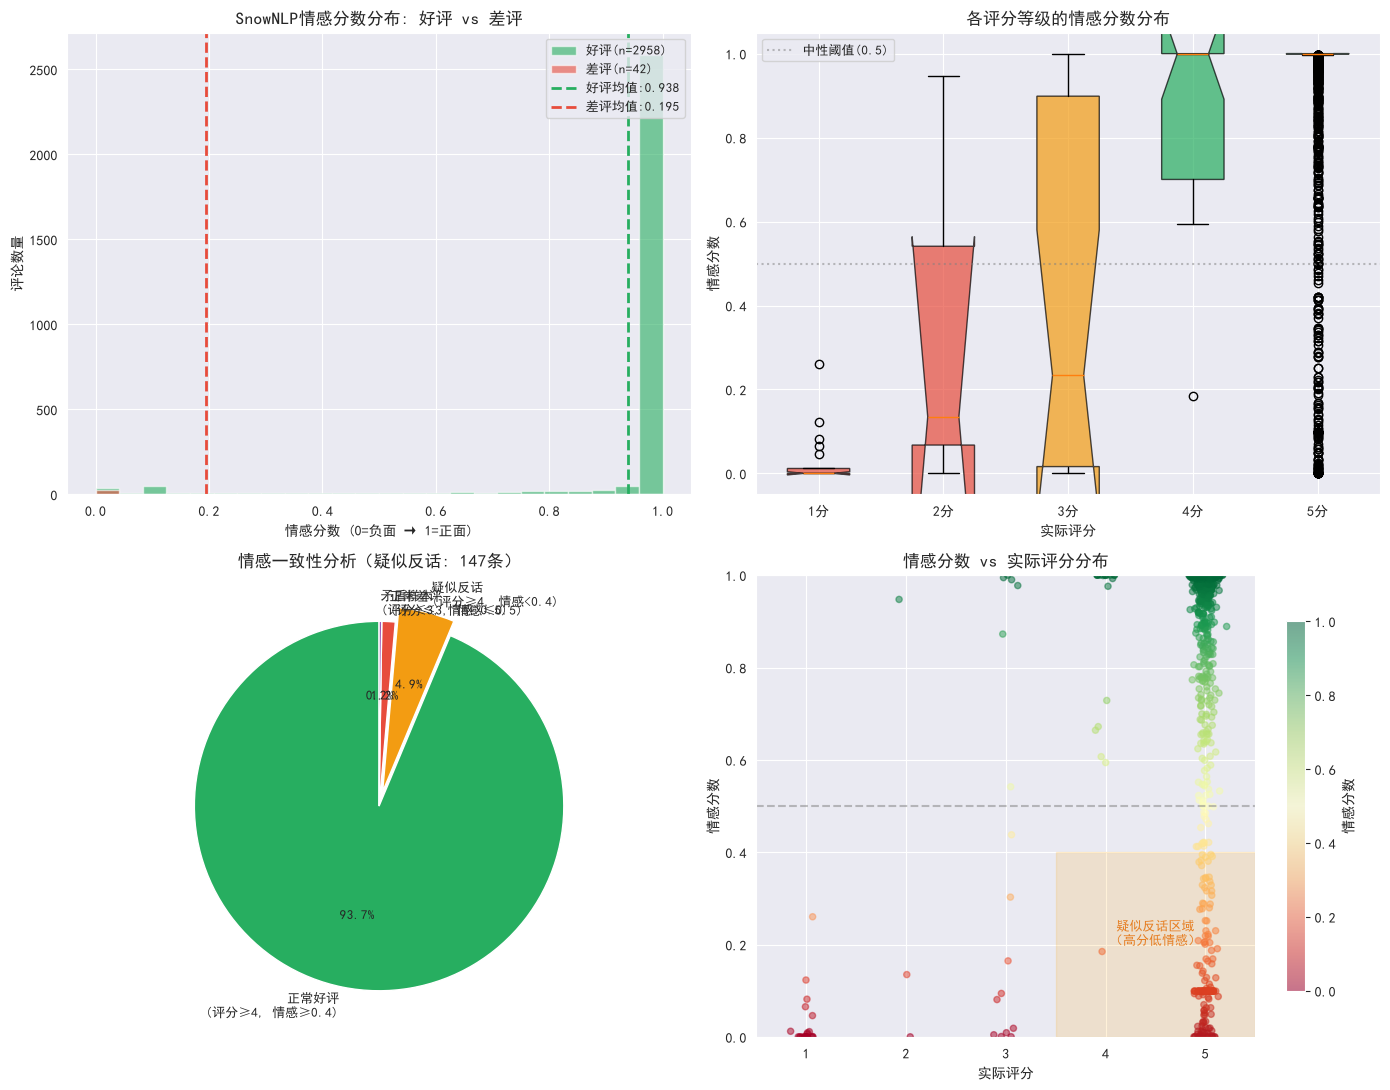

情感分析一致性检测

总体情感分数统计:
全局均值:      0.928
全局中位数:    1.000

好评组（评分≥4）:
样本数:       2958
情感均值:     0.938
疑似反话数:   147 (5.0%)

差评组（评分≤3）:
样本数:       42
情感均值:     0.195
矛盾样本数:   7



In [100]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

df_neg = df[df['评分'] <= 3].copy()
df_pos = df[df['评分'] >= 4].copy()

# (1) 情感分数直方图对比

ax1 = axes[0, 0]
bins = np.linspace(0, 1, 25)

ax1.hist(
    df_pos['情感分数'].dropna(),
    bins=bins,
    alpha=0.6,
    label=f'好评(n={len(df_pos)})',
    color='#27ae60',
    edgecolor='white'
)

ax1.hist(
    df_neg['情感分数'].dropna(),
    bins=bins,
    alpha=0.6,
    label=f'差评(n={len(df_neg)})',
    color='#e74c3c',
    edgecolor='white'
)

if not df_pos['情感分数'].dropna().empty:
    pos_mean = df_pos['情感分数'].mean()
    ax1.axvline(
        pos_mean,
        color='#27ae60',
        linestyle='--',
        linewidth=2,
        label=f'好评均值:{pos_mean:.3f}'
    )

if not df_neg['情感分数'].dropna().empty:
    neg_mean = df_neg['情感分数'].mean()
    ax1.axvline(
        neg_mean,
        color='#e74c3c',
        linestyle='--',
        linewidth=2,
        label=f'差评均值:{neg_mean:.3f}'
    )

ax1.set_title(
    'SnowNLP情感分数分布: 好评 vs 差评',
    fontsize=12,
    fontweight='bold'
)
ax1.set_xlabel('情感分数 (0=负面 → 1=正面)', fontsize=10)
ax1.set_ylabel('评论数量', fontsize=10)
ax1.legend(fontsize=9, loc='upper right')


# (2) 各评分的情感分数箱线图

ax2 = axes[0, 1]

rating_data = [
    df.loc[df['评分'] == rating, '情感分数'].dropna().values
    for rating in [1, 2, 3, 4, 5]
]

bp = ax2.boxplot(
    rating_data,
    tick_labels=['1分', '2分', '3分', '4分', '5分'],
    patch_artist=True,
    notch=True
)

colors_box = [
    '#e74c3c',
    '#e74c3c',
    '#f39c12',
    '#27ae60',
    '#27ae60'
]

for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_title(
    '各评分等级的情感分数分布',
    fontsize=12,
    fontweight='bold'
)
ax2.set_xlabel('实际评分', fontsize=10)
ax2.set_ylabel('情感分数', fontsize=10)
ax2.axhline(
    0.5,
    color='gray',
    linestyle=':',
    alpha=0.5,
    label='中性阈值(0.5)'
)
ax2.legend(fontsize=9)


# (3) 情感一致性和疑似反话识别

ax3 = axes[1, 0]

df['疑似反话'] = (
    (df['评分'] >= 4) &
    (df['情感分数'] < 0.4)
)

sarcastic_count = int(df['疑似反话'].sum())

normal_positive_count = (
    (df['评分'] >= 4) &
    (df['情感分数'] >= 0.4)
).sum()

normal_negative_count = (
    (df['评分'] <= 3) &
    (df['情感分数'] <= 0.5)
).sum()

conflict_count = (
    (df['评分'] <= 3) &
    (df['情感分数'] > 0.5)
).sum()

categories = [
    '正常好评\n(评分≥4, 情感≥0.4)',
    '疑似反话\n(评分≥4, 情感<0.4)',
    '正常差评\n(评分≤3, 情感≤0.5)',
    '矛盾样本\n(评分≤3, 情感>0.5)'
]

values = [
    normal_positive_count,
    sarcastic_count,
    normal_negative_count,
    conflict_count
]

colors_pie = [
    '#27ae60',
    '#f39c12',
    '#e74c3c',
    '#9b59b6'
]

if sum(values) > 0:
    wedges, texts, autotexts = ax3.pie(
        values,
        labels=categories,
        autopct='%1.1f%%',
        colors=colors_pie,
        explode=[0, 0.08, 0, 0],
        startangle=90,
        textprops={'fontsize': 9}
    )
else:
    ax3.text(
        0.5,
        0.5,
        '暂无可用数据',
        ha='center',
        va='center',
        fontsize=12
    )

ax3.set_title(
    f'情感一致性分析（疑似反话: {sarcastic_count}条）',
    fontsize=12,
    fontweight='bold'
)


# (4) 情感分数与评分散点图

ax4 = axes[1, 1]

scatter_df = df[['评分', '情感分数']].dropna().copy()

if not scatter_df.empty:
    jittered_rating = (
        scatter_df['评分'].to_numpy() +
        np.random.normal(0, 0.05, len(scatter_df))
    )

    scatter = ax4.scatter(
        jittered_rating,
        scatter_df['情感分数'],
        c=scatter_df['情感分数'],
        cmap='RdYlGn',
        alpha=0.5,
        s=20
    )

    plt.colorbar(
        scatter,
        ax=ax4,
        shrink=0.8,
        label='情感分数'
    )

ax4.set_xticks([1, 2, 3, 4, 5])
ax4.set_xlim(0.5, 5.5)
ax4.set_ylim(0, 1)
ax4.set_xlabel('实际评分', fontsize=10)
ax4.set_ylabel('情感分数', fontsize=10)
ax4.set_title(
    '情感分数 vs 实际评分分布',
    fontsize=12,
    fontweight='bold'
)

ax4.axhline(
    0.5,
    color='gray',
    linestyle='--',
    alpha=0.5
)

ax4.fill_between(
    [3.5, 5.5],
    [0, 0],
    [0.4, 0.4],
    alpha=0.15,
    color='orange'
)

ax4.text(
    4.5,
    0.2,
    '疑似反话区域\n（高分低情感）',
    ha='center',
    fontsize=9,
    color='#e67e22',
    style='italic'
)

plt.tight_layout()
plt.show()


# 统计摘要

positive_count = len(df_pos)

if positive_count > 0:
    sarcastic_rate = sarcastic_count / positive_count * 100
else:
    sarcastic_rate = 0

print("=" * 55)
print("情感分析一致性检测")
print("=" * 55)

print(f"""
总体情感分数统计:
全局均值:      {df['情感分数'].mean():.3f}
全局中位数:    {df['情感分数'].median():.3f}

好评组（评分≥4）:
样本数:       {len(df_pos)}
情感均值:     {df_pos['情感分数'].mean():.3f}
疑似反话数:   {sarcastic_count} ({sarcastic_rate:.1f}%)

差评组（评分≤3）:
样本数:       {len(df_neg)}
情感均值:     {df_neg['情感分数'].mean():.3f}
矛盾样本数:   {conflict_count}
""")

高风险配置完整排名 (仅显示评论数≥5的配置)
                    评论数  平均评分    差评率  平均情感  高危词占比  综合风险分
产品系列     内存  硬盘                                         
酷睿版      24G 512G   132  4.52  11.36  0.73   6.06   12.9
锐龙版      16G 512G    38  4.76   5.26  0.76   5.26    8.9
R7000游戏本 16G 512G    13  4.69   7.69  0.90   0.00    6.2
             1T     515  4.98   0.39  0.90   1.17    2.5
Y7000游戏本 16G 1T    1461  4.97   0.75  0.94   2.05    2.0
酷睿版      32G 1T     742  4.97   1.48  0.97   1.89    1.6
锐龙版      24G 1T      60  5.00   0.00  0.96   1.67    1.1
酷睿版      24G 1T      29  5.00   0.00  0.97   0.00    0.6
锐龙版      32G 1T       9  5.00   0.00  1.00   0.00    0.0

⚠️  需重点关注的Top3高风险配置:
  1. 酷睿版 | 24G内存 | 512G硬盘
     风险分:12.9 | 差评率:11.4% | 均分:4.52 | 样本:132条
  2. 锐龙版 | 16G内存 | 512G硬盘
     风险分:8.9 | 差评率:5.3% | 均分:4.76 | 样本:38条
  3. R7000游戏本 | 16G内存 | 512G硬盘
     风险分:6.2 | 差评率:7.7% | 均分:4.69 | 样本:13条


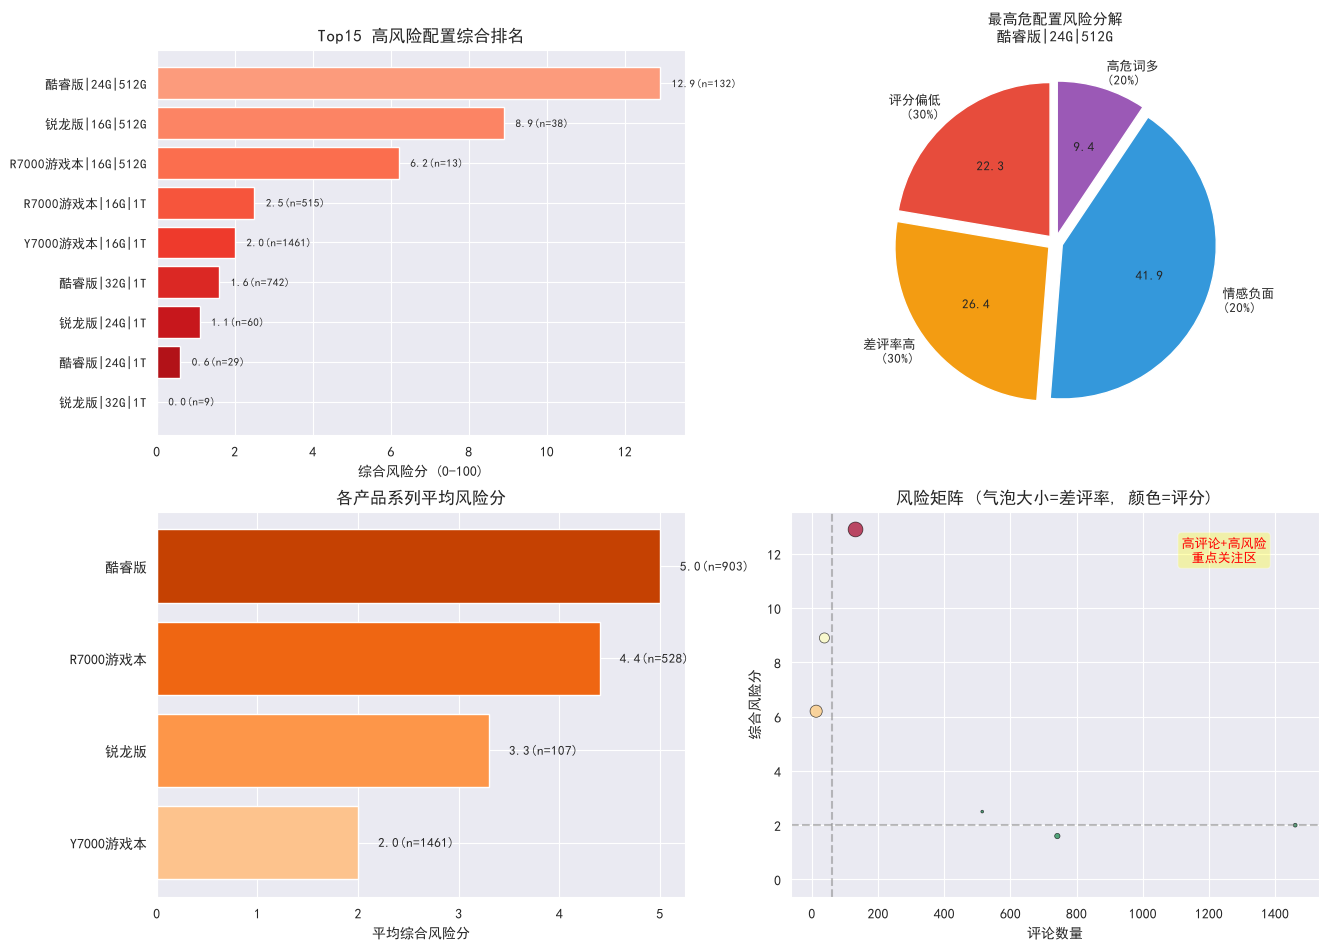

In [101]:
# ========== 图表6：高风险配置综合排名图 ==========
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 计算各维度的综合风险分
config_risk = df.groupby(['产品系列', '内存', '硬盘']).agg(
    评论数=('评分', 'count'),
    平均评分=('评分', 'mean'),
    差评率=('评分', lambda x: (x <= 3).sum() / len(x) * 100),
    平均情感=('情感分数', 'mean'),
    平均评论长度=('评论长度', 'mean'),
    高危词占比=('高危词命中数', lambda x: (x > 0).sum() / len(x) * 100)
).round(2)

# 只看评论数>=5的配置（保证统计意义）
config_risk = config_risk[config_risk['评论数'] >= 5].copy()

# 计算综合风险分 (0-100)
def calc_risk_score(row):
    score = 0
    # 评分越低越危险 (权重30%)
    score += (5 - row['平均评分']) / 5 * 30
    # 差评率越高越危险 (权重30%)
    score += row['差评率'] / 100 * 30
    # 情感分越低越危险 (权重20%)
    score += (1 - row['平均情感']) * 20
    # 高危词占比 (权重20%)
    score += row['高危词占比'] / 100 * 20
    return round(score, 1)

config_risk['综合风险分'] = config_risk.apply(calc_risk_score, axis=1)
config_risk = config_risk.sort_values('综合风险分', ascending=False)

# (1) Top15 高风险配置排名
ax1 = axes[0, 0]
top15_risk = config_risk.head(15)
y_labels = [f"{idx[0]}|{idx[1]}|{idx[2]}" for idx in top15_risk.index]

colors_risk = plt.cm.Reds(np.linspace(0.35, 0.9, len(top15_risk)))
bars = ax1.barh(range(len(top15_risk)), top15_risk['综合风险分'].values, 
               color=colors_risk, edgecolor='white')
ax1.set_yticks(range(len(top15_risk)))
ax1.set_yticklabels(y_labels, fontsize=9)
ax1.set_xlabel('综合风险分 (0-100)', fontsize=10)
ax1.set_title('Top15 高风险配置综合排名', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

for bar, val, comment in zip(bars, top15_risk['综合风险分'].values, top15_risk['评论数'].values):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}(n={comment})', va='center', fontsize=8)

# (2) 风险因素分解（取Top1配置）
ax2 = axes[0, 1]
if len(config_risk) > 0:
    top1_config = config_risk.index[0]
    top1_data = config_risk.loc[top1_config]
    
    factors = ['评分偏低\n(30%)', '差评率高\n(30%)', '情感负面\n(20%)', '高危词多\n(20%)']
    factor_scores = [
        (5 - top1_data['平均评分']) / 5 * 30,
        top1_data['差评率'] / 100 * 30,
        (1 - top1_data['平均情感']) * 20,
        top1_data['高危词占比'] / 100 * 20
    ]
    colors_factor = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6']
    
    wedges, texts, autotexts = ax2.pie(factor_scores, labels=factors, autopct='%1.1f',
                                        colors=colors_factor, startangle=90,
                                        explode=[0.05]*4, textprops={'fontsize':9})
    ax2.set_title(f'最高危配置风险分解\n{top1_config[0]}|{top1_config[1]}|{top1_config[2]}', 
                 fontsize=11, fontweight='bold')

# (3) 产品系列风险对比
ax3 = axes[1, 0]
product_risk = config_risk.reset_index().groupby('产品系列').agg({
    '综合风险分': 'mean',
    '评论数': 'sum'
}).round(1)
product_risk = product_risk.sort_values('综合风险分', ascending=True)

bars3 = ax3.barh(product_risk.index, product_risk['综合风险分'],
                 color=plt.cm.Oranges(np.linspace(0.3, 0.8, len(product_risk))),
                 edgecolor='white')
ax3.set_xlabel('平均综合风险分', fontsize=10)
ax3.set_title('各产品系列平均风险分', fontsize=12, fontweight='bold')
for bar, val, n in zip(bars3, product_risk['综合风险分'], product_risk['评论数']):
    ax3.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}(n={n})', 
            va='center', fontsize=9)

# (4) 风险矩阵：评论数 vs 风险分
ax4 = axes[1, 1]
scatter = ax4.scatter(config_risk['评论数'], config_risk['综合风险分'],
                      s=config_risk['差评率']*10,  # 气泡大小=差评率
                      c=config_risk['平均评分'], cmap='RdYlGn',
                      alpha=0.7, edgecolors='black', linewidth=0.5)
ax4.set_xlabel('评论数量', fontsize=10)
ax4.set_ylabel('综合风险分', fontsize=10)
ax4.set_title('风险矩阵 (气泡大小=差评率, 颜色=评分)', fontsize=12, fontweight='bold')

# 标注象限
# 标注象限

risk_median = config_risk['综合风险分'].median()
count_median = config_risk['评论数'].median()

ax4.axhline(
    risk_median,
    color='gray',
    linestyle='--',
    alpha=0.5
)

ax4.axvline(
    count_median,
    color='gray',
    linestyle='--',
    alpha=0.5
)

x_min, x_max = ax4.get_xlim()
y_min, y_max = ax4.get_ylim()

text_x = x_min + (x_max - x_min) * 0.82
text_y = y_min + (y_max - y_min) * 0.90

ax4.text(
    text_x,
    text_y,
    '高评论+高风险\n重点关注区',
    fontsize=9,
    color='red',
    ha='center',
    va='center',
    bbox=dict(
        boxstyle='round',
        facecolor='yellow',
        alpha=0.3
    )
)
# 详细排名表
print("=" * 70)
print("高风险配置完整排名 (仅显示评论数≥5的配置)")
print("=" * 70)
display_cols = ['评论数', '平均评分', '差评率', '平均情感', '高危词占比', '综合风险分']
print(config_risk[display_cols].head(20).to_string())

# 业务建议
top3_risky = config_risk.head(3)
print(f"\n⚠️  需重点关注的Top3高风险配置:")
for i, (idx, row) in enumerate(top3_risky.iterrows(), 1):
    print(f"  {i}. {idx[0]} | {idx[1]}内存 | {idx[2]}硬盘")
    print(f"     风险分:{row['综合风险分']:.1f} | 差评率:{row['差评率']:.1f}% | "
          f"均分:{row['平均评分']:.2f} | 样本:{int(row['评论数'])}条")


## 网站模型导出
运行完前面的训练单元后，运行下面单元生成网站后端可直接加载的模型包。


In [102]:
# ========== 导出网站自动分析模型包 ==========
from pathlib import Path
import joblib

# 使用可序列化的分词函数，避免 Flask 加载 Notebook 中的 tokenizer_func 失败
tfidf_vectorizer.tokenizer = str.split

website_model_bundle = {
    "bundle_version": "lenovo-opinion-xgb-v2",
    "model_name": "XGBoost",
    "model": xgb_model,
    "tfidf_vectorizer": tfidf_vectorizer,
    "product_encoder": ohe,
    "memory_encoder": le_memory,
    "repurchase_encoder": le_repurchase,
    "disk_mapping": disk_mapping,
    "feature_columns": X_combined.columns.tolist(),
    "negative_threshold": 0.5,
    "label_definition": {0: "差评", 1: "好评"},
}

export_directory = Path("website_model")
export_directory.mkdir(exist_ok=True)
export_path = export_directory / "xgb_sentiment_bundle.joblib"
joblib.dump(website_model_bundle, export_path, compress=3)

# 立即回读，确保导出的文件可以独立加载
checked_bundle = joblib.load(export_path)
assert checked_bundle["bundle_version"] == "lenovo-opinion-xgb-v2"
assert len(checked_bundle["feature_columns"]) == X_combined.shape[1]
print(f"网站模型已导出: {export_path.resolve()}")
print(f"模型: {checked_bundle['model_name']}")
print(f"特征数: {len(checked_bundle['feature_columns'])}")
print("请把该文件复制到 Backend/analysis/xgb_sentiment_bundle.joblib")


网站模型已导出: C:\Users\36171\PycharmProjects\Capgemini_Lenovo\Analysis\website_model\xgb_sentiment_bundle.joblib
模型: XGBoost
特征数: 3008
请把该文件复制到 Backend/analysis/xgb_sentiment_bundle.joblib
